# BG/NBD Holdout Evaluation and Customer Profiles

## Objectives

This notebook answers two questions:

1. Does BG/NBD predict future basket activity better than a simple
   historical purchase-rate benchmark?

2. If BG/NBD provides useful predictive performance, how do customers
   with different historical-value and predicted-future-activity
   profiles differ in loyalty-card discount and coupon behaviour?

## Modeling setup

- One valid basket = one purchase occasion.
- In-sample period ends at Day 544.
- Holdout period covers Days 545–711.
- Exact prediction horizon = 167 days.
- BG/NBD inputs:
    - frequency = x
    - recency_days = t_x
    - observation_days = T
- Primary evaluation outcome:
    - actual_holdout_baskets

The holdout outcomes are used only to evaluate the model.
They are not used to fit BG/NBD or define customer profiles.

## Dataset used for fitting and evaluation
- Who is used to fit the model? Fit model on all 2,498 in-sample households. Within those 2,498: 
    - 2,487 repeat purchasers
    - 11 one-time purchasers
- Who receives a holdout prediction? After fitting the population-level BG/NBD parameters r, alpha, a, and b, the model uses each household's own x, t_x, and T
  to estimate to estimate how many purchases that household is expected to make during the holdout period.
  This means that we generate `predicted_holdout_baskets` for everyone in 2,498 in-sample households
- Who is used to evaluate the predictions? The same 2,498 in-sample households
    - Note that 2,498 in-sample households
          - 2,423 made ≥1 holdout purchase
          - 75 made 0 holdout purchases

Recall: 
- Total households observed      = 2,500
    - In-sample households     = 2,498
      - 2,423 made ≥1 holdout purchase
      - 75 made 0 holdout purchases
    - Holdout only             = 2 (excluded in the BG/NBD fitting and evaluation. Because at the end of the in-sample period, we had no observed purchase history for them)


# Import

In [189]:
# pip install lifetimes

import os
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)  
pd.set_option('display.max_rows', 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
%matplotlib inline
# plt.rcParams["figure.figsize"]  =  (10, 5)    # Default width and height for figures
import seaborn as sns
palette = sns.color_palette()
sns.set_theme(style="white", palette=palette, context="notebook")


from sqlalchemy import create_engine, URL, text
from dotenv import load_dotenv

from lifetimes import BetaGeoFitter

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from scipy.stats import spearmanr
from scipy.stats import gamma as gamma_dist
from scipy.stats import beta as beta_dist

RANDOM_SEED = 42

path  =  "/Users/huynh/Documents-Local/Portfolio Projects/Dunnhumby_The Complete Journey/"
input_dir = os.path.join(path, "CompleteJourney_Data")
output_dir  =  os.path.join(path, "CompleteJourney_Output")


# filename = f"df_Model_{datetime.now():%d%m%Y}.csv"
# df_Model.to_csv(output_dir + "/" + filename, index=False, encoding="utf-8-sig")
# print(f"Saved: {filename}")

In [3]:
# Connect Python to PostgreSQL
DB_USER = "postgres"       # change if your PostgreSQL username is different
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "dunnhumby_completejourney"

DB_PASSWORD = getpass.getpass("PostgreSQL password: ")

PostgreSQL password:  ········


In [4]:
db_url = URL.create(
    drivername="postgresql+psycopg",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(db_url)

In [5]:
# Test the connection
with engine.connect() as conn:
    database_name = conn.execute(
        text("SELECT current_database();")
    ).scalar_one()

print(database_name)

dunnhumby_completejourney


In [6]:
with engine.connect() as conn:
    row_count = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM analytics.bgnbd_model_input;
        """)
    ).scalar_one()

print(row_count)

2498


# Load analytics.bgnbd_model_input

In [7]:
# Load analytics.bgnbd_model_input
query = """
SELECT *
FROM analytics.bgnbd_model_input
ORDER BY household_key;
"""

df = pd.read_sql(query, engine)
print(df.shape)
display(df.head())
df.info()

(2498, 26)


,household_key,frequency,recency_days,observation_days,prediction_horizon_days,actual_holdout_baskets,actual_holdout_purchase_days,actual_holdout_active_weeks,actual_holdout_sales,was_active_in_holdout,in_sample_baskets,active_weeks,days_since_last_purchase,historical_sales,average_basket_value,historical_quantity,retail_discount_basket_rate,retail_discount_per_basket,total_retail_discount,manufacturer_coupon_basket_rate,total_manufacturer_coupon,manufacturer_coupon_amount_per_redeeming_basket,retail_coupon_match_basket_rate,retail_coupon_match_per_basket,total_retail_coupon_match,estimated_pre_retail_discount_value
0,1,61,489.1632,493.3778,167,23,22,18,"1,187.5000",True,62,50,4.2146,"3,142.6600",50.6900,1454,0.8065,8.6276,534.9100,0.3548,65.6800,2.9855,0.3065,0.3169,19.6500,"3,697.2200"
1,2,36,439.0201,441.2056,167,8,8,7,461.5800,True,37,28,2.1854,"1,492.7600",40.3400,621,0.9459,7.1757,265.5000,0.1081,7.0000,1.7500,0.0000,0.0000,0.0000,"1,758.2600"
2,3,41,418.8979,431.3410,167,5,5,5,134.4100,True,42,32,12.4431,"2,518.8000",59.9700,8444,0.9762,15.4083,647.1500,0.1190,61.1900,12.2380,0.1190,0.4714,19.8000,"3,185.7500"
3,4,25,392.0188,440.3806,167,4,4,4,141.9300,True,26,22,48.3618,"1,058.1800",40.7000,330,0.9231,4.0065,104.1700,0.0385,2.5000,2.5000,0.0000,0.0000,0.0000,"1,162.3500"
4,5,32,457.0160,459.3472,167,7,6,5,108.9400,True,33,22,2.3312,670.1200,20.3100,227,0.8182,3.4045,112.3500,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,782.4700


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   household_key                                    2498 non-null   int64  
 1   frequency                                        2498 non-null   int64  
 2   recency_days                                     2498 non-null   float64
 3   observation_days                                 2498 non-null   float64
 4   prediction_horizon_days                          2498 non-null   int64  
 5   actual_holdout_baskets                           2498 non-null   int64  
 6   actual_holdout_purchase_days                     2498 non-null   int64  
 7   actual_holdout_active_weeks                      2498 non-null   int64  
 8   actual_holdout_sales                             2498 non-null   float64
 9   was_active_in_holdout         

In [8]:
# Convert analytical fields explicitly to numeric

numeric_columns = [
    "frequency",
    "recency_days",
    "observation_days",
    "prediction_horizon_days",
    "actual_holdout_baskets",
    "actual_holdout_purchase_days",
    "actual_holdout_active_weeks",
    "actual_holdout_sales",
    "in_sample_baskets",
    "active_weeks",
    "days_since_last_purchase",
    "historical_sales",
    "average_basket_value",
    "historical_quantity",
    "retail_discount_basket_rate",
    "retail_discount_per_basket",
    "total_retail_discount",
    "manufacturer_coupon_basket_rate",
    "total_manufacturer_coupon",
    "manufacturer_coupon_amount_per_redeeming_basket",
    "retail_coupon_match_basket_rate",
    "retail_coupon_match_per_basket",
    "total_retail_coupon_match",
    "estimated_pre_retail_discount_value"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="raise"
    )

df.dtypes

household_key                                        int64
frequency                                            int64
recency_days                                       float64
observation_days                                   float64
prediction_horizon_days                              int64
actual_holdout_baskets                               int64
actual_holdout_purchase_days                         int64
actual_holdout_active_weeks                          int64
actual_holdout_sales                               float64
was_active_in_holdout                                 bool
in_sample_baskets                                    int64
active_weeks                                         int64
days_since_last_purchase                           float64
historical_sales                                   float64
average_basket_value                               float64
historical_quantity                                  int64
retail_discount_basket_rate                        float

## Validate the model dataset

In [9]:
assert len(df) == 2498, "Unexpected number of rows."
print(f"✓ Row count: {len(df):,}")

assert df["household_key"].nunique() == 2498, "Unexpected number of unique households."
print(f"✓ Unique households: {df['household_key'].nunique():,}")

assert df["household_key"].is_unique, "household_key contains duplicates."
print("✓ household_key is unique")

✓ Row count: 2,498
✓ Unique households: 2,498
✓ household_key is unique


In [10]:
# Required BG/NBD fields
required_model_columns = [
    "frequency",
    "recency_days",
    "observation_days",
    "prediction_horizon_days",
    "actual_holdout_baskets"
]

df[required_model_columns].isna().sum()

frequency                  0
recency_days               0
observation_days           0
prediction_horizon_days    0
actual_holdout_baskets     0
dtype: int64

In [11]:
# Mathematical relationships
assert (df["frequency"] >= 0).all()

assert (
    df["frequency"]
    == df["in_sample_baskets"] - 1
).all()

assert (df["recency_days"] >= 0).all()

assert (df["observation_days"] > 0).all()

assert (
    df["recency_days"]
    <= df["observation_days"]
).all()

In [12]:
# For one-time purchasers:
one_time = df["frequency"] == 0

assert (
    df.loc[one_time, "recency_days"] == 0
).all()

In [13]:
# For repeat purchasers:
repeaters = df["frequency"] > 0

assert (
    df.loc[repeaters, "recency_days"] > 0
).all()

In [14]:
# Validate traditional recency:
np.testing.assert_allclose(
    df["days_since_last_purchase"],
    df["observation_days"] - df["recency_days"],
    atol=1e-5
)

## Validate the holdout horizon

In [15]:
# Validate the exact future horizon
df["prediction_horizon_days"].unique()

array([167])

In [16]:
assert df["prediction_horizon_days"].nunique() == 1

prediction_horizon_days = int(
    df["prediction_horizon_days"].iloc[0]
)

prediction_horizon_days

167

## Inspect the main input distributions

In [17]:
# Inspect the main input distributions
model_input_columns = [
    "frequency",
    "recency_days",
    "observation_days",
    "actual_holdout_baskets"
]

df[model_input_columns].describe(
    percentiles=[
        0.01,
        0.25,
        0.50,
        0.75,
        0.99
    ]
).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
frequency,"2,498.0000",81.5260,89.9211,0.0000,2.0000,26.0000,56.0000,104.0000,435.0300,"1,095.0000"
recency_days,"2,498.0000",450.7039,76.7982,0.0000,69.4619,431.9398,460.1333,493.6493,539.1262,543.3215
observation_days,"2,498.0000",478.6517,35.9057,111.4632,426.2643,449.1085,475.3576,508.5675,541.5044,543.5931
actual_holdout_baskets,"2,498.0000",27.9155,30.8663,0.0000,0.0000,8.0000,19.0000,37.0000,145.0300,335.0000


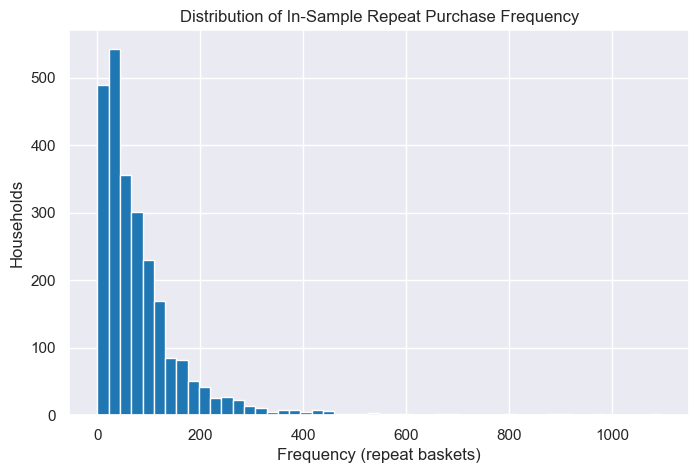

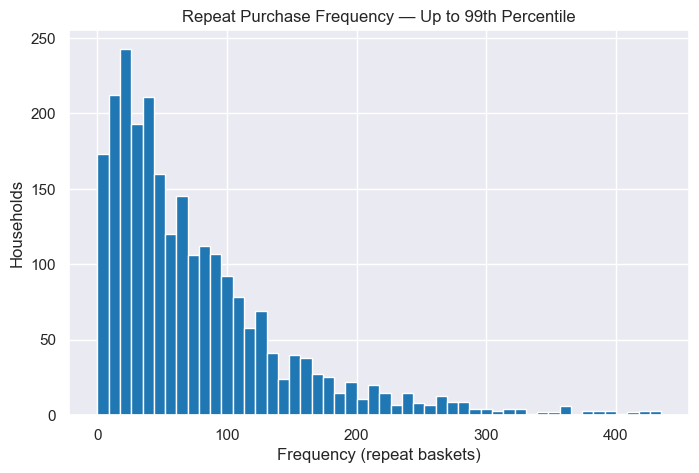

In [18]:
# Visualize frequency
plt.figure(figsize=(8, 5))

plt.hist(
    df["frequency"],
    bins=50
)

plt.xlabel("Frequency (repeat baskets)")
plt.ylabel("Households")
plt.title("Distribution of In-Sample Repeat Purchase Frequency")

plt.show()

# Because high-frequency observations may compress the chart, also inspect the 99th percentile range:
frequency_p99 = df["frequency"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[
        df["frequency"] <= frequency_p99,
        "frequency"
    ],
    bins=50
)

plt.xlabel("Frequency (repeat baskets)")
plt.ylabel("Households")
plt.title("Repeat Purchase Frequency — Up to 99th Percentile")

plt.show()

# Descriptive analysis the historical customer base
**What kinds of customers are in this dataset, and how much do they differ historically?**
We focus on: 
- Historical activity: How often have they shopped?
- Historical recency: How recently have they shopped?
- Historical contribution: How much retailer sales value have they generated?
- Basket economics: Is historical value associated with more baskets or larger basket value?

**Summary of findings:**
- The 2,498 in-sample households differ substantially in how much they spend (retailer sales contribution), how often they shop (frequency), and how recently they purchased (purchase recency).
- Historical sales and basket counts (frequency) are both strongly right-skewed: most households fall in the lower-to-middle range, while a smaller group generates very high sales and shops much more frequently.
- Historical sales are:
    - strongly associated with basket count (ρ = 0.849),
    - moderately associated with average basket value (ρ = 0.453), and
    - almost no associated with observation length (ρ = 0.050)

This suggests that higher historical sales are more closely associated with shopping more often than with simply spending more per basket, and are not mainly explained by longer observation periods.
Overall, historical behaviour varies meaningfully across households. 

In [19]:
df.columns

Index(['household_key', 'frequency', 'recency_days', 'observation_days',
       'prediction_horizon_days', 'actual_holdout_baskets',
       'actual_holdout_purchase_days', 'actual_holdout_active_weeks',
       'actual_holdout_sales', 'was_active_in_holdout', 'in_sample_baskets',
       'active_weeks', 'days_since_last_purchase', 'historical_sales',
       'average_basket_value', 'historical_quantity',
       'retail_discount_basket_rate', 'retail_discount_per_basket',
       'total_retail_discount', 'manufacturer_coupon_basket_rate',
       'total_manufacturer_coupon',
       'manufacturer_coupon_amount_per_redeeming_basket',
       'retail_coupon_match_basket_rate', 'retail_coupon_match_per_basket',
       'total_retail_coupon_match', 'estimated_pre_retail_discount_value'],
      dtype='object')

In [20]:
# ----------------------------------------------------------------
# Check historical summary
# ----------------------------------------------------------------
historical_summary_columns = [
    "in_sample_baskets",          
    "active_weeks",
    "days_since_last_purchase",
    "observation_days",
    "historical_sales",
    "average_basket_value"
]

historical_summary = (
    df[historical_summary_columns]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(historical_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
in_sample_baskets,"2,498.0000",82.5260,89.9211,1.0000,27.0000,57.0000,105.0000,173.3000,242.1500,436.0300,"1,096.0000"
active_weeks,"2,498.0000",36.7806,19.4822,1.0000,20.0000,37.0000,53.0000,63.0000,67.0000,73.0000,78.0000
days_since_last_purchase,"2,498.0000",27.9478,67.2447,0.0042,1.6627,6.3073,19.2675,65.6948,131.8065,424.3585,514.1750
observation_days,"2,498.0000",478.6517,35.9057,111.4632,449.1085,475.3576,508.5675,529.2645,536.9063,541.5044,543.5931
historical_sales,"2,498.0000","2,362.6383","2,503.9297",3.5500,663.4100,"1,571.5000","3,197.7150","5,483.0850","7,468.7900","11,298.2073","25,994.7200"
average_basket_value,"2,498.0000",31.2643,19.4276,2.6800,18.0725,26.7900,39.5850,55.9010,67.2745,102.7315,169.9700


## Visualize historical retailer sales 
historical_sales = Total retailer sales value ($) generated by the household during the in-sample period.
* It is interpreted as historical retailer sales contribution, rather than profitability or customer lifetime value because dataset does not contain the cost and margin information required to determine customer-level profit.

count    2,498.0000
mean     2,362.6383
std      2,503.9297
min          3.5500
25%        663.4100
50%      1,571.5000
75%      3,197.7150
90%      5,483.0850
95%      7,468.7900
99%     11,298.2073
max     25,994.7200
Name: historical_sales, dtype: float64


Households between median and mean: 390
Percentage of households: 15.61 %


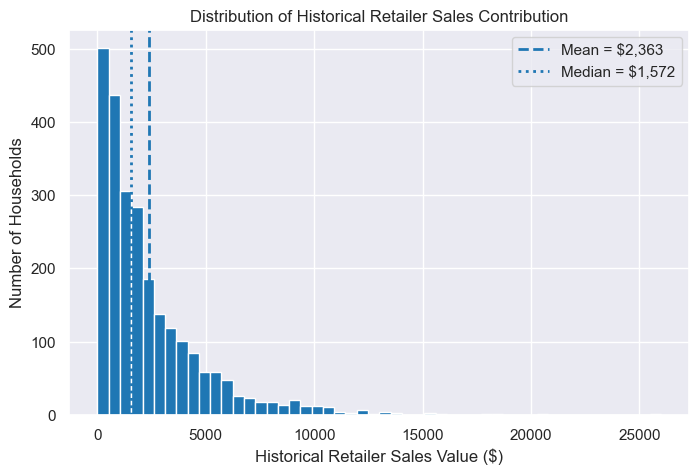

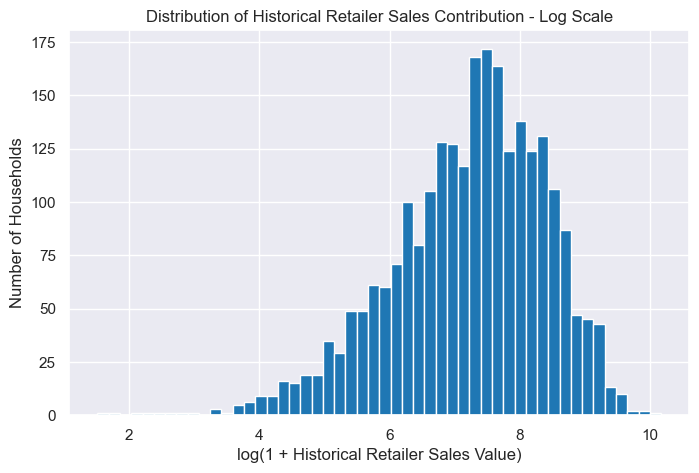

In [21]:
display(historical_summary.loc["historical_sales"])
# ----------------------------------------------------------------
# Check households with historical_sales between the median = 1,571.5000 and mean = 2,362.6383
# ----------------------------------------------------------------
between_median_mean = (
    (df["historical_sales"] > df["historical_sales"].median())
    & 
    (df["historical_sales"] < df["historical_sales"].mean())
)

print()
print("Households between median and mean:", between_median_mean.sum())
print(
    "Percentage of households:",
    round(between_median_mean.mean() * 100, 2),
    "%"
)

# ----------------------------------------------------------------
# Plot historical sales 
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

# Histogram
plt.hist(
    df["historical_sales"],
    bins=50
)

# Calculate mean and median
mean_sales = df["historical_sales"].mean()
median_sales = df["historical_sales"].median()

# Add mean and median lines
plt.axvline(
    mean_sales,
    linestyle="--",
    linewidth=2,
    label=f"Mean = ${mean_sales:,.0f}"
)

plt.axvline(
    median_sales,
    linestyle=":",
    linewidth=2,
    label=f"Median = ${median_sales:,.0f}"
)

# Labels and title
plt.xlabel("Historical Retailer Sales Value ($)")
plt.ylabel("Number of Households")
plt.title("Distribution of Historical Retailer Sales Contribution")

plt.legend()

plt.show()

# historical_sales: 
    # mean = 2,362.6383 >> median = 1,571.5000 
        # Right-skewed distribution. Most households generate sales around the lower-to-middle range, while a smaller group generates very high sales values that pull the average upward
    # sdt = 2,503.9297
        # Very large relative to the mean. Historical sales vary substantially across households rather than being concentrated around a similar level.
    # Simple cutoffs based on the mean may be misleading because the distribution is strongly skewed. 
    # Quantiles, percentiles, or log-transformed visualizations may be more appropriate for understanding and segmenting historical sales.

# ----------------------------------------------------------------
# Plot historical sales with log transformation
# (the very large values are compresses)
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df["historical_sales"]),
    bins=50
)

plt.xlabel("log(1 + Historical Retailer Sales Value)")
plt.ylabel("Number of Households")
plt.title("Distribution of Historical Retailer Sales Contribution - Log Scale")

plt.show()

# After the extreme right tail is compressed, there is still substantial variation among the majority of households.

# NOTE: 
# This supports historical sales as one dimension of customer profiling because there is meaningful variation between households.
# mean-based thresholds would not be ideal for segmentation. 
# Any household with historical sales between $1,571 and $2,363 is above the median household but would still fall into the “low” group if the mean were used as the cutoff.

## Visualize historical basket frequency
This analysis shows how much households differ in their number of shopping occasions during the in-sample period.

count   2,498.0000
mean       82.5260
std        89.9211
min         1.0000
25%        27.0000
50%        57.0000
75%       105.0000
90%       173.3000
95%       242.1500
99%       436.0300
max     1,096.0000
Name: in_sample_baskets, dtype: float64

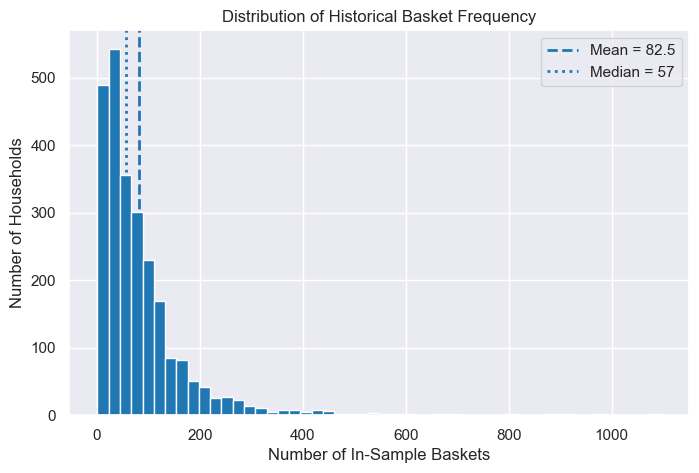

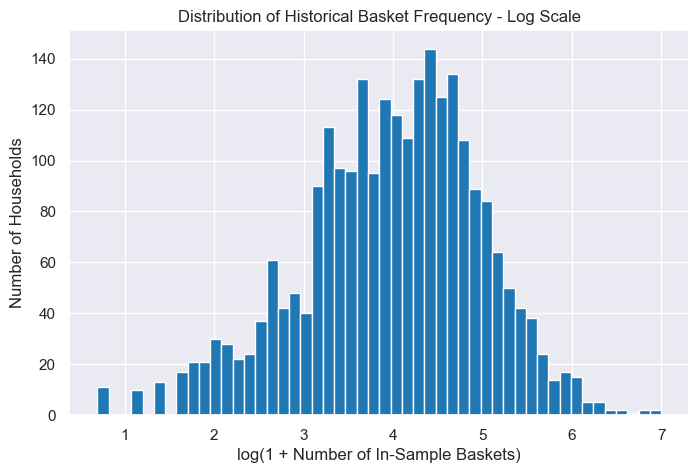

In [22]:
# ----------------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------------
display(historical_summary.loc["in_sample_baskets"])

# ----------------------------------------------------------------
# Plot the distribution 
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

# Histogram of total in-sample baskets per household
plt.hist(
    df["in_sample_baskets"],
    bins=50
)

# Calculate mean and median
mean_baskets = df["in_sample_baskets"].mean()
median_baskets = df["in_sample_baskets"].median()

# Add reference lines
plt.axvline(
    mean_baskets,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_baskets:.1f}"
)

plt.axvline(
    median_baskets,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_baskets:.0f}"
)

plt.xlabel("Number of In-Sample Baskets")
plt.ylabel("Number of Households")
plt.title("Distribution of Historical Basket Frequency")

plt.legend()
plt.show()


# INTERPRETATION: 
# Historical basket/shopping frequency varies substantially across households and is strongly right-skewed. 
# The median household made 57 baskets/ shopping trips during the in-sample period VS. mean = 82.5 baskets. 
# Most households made substantially fewer trips than the most frequent households, 
# with the top 10% recording more than about 173 baskets and the top 1% more than about 436 baskets.
# The maximum of 1,096 baskets is especially far from the rest of the distribution. 

# ----------------------------------------------------------------
# Plot the distribution with log-scale
# ---------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df["in_sample_baskets"]),
    bins=50
)

plt.xlabel("log(1 + Number of In-Sample Baskets)")
plt.ylabel("Number of Households")
plt.title("Distribution of Historical Basket Frequency - Log Scale")

plt.show()

## Visualize days since last purchase

This is useful because two historically valuable customers may have very different recent behavior.

This starts building the intuition behind our business problem:
- Customer A
    - High historical sales
    - Bought recently

- Customer B
    - High historical sales
    - Has not bought for much longer

Historical sales alone treats them similarly.

count   2,498.0000
mean       27.9478
std        67.2447
min         0.0042
25%         1.6627
50%         6.3073
75%        19.2675
90%        65.6948
95%       131.8065
99%       424.3585
max       514.1750
Name: days_since_last_purchase, dtype: float64

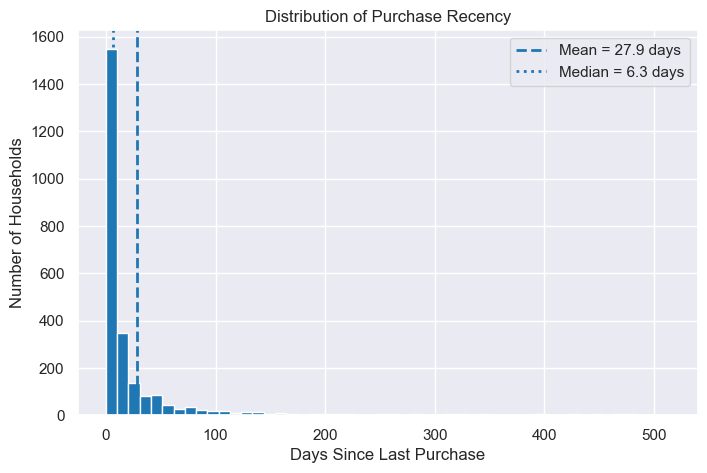

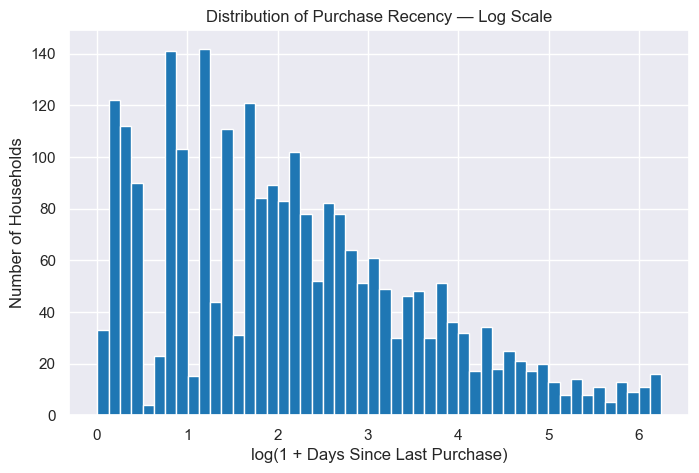

In [23]:
# ----------------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------------
display(historical_summary.loc["days_since_last_purchase"])

# ----------------------------------------------------------------
# Plot the distribution 
# ----------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["days_since_last_purchase"],
    bins=50
)

mean_recency = df["days_since_last_purchase"].mean()
median_recency = df["days_since_last_purchase"].median()

plt.axvline(
    mean_recency,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_recency:.1f} days"
)

plt.axvline(
    median_recency,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_recency:.1f} days"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Households")
plt.title("Distribution of Purchase Recency")

plt.legend()
plt.show()

# INTERPRETATION: 
# Purchase recency varies substantially across households and is highly right-skewed.
# The median is only 6.3 days, which means half of households made their most recent purchase within roughly the last week of the in-sample period. 
# By contrast, the mean is much higher at 27.9 days because a relatively small group of households had been inactive for much longer.

# 75% of households purchased within about 19 days
# 90% within about 66 days
# 95% within about 132 days
# 99% within about 424 days
# the maximum is about 514 days

# So most households were still relatively recent purchasers, while a small tail had gone many months without shopping.


# ----------------------------------------------------------------
# Plot the distribution with log-scale
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df["days_since_last_purchase"]),
    bins=50
)

plt.xlabel("log(1 + Days Since Last Purchase)")
plt.ylabel("Number of Households")
plt.title("Distribution of Purchase Recency — Log Scale")

plt.show()

## Understand what is associated with historical retailer sales
Check whether high historical sales are associated with a household that: 
- shops frequently
- spends more per basket (average_basket_value = average retailer sales value ($) generated each time the household shops)
- or both

Note: 
- historical_sales = total retailer sales generated by the household during the in-sample period.
- average_basket_value = average retailer sales generated each time the household shops.
- average basket value = historical sales / number of baskets



In [24]:
# ----------------------------------------------------------------
# Calculate the Spearman correlations 
# ----------------------------------------------------------------
# Use Spearman correlations because the variables are skewed and
# we are primarily interested in whether households rank similarly
# across the measures.
# Spearman correlation measures the strength and direction of a
# monotonic relationship based on the rank ordering of customers,
# rather than their raw units.


# sales vs. basket frequency (basket count)
sales_vs_baskets = spearmanr(df["historical_sales"], df["in_sample_baskets"])

# sales vs. average basket value ($)
sales_vs_basket_value = spearmanr(df["historical_sales"], df["average_basket_value"])

print("Historical sales vs basket count:", round(sales_vs_baskets.statistic, 3))

print("Historical sales vs average basket value:", round(sales_vs_basket_value.statistic, 3))

# INTERPRETATION:
# Historical sales contribution is strongly associated with shopping frequency (Spearman rho = 0.849) and moderately associated with basket value (Spearman rho = 0.453). 
    # Households that shop more frequently tend to generate substantially more historical sales.
    # Households with larger average basket values ($) also tend to generate more historical sales, but the relationship is weaker than for basket frequency.

Historical sales vs basket count: 0.849
Historical sales vs average basket value: 0.453


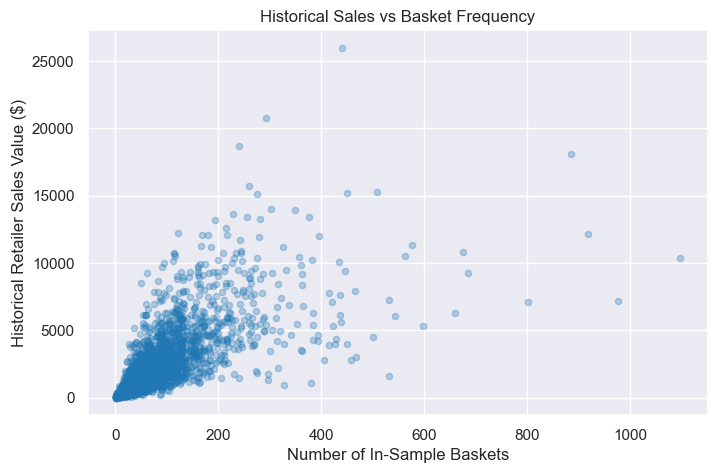

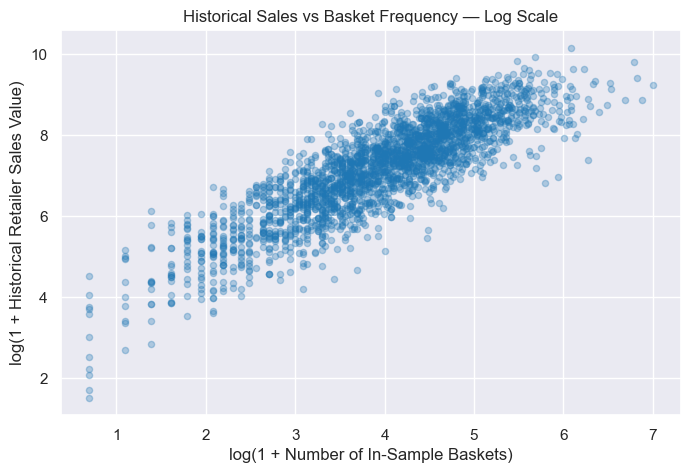

In [25]:
# ----------------------------------------------------------------
# Plot historical sales vs historical basket frequency (count)
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["in_sample_baskets"],
    df["historical_sales"],
    alpha=0.30,
    s=20
)

plt.xlabel("Number of In-Sample Baskets")
plt.ylabel("Historical Retailer Sales Value ($)")
plt.title("Historical Sales vs Basket Frequency")

plt.show()

# INTERPRETATION: 
# Households with more in-sample baskets generally generate higher historical retailer sales
# However, most households are concentrated in the lower-left corner, while a small number of very frequent or very high-sales households stretch both axes.

# ----------------------------------------------------------------
# Plot the same relationship on log-transformed scales
#
# Both variables are strongly right-skewed. Applying log1p() to
# both axes compresses extreme values and makes the relationship
# among the majority of households easier to see.
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    np.log1p(df["in_sample_baskets"]),
    np.log1p(df["historical_sales"]),
    alpha=0.30,
    s=20
)

plt.xlabel("log(1 + Number of In-Sample Baskets)")
plt.ylabel("log(1 + Historical Retailer Sales Value)")
plt.title("Historical Sales vs Basket Frequency — Log Scale")

plt.show()


# INTERPRETATION:  
# the relationship is clearer on the log-transformed scale, where the majority of households form a strong positive pattern.
# this supports the correlation result of 0.849

## Check observation history (observation days T)
Because customers' first purchases occur at different times

In [26]:
# ----------------------------------------------------------------
# Check the distribution of observation days
# ----------------------------------------------------------------
df["observation_days"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.99
    ]
)

# INTERPRETATION: 
# Median = 475 days
# 25%    = 449 days
# 75%    = 509 days
# 99%    = 542 days
# Max    = 544 days
# Most households were observed for roughly 450–540 days, 
# Small number of households have much shorter histories, about 111 days.

count   2,498.0000
mean      478.6517
std        35.9057
min       111.4632
25%       449.1085
50%       475.3576
75%       508.5675
90%       529.2645
99%       541.5044
max       543.5931
Name: observation_days, dtype: float64

In [27]:
# ----------------------------------------------------------------
# Spearman correlation
# Check whether differences in historical_sales are simply reflecting 
# how long each household was observed
# ----------------------------------------------------------------
sales_vs_observation = spearmanr(df["historical_sales"], df["observation_days"])

print("Historical sales vs observation days:", round(sales_vs_observation.statistic, 3))

# INTERPRETATION: Historical sales are not meaningfully associated with observation length (Spearman rho = 0.05).
# This suggests that differences in historical sales across households are not simply explained by 
# some households having substantially longer observation periods.

# NOTE: this does not mean observation time can be ignored in the BG/NBD model. 
# BG/NBD still needs each customer's exposure period T, because a customer making 20 purchases over 150 days 
# represents a different purchase rate from one making 20 purchases over 500 days.

Historical sales vs observation days: 0.05


## Describe how retailer discounts and coupons are used across the historical customer base
- `retail_discount_basket_rate`: On what share of the household’s baskets did the household RECEIVE a retailer loyalty-card discount?
- `retail_discount_per_basket`: How much retailer loyalty-card discount did the household RECEIVE per basket on average, across all baskets?
- `manufacturer_coupon_basket_rate`: On what share of the household’s baskets did the household REDEEM a manufacturer coupon?
- `manufacturer_coupon_amount_per_redeeming_basket`: When the household REDEEMED a manufacturer coupon, how large was the coupon amount ($) on average?
- `retail_coupon_match_basket_rate`: On what share of the household’s baskets did the household RECEIVE a retailer coupon match?
- `retail_coupon_match_per_basket`: How much retailer coupon-match value did the household RECEIVE per basket on average, across all baskets?

In [100]:
# ----------------------------------------------------------------
# Summarize the core promotion variables
# Across all households, how common are these discounts/coupons, 
# how large are they, and how much does discount use vary between households?
# ----------------------------------------------------------------
promotion_columns = [
    "retail_discount_basket_rate",         
    "retail_discount_per_basket",
    "manufacturer_coupon_basket_rate",                    
    "manufacturer_coupon_amount_per_redeeming_basket",   
    "retail_coupon_match_basket_rate",
    "retail_coupon_match_per_basket"
]

promotion_summary = (
    df[promotion_columns]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(promotion_summary)

# INTERPRETATION
# Retail loyalty-card discounts: widespread across households and baskets
# Manufacturer coupons: redeemed relatively infrequently, with substantial variation between households
# Retail coupon matches: least common and most concentrated near zero

# DETAILS:
# 1. Retailer loyalty-card discounts are very common across households.
# retail_discount_basket_rate
    # measures the share of a household's valid baskets that contained
    # a retailer loyalty-card discount.
    # - Median = 0.8649:
    #   the median household received a retailer loyalty-card discount
    #   on about 86.5% of its baskets.
    # - 25th percentile = 0.7830:
    #   even households at the 25th percentile received a retailer
    #   discount on about 78.3% of their baskets.
    # This indicates that retailer loyalty-card discounts are widespread
    # across the customer base rather than concentrated among only a
    # small group of households.
# retail_discount_per_basket
    # measures the average retailer loyalty-card discount amount across
    # ALL of a household's valid baskets, including baskets with no discount.
    # - Median = $4.86 per basket
    # - Mean   = $5.74 per basket
    # The mean is above the median, and the upper percentiles increase
    # substantially (e.g. 90th = $10.53, 95th = $13.15, 99th = $19.81).
    # This suggests a right-skewed distribution:
    # most households receive moderate retailer discounts per basket,
    # while a smaller group receives substantially larger amounts.

# 2. Manufacturer coupons are much less frequently redeemed.
# manufacturer_coupon_basket_rate
    # measures the share of a household's valid baskets in which a
    # manufacturer coupon was redeemed.
    # - Median = 0.0285:
    #   the median household redeemed a manufacturer coupon on only
    #   about 2.9% of its baskets.
    # - 25th percentile = 0:
    #   at least one quarter of households did not redeem a manufacturer
    #   coupon on any of their valid in-sample baskets.
    # The distribution is therefore much more concentrated near zero
    # and more right-skewed than retailer-discount receipt.
    # Most households redeem manufacturer coupons rarely or not at all,
    # while a smaller group redeems them relatively frequently.
# manufacturer_coupon_amount_per_redeeming_basket
    # measures the average manufacturer coupon amount ONLY among baskets
    # where the household actually redeemed a manufacturer coupon.
    # - Count = 1,720 rather than 2,498 because this metric is undefined
    #   for households that never redeemed a manufacturer coupon.
    # Therefore:
    #   2,498 - 1,720 = 778 households
    #   did not redeem a manufacturer coupon during the in-sample period.
    # This is about 31.1% of households.
    # Among households that did redeem coupons:
    # - Median amount per redeeming basket = $1.71
    # - Mean amount per redeeming basket   = $2.05
    # The higher upper percentiles again indicate a right-skewed
    # distribution: most redeeming households receive relatively modest
    # coupon amounts per redemption basket, while a smaller group receives
    # considerably larger amounts.


# 3. Retailer coupon matches are even less common.
# retail_coupon_match_basket_rate
    # measures the share of a household's valid baskets that contained
    # a retailer-funded coupon match.
    # - Median = 0:
    #   at least half of households received no retailer coupon match
    #   on any of their baskets.
    # - 75th percentile = 0.0286:
    #   even at the 75th percentile, retailer coupon matches occurred
    #   on only about 2.9% of baskets.
    # This indicates that retailer coupon matches are much less common
    # and much more concentrated among a subset of households than
    # retailer loyalty-card discounts.
# retail_coupon_match_per_basket
    # measures the average retailer coupon-match amount across ALL
    # of a household's valid baskets, including baskets with no match.
    # - Median = $0
    # - Mean   = about $0.025 per basket
    # The very low typical values reflect the fact that most baskets
    # contain no retailer coupon match at all.

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
retail_discount_basket_rate,"2,498.0000",0.8422,0.1149,0.0000,0.7830,0.8649,0.9225,0.9683,1.0000,1.0000,1.0000
retail_discount_per_basket,"2,498.0000",5.7419,4.2500,0.0000,2.9026,4.8573,7.3930,10.5333,13.1545,19.8122,49.7207
manufacturer_coupon_basket_rate,"2,498.0000",0.0571,0.0824,0.0000,0.0000,0.0285,0.0746,0.1515,0.2222,0.3977,0.7284
manufacturer_coupon_amount_per_redeeming_basket,"1,720.0000",2.0546,1.5416,0.1000,1.0141,1.7134,2.5000,3.5250,4.7514,8.5108,15.3600
retail_coupon_match_basket_rate,"2,498.0000",0.0267,0.0582,0.0000,0.0000,0.0000,0.0286,0.0789,0.1304,0.2740,0.6914
retail_coupon_match_per_basket,"2,498.0000",0.0247,0.0826,0.0000,0.0000,0.0000,0.0152,0.0608,0.1214,0.3357,1.8307


In [119]:
# ----------------------------------------------------------------
# Add customer-level promotion incidence

# Did each household experience/redeem each promotion type
# at least once during the in-sample period?
# ----------------------------------------------------------------

# Whether the household receive a retailer loyalty-card discount on at least one basket:
df["received_retail_discount"] = (
    df["retail_discount_basket_rate"] > 0
)

# Whether the household redeemed a manufacturer coupon on at least one basket: 
df["redeemed_manufacturer_coupon"] = (
    df["manufacturer_coupon_basket_rate"] > 0
)

# Whether the household received a retailer coupon match on at least one basket:
df["received_retail_coupon_match"] = (
    df["retail_coupon_match_basket_rate"] > 0
)

# The share of households in the customer base that had each promotion type 
# at least once during the in-sample period: 
promotion_customer_share = pd.Series({

    "Retail loyalty-card discount": (
        df["received_retail_discount"].mean()
    ),

    "Manufacturer coupon": (
        df["redeemed_manufacturer_coupon"].mean()
    ),

    "Retail coupon match": (
        df["received_retail_coupon_match"].mean()
    )
})

display(promotion_customer_share)


# Convert proportions to percentages
promotion_customer_share_pct = (
    promotion_customer_share * 100
)

print(
    "Percentage of Households Receiving/Redeeming "
    "Each Promotion Type at Least Once"
)

display(
    promotion_customer_share_pct.round(1)
)

Retail loyalty-card discount   0.9996
Manufacturer coupon            0.6886
Retail coupon match            0.4576
dtype: float64

Percentage of Households Receiving/Redeeming Each Promotion Type at Least Once


Retail loyalty-card discount   100.0000
Manufacturer coupon             68.9000
Retail coupon match             45.8000
dtype: float64

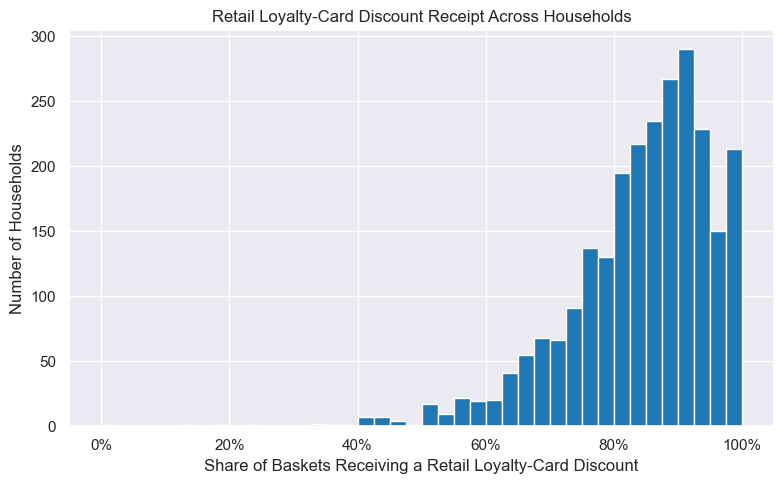

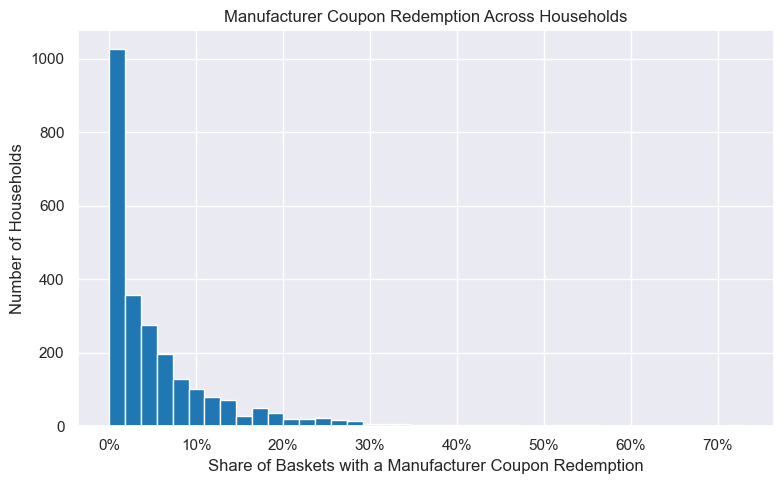

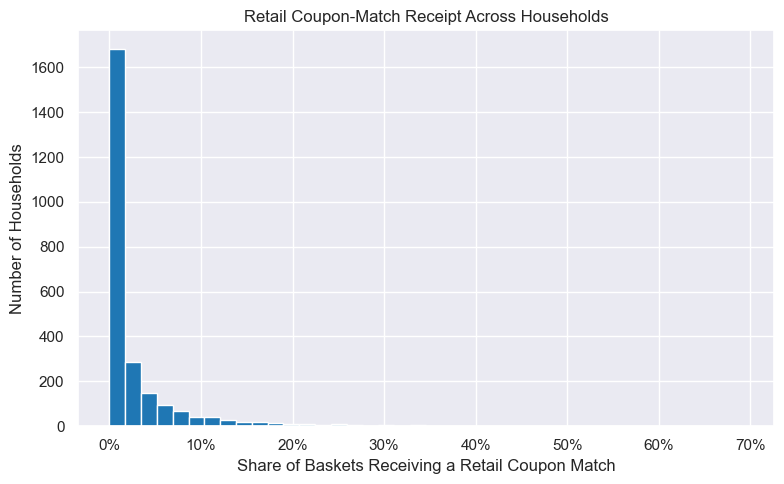

In [113]:
# Plot the distribution of promotion frequency across households
# ---------------------------------------------------------------
# 1. Retail loyalty-card discount
# ---------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["retail_discount_basket_rate"],
    bins=40
)

plt.xlabel("Share of Baskets Receiving a Retail Loyalty-Card Discount")
plt.ylabel("Number of Households")
plt.title("Retail Loyalty-Card Discount Receipt Across Households")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# 2. Manufacturer coupon
# ---------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["manufacturer_coupon_basket_rate"],
    bins=40
)

plt.xlabel("Share of Baskets with a Manufacturer Coupon Redemption")
plt.ylabel("Number of Households")
plt.title("Manufacturer Coupon Redemption Across Households")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# 3. Retail coupon match
# ---------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    df["retail_coupon_match_basket_rate"],
    bins=40
)

plt.xlabel("Share of Baskets Receiving a Retail Coupon Match")
plt.ylabel("Number of Households")
plt.title("Retail Coupon-Match Receipt Across Households")

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()

# INTERPRETATION:
#
# Each histogram shows how frequently households experienced
# a particular promotion across their baskets.
#
# Retail loyalty-card discounts:
# - Distribution is concentrated at high basket rates.
# - Most households received retailer discounts on a large
#   share of their baskets.
#
# Manufacturer coupons:
# - Distribution is concentrated near zero.
# - Most households redeemed manufacturer coupons on only a
#   small share of their baskets, while a smaller group redeemed
#   them more frequently.
#
# Retail coupon matches:
# - Distribution is even more concentrated near zero.
# - Many households never received a coupon match, and frequent
#   coupon-match receipt is limited to a relatively small subset
#   of households.

In [122]:
# Normalized monetary promotion measures
#
# Raw promotion totals are partly driven by how much a household
# shops. These measures normalize promotion amounts so households
# with different purchasing levels can be compared more meaningfully.
# (i.e. How large is the promotion relative to the household’s purchasing value?)

# ---------------------------------------------------------
# 1. Retail loyalty-card discount as a share of estimated
#    pre-retailer-discount value
#
# Formula:
# total retail loyalty-card discount / estimated pre-retailer-discount value
#
# Telling:
# How large were the household's retail loyalty-card discounts
# relative to its estimated purchase value before retailer-funded
# discounts?
# ---------------------------------------------------------

df["retail_discount_share_of_pre_discount_value"] = np.where(
    df["estimated_pre_retail_discount_value"] > 0,

    df["total_retail_discount"]
    / df["estimated_pre_retail_discount_value"],

    np.nan
)


# ---------------------------------------------------------
# 2. Total retailer-funded discounts as a share of estimated
#    pre-retailer-discount value
#
# Retailer-funded discounts include:
# - retail loyalty-card discounts
# - retail coupon matches
#
# Formula:
# (total retail discount + total retail coupon match) / estimated pre-retailer-discount value
#
# Telling:
# How large were all retailer-funded discounts relative to the
# household's estimated purchase value before those discounts?
# ---------------------------------------------------------

df["retailer_funded_discount_share_of_pre_discount_value"] = np.where(
    df["estimated_pre_retail_discount_value"] > 0,

    (
        df["total_retail_discount"]
        + df["total_retail_coupon_match"]
    )
    / df["estimated_pre_retail_discount_value"],

    np.nan
)


# ---------------------------------------------------------
# 3. Manufacturer coupon value per basket
#
# Formula:
# total manufacturer coupon amount/ total valid in-sample baskets
#
# Telling:
# Across all baskets, how much manufacturer coupon value did the
# household redeem per basket on average?
# ---------------------------------------------------------

df["manufacturer_coupon_value_per_basket"] = (
    df["total_manufacturer_coupon"]
    / df["in_sample_baskets"]
)

In [116]:
# =========================================================
# Summarize normalized monetary promotion measures
# =========================================================

normalized_promotion_columns = [
    "retail_discount_share_of_pre_discount_value",
    "retailer_funded_discount_share_of_pre_discount_value",
    "manufacturer_coupon_value_per_basket"
]

normalized_promotion_summary = (
    df[normalized_promotion_columns]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

print(
    "Normalized Monetary Promotion Measures Across Households"
)

display(normalized_promotion_summary)

# INTERPRETATION: 
# retail_discount_share_of_pre_discount_value
    # The median household received retailer loyalty-card discounts
    # equivalent to about 14.9% of its estimated pre-retailer-discount
    # purchase value.
    # The middle 50% of households range from about 11.7% to 18.4%.
    # Higher upper percentiles indicate that a smaller group of
    # households received substantially larger discounts relative
    # to their estimated purchase value.

# retailer_funded_discount_share_of_pre_discount_value
    # The median household received total retailer-funded discounts
    # equivalent to about 14.9% of its estimated pre-retailer-discount
    # purchase value.
    # This distribution is almost identical to the retail loyalty-card
    # discount share alone.
    # This is consistent with the earlier finding that retailer coupon
    # matches are uncommon and generally small. Therefore, retail
    # loyalty-card discounts account for most observed retailer-funded
    # promotional value.

# manufacturer_coupon_value_per_basket
    # The median household redeemed about $0.04 of manufacturer
    # coupon value per basket when averaged across ALL baskets,
    # including baskets with no coupon redemption.
    # The mean ($0.14) is substantially above the median, and the
    # upper percentiles increase sharply, indicating a strongly
    # right-skewed distribution.
    # Most households therefore realize little manufacturer-coupon
    # value per shopping occasion overall, while a smaller subset
    # redeems considerably more.
    # This should NOT be interpreted as the typical value of an
    # individual coupon. Coupon value conditional on redemption is
    # captured separately by
    # manufacturer_coupon_amount_per_redeeming_basket.

Normalized Monetary Promotion Measures Across Households


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
retail_discount_share_of_pre_discount_value,"2,498.0000",0.1544,0.0551,0.0000,0.1170,0.1491,0.1843,0.2230,0.2519,0.3220,0.4233
retailer_funded_discount_share_of_pre_discount_value,"2,498.0000",0.1550,0.0554,0.0000,0.1176,0.1493,0.1851,0.2238,0.2542,0.3226,0.4233
manufacturer_coupon_value_per_basket,"2,498.0000",0.1395,0.3053,0.0000,0.0000,0.0398,0.1423,0.3690,0.6056,1.3187,4.5878


In [124]:
# =========================================================
# Validate normalized monetary promotion measures
# =========================================================

print(
    "Households with non-positive estimated pre-retailer-discount value:",
    (df["estimated_pre_retail_discount_value"] <= 0).sum()
)

print(
    "Missing retail discount share:",
    df["retail_discount_share_of_pre_discount_value"].isna().sum()
)

print(
    "Missing retailer-funded discount share:",
    df[
        "retailer_funded_discount_share_of_pre_discount_value"
    ].isna().sum()
)

print(
    "Retail discount share outside 0–1:",
    (
        (df["retail_discount_share_of_pre_discount_value"] < 0)
        |
        (df["retail_discount_share_of_pre_discount_value"] > 1)
    ).sum()
)

print(
    "Retailer-funded discount share outside 0–1:",
    (
        (
            df[
                "retailer_funded_discount_share_of_pre_discount_value"
            ] < 0
        )
        |
        (
            df[
                "retailer_funded_discount_share_of_pre_discount_value"
            ] > 1
        )
    ).sum()
)

Households with non-positive estimated pre-retailer-discount value: 0
Missing retail discount share: 0
Missing retailer-funded discount share: 0
Retail discount share outside 0–1: 0
Retailer-funded discount share outside 0–1: 0


In [125]:
# =========================================================
# OVERALL INTERPRETATION
# =========================================================
#
# Retail loyalty-card discounts:
# - Widespread across households and baskets.
# - The median household receives them on about 86.5% of baskets.
# - Retail discounts represent about 14.9% of estimated
#   pre-retailer-discount value for the median household.
#
# Manufacturer coupons:
# - Redeemed much less frequently.
# - The median household redeems them on about 2.9% of baskets.
# - Around 31% of households never redeemed one during the
#   in-sample period.
# - Coupon value per basket is strongly right-skewed, indicating
#   substantially heavier redemption among a smaller subset.
#
# Retail coupon matches:
# - Least common of the three promotion mechanisms.
# - At least half of households never received one.
# - Their monetary contribution is small relative to ordinary
#   retailer loyalty-card discounts.
#
# Overall:
# Promotion behaviour is highly heterogeneous across households.
# Retail loyalty-card discounts are broadly distributed, whereas
# manufacturer coupon redemption and retailer coupon matches are
# much more concentrated among subsets of households.
#
# These customer-base patterns provide the descriptive benchmark
# for the later analysis of whether promotion behaviour differs
# across historical-sales × expected-future-activity profiles.

# Examine whether historical retailer sales alone adequately capture future purchase activity
If we ranked the 2498 households only by historical retailer sales, would that give us essentially the same information about future activity?

## Does historical sales predict future baskets at all?
Use the actual holdout values to evaluate

In [28]:
# ----------------------------------------------------------------
# Spearman correlation 
# ----------------------------------------------------------------
historical_sales_future_corr = spearmanr(
    df["historical_sales"],           # total sales value per household
    df["actual_holdout_baskets"]      # baskets count per household
)

print(
    "Spearman correlation between historical sales "
    "and actual holdout baskets:",
    round(
        historical_sales_future_corr.statistic,
        3
    )
)

# INTERPRETATION: 
# Historical sales and future basket activity have a fairly strong positive rank association (Spearman rho = 0.683).
# So households that generated more sales historically generally also made more purchases during the holdout period.
# Historical sales does contain useful information about future activity.

Spearman correlation between historical sales and actual holdout baskets: 0.683


We rank customers because the business decision is often about relative priority/position:
*"Which customers look more important than others on this dimension?"*
    - For historical contribution: highest historical sales -> ... -> lowest historical sales
    - For predicted future activity: highest expected future baskets -> ... -> lowest expected future baskets

historical_sales_quintile
Q1 - Lowest     500
Q2              499
Q3              500
Q4              499
Q5 - Highest    500
Name: count, dtype: int64

,historical_sales_quintile,customers,historical_sales_median,actual_holdout_baskets_mean,actual_holdout_baskets_median,actual_holdout_baskets_q25,actual_holdout_baskets_q75
0,Q1 - Lowest,500,263.0000,8.2580,5.0000,2.0000,11.0000
1,Q2,499,818.6800,16.2505,12.0000,6.5000,20.0000
2,Q3,500,"1,571.5000",24.4500,19.0000,11.0000,31.2500
3,Q4,499,"2,741.0100",33.3467,28.0000,17.0000,43.0000
4,Q5 - Highest,500,"5,488.0550",57.2600,47.0000,31.0000,71.5000


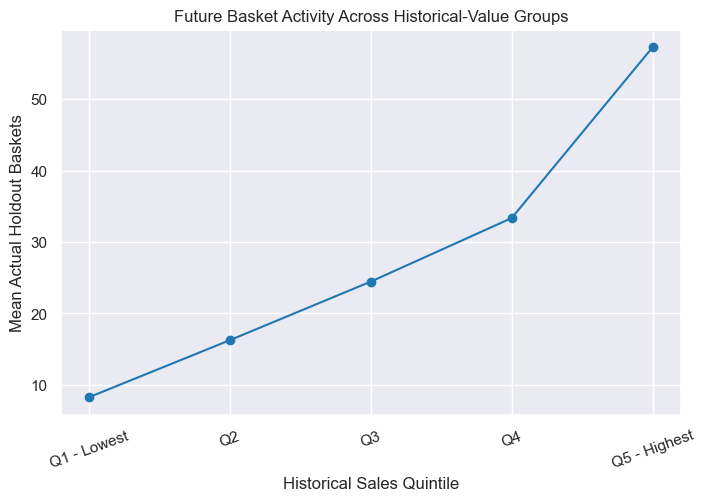

In [29]:
# ----------------------------------------------------------------
# Create historical-value quintiles
# Split households into 5 groups based only on historical sales.
# ----------------------------------------------------------------

df["historical_sales_quintile"] = pd.qcut(
    df["historical_sales"].rank(method="first"),
    q=5,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ]
)


display(df["historical_sales_quintile"].value_counts(sort=False))

# ----------------------------------------------------------------
# Compare future purchase activity across historical-value groups
# Do historically higher-value customers generally purchase more in the future?
# ----------------------------------------------------------------
historical_sales_holdout_baskets_summary = (
    df
    .groupby(
        "historical_sales_quintile",
        observed=True
    )
    .agg(
        customers=(
            "household_key",
            "size"
        ),

        historical_sales_median=(
            "historical_sales",
            "median"
        ),

        actual_holdout_baskets_mean=(
            "actual_holdout_baskets",       # holdout baskets count
            "mean"
        ),

        actual_holdout_baskets_median=(
            "actual_holdout_baskets",
            "median"
        ),

        actual_holdout_baskets_q25=(
            "actual_holdout_baskets",
            lambda x: x.quantile(0.25)
        ),

        actual_holdout_baskets_q75=(
            "actual_holdout_baskets",
            lambda x: x.quantile(0.75)
        )
    )
    .reset_index()
)

display(historical_sales_holdout_baskets_summary)


# ----------------------------------------------------------------
# Plot historical sales value vs future purchase activity
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    historical_sales_holdout_baskets_summary[
        "historical_sales_quintile"
    ].astype(str),

    historical_sales_holdout_baskets_summary[
        "actual_holdout_baskets_mean"
    ],

    marker="o"
)

plt.xlabel("Historical Sales Quintile")
plt.ylabel("Mean Actual Holdout Baskets")
plt.title(
    "Future Basket Activity Across Historical-Value Groups"
)

plt.xticks(rotation=20)

plt.show()


# INTERPRETATION: 
# There is an increasing pattern: historically higher-value customers generally purchase more in the future
# Supporting the Spearman correlation result that Historical sales clearly has predictive information.

## How much variation exists within each value group (5 groups)

,min,p10,q25,median,q75,p90,max
historical_sales_quintile,,,,,,,
Q1 - Lowest,0,0.0000,2.0000,5.0000,11.0000,19.0000,97
Q2,0,3.0000,6.5000,12.0000,20.0000,32.2000,145
Q3,0,6.0000,11.0000,19.0000,31.2500,50.0000,304
Q4,0,10.0000,17.0000,28.0000,43.0000,62.2000,211
Q5 - Highest,0,19.0000,31.0000,47.0000,71.5000,105.1000,335


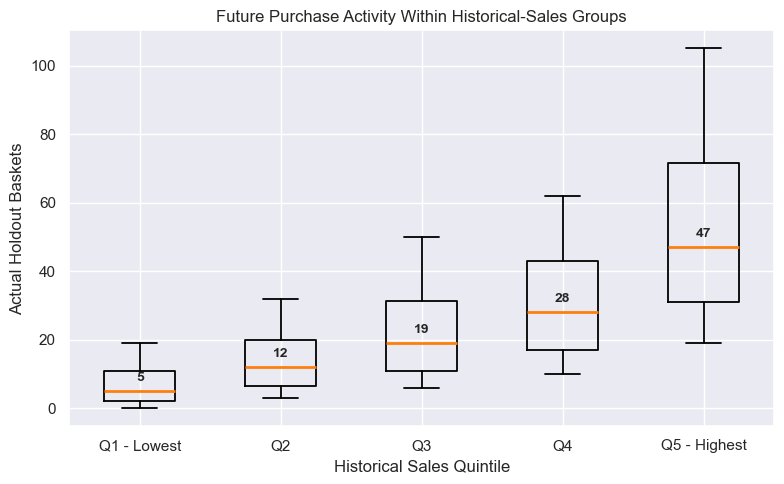

In [30]:
# ----------------------------------------------------------------
# Check whether similar historical-value customers can behave very differently
# ----------------------------------------------------------------
future_dispersion_by_value = (
    df
    .groupby(
        "historical_sales_quintile",
        observed=True
    )["actual_holdout_baskets"]             # holdout baskets count
    .agg(
        [
            "min",
            lambda x: x.quantile(0.10),
            lambda x: x.quantile(0.25),
            "median",
            lambda x: x.quantile(0.75),
            lambda x: x.quantile(0.90),
            "max"
        ]
    )
)

future_dispersion_by_value.columns = [
    "min",
    "p10",
    "q25",
    "median",
    "q75",
    "p90",
    "max"
]

display(future_dispersion_by_value) 

# ----------------------------------------------------------------
# Boxplot to check the variation of future purchase activity within 
# historical-sales groups
#
# Box        = 25th to 75th percentile
# Orange line = median
# Whiskers   = 10th to 90th percentile
# ----------------------------------------------------------------

categories = df["historical_sales_quintile"].cat.categories

groups = [
    df.loc[
        df["historical_sales_quintile"] == group,
        "actual_holdout_baskets"
    ].values
    for group in categories
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    groups,
    tick_labels=[str(x) for x in categories],
    whis=(10, 90),
    showfliers=False,
    medianprops={"linewidth": 2},
    boxprops={"linewidth": 1.3},
    whiskerprops={"linewidth": 1.3},
    capprops={"linewidth": 1.3}
)

# ----------------------------------------------------------------
# Add median value labels
# ----------------------------------------------------------------
medians = [np.median(group) for group in groups]

for i, median in enumerate(medians, start=1):
    plt.text(
        i,
        median + 2,             # position slightly above median line
        f"{median:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel("Historical Sales Quintile")
plt.ylabel("Actual Holdout Baskets")
plt.title("Future Purchase Activity Within Historical-Sales Groups")

plt.tight_layout()
plt.show()

# INTERPRETATION: 
# Future activity clearly increases as historical sales increase, but there is still a lot of variation within each sales group. 
# For example, households in Q3 have a median of 19 future baskets, but the middle 50% range from 11 to 31 baskets. 
# In Q4, the median is 28, but the middle 50% range from 17 to 43 baskets. Because these ranges overlap substantially, 
# some Q3 households go on to shop more often than many Q4 households. 

# Therefore, historical sales is useful as a broad indicator, but not enough to precisely distinguish individual customers' future purchase activity.

# Fit and evaluate BG/NBD against a historical purchase-rate benchmark

Historical sales is positively associated with future purchase activity, but the households with similar historical sales can still show quite different basket counts in the holdout period. 
This suggests that historical sales alone may not fully reflect differences in customers’ purchase patterns. 

The next step is therefore to examine whether a model based on purchase frequency, recency, and observation time can provide a useful forward-looking estimate of future basket activity. 
BG/NBD is used for this purpose and is evaluated on the holdout period against a simple historical purchase-rate benchmark before its predictions are used for customer profiling.

Historical retailer sales is already associated with future basket
activity, so simply showing that BG/NBD predicts future activity is
not enough to justify a two-dimensional customer framework.

The key question is:

> Among households with broadly similar historical sales contribution,
> does BG/NBD distinguish customers who subsequently exhibit different
> levels of purchase activity?

If it does, historical value and predicted future activity provide
complementary information for customer prioritization.


## Define the historical-rate benchmark
We use a simple prediction rule that assuming each household's future repeat-purchse rate will be the same as their historical repeat-purchase rate:
- For household i:
  - predicted number of baskets during holdout = (x_i / T_i) * 167
    - frequency x_i = *number of repeat purchases* observed during the in-sample period. (Use repeat purchases after the first so that the benchmark use the same repeat-purchase concept as BG/NBD). 
    - observation days T_i = *number of days* the customer has been observed since their first purchase
    - 167 = length of the holdout period
- Example:
  - Suppose a household has x=20, T=200. Its historical repeat-purchase rate = 20/ 100 = 0.10 repeat purchases per day.
  - If we assume that rate continues for another 167 days: 0.10 * 167 = 16.7, meaning the household's baseline predicted holdout baskets = 16.7 baskets

  

In [31]:
# ----------------------------------------------------------------
# Calculate the historical rate baseline for each household
# ----------------------------------------------------------------
df["historical_repeat_rate_per_day"] = (
    df["frequency"]
    / df["observation_days"]
)
# ----------------------------------------------------------------
# Extend the historical rate over the holdout period of 167 days
# ----------------------------------------------------------------
df["predicted_holdout_baskets_baseline"] = (
    df["historical_repeat_rate_per_day"]
    * prediction_horizon_days
)
# ----------------------------------------------------------------
# Check the results
# ----------------------------------------------------------------
df[
    [
        "household_key",
        "frequency",
        "observation_days",
        "historical_repeat_rate_per_day",
        "predicted_holdout_baskets_baseline",
        "actual_holdout_baskets"
    ]
].head(10)




,household_key,frequency,observation_days,historical_repeat_rate_per_day,predicted_holdout_baskets_baseline,actual_holdout_baskets
0,1,61,493.3778,0.1236,20.6475,23
1,2,36,441.2056,0.0816,13.6263,8
2,3,41,431.3410,0.0951,15.8738,5
3,4,25,440.3806,0.0568,9.4804,4
4,5,32,459.3472,0.0697,11.6339,7
5,6,187,426.0375,0.4389,73.3011,61
6,7,33,521.3924,0.0633,10.5698,25
7,8,79,479.0910,0.1649,27.5376,33
8,9,11,440.5083,0.0250,4.1702,8
9,10,6,430.3528,0.0139,2.3283,2


In [32]:
# For the 11 household with 11 one-time purchases,
# The historical-rate baseline would be (0/T) * 167 = 0
# So their predicted_holdout_baskets_baseline = 0
df.loc[
    df["frequency"] == 0,
    [
        "frequency",
        "predicted_holdout_baskets_baseline"
    ]
]

,frequency,predicted_holdout_baskets_baseline
378,0,0.0000
493,0,0.0000
1104,0,0.0000
1432,0,0.0000
1812,0,0.0000
1829,0,0.0000
1875,0,0.0000
1896,0,0.0000
2099,0,0.0000
2175,0,0.0000


## Fit BG/NBD model
The model was fitted on 2,498 households using only their in-sample purchase histories. For each household it uses three pieces of information: 
- repeat purchase frequency (x), 
- recency (t_x), 
- observation time (T). 

It then predicts the expected number of baskets over the following 167-day holdout period. Importantly, the actual holdout baskets were not used to fit the model

In [33]:
# ----------------------------------------------------------------
# Initialize the standard unpenalized model
# ----------------------------------------------------------------
bgf = BetaGeoFitter(
    penalizer_coef=0.000
)

# ----------------------------------------------------------------
# Fit the model
# ----------------------------------------------------------------
bgf.fit(
    frequency=df["frequency"],
    recency=df["recency_days"],
    T=df["observation_days"]
)

# ----------------------------------------------------------------
# Print the estimated parameters
# ----------------------------------------------------------------
bgf.params_

# NOTE:
# r and alpha parameters describe the model-implied variation in households' underlying purchase rates. (what are the various purchase rates of customers?)
    # Together, they imply a population-average latent purchase rate of about 0.174 purchases per day, 
    # equivalent to roughly one purchase every 5.7 days while active. 
    # This does not mean every household shops every 5.7 days. 
    # BG/NBD explicitly allows households to have different purchase rates.
# a and b parameters describe differences in the model's latent dropout probability (what are the various drop-out probabilities of customers?) 
# Recall that BG/NBD as assuming every household has two hidden characteristics:
# Household i
# │
# ├── λᵢ = underlying purchase rate
# │        "How frequently does this household tend to shop
# │         while it is active?"
# │
# └── pᵢ = underlying dropout probability
#          "How likely is this household to become inactive
#           after a purchase?"

r         1.2017
alpha     6.9031
a         0.1451
b       175.8366
dtype: float64

## Understand the model parameters 

In [36]:
# ----------------------------------------------------------------
# Inspect the estimated parameters
# ----------------------------------------------------------------
bgf.summary


# r, alpha are estimated quite precisely (what are the various purchase rates of customers?)
# a, b have very large standard errors/ uncertainty (what are the various drop-out probabilities of customers?) 
# The dropout component is much less precisely identified than the purchase-rate component.

,coef,se(coef),lower 95% bound,upper 95% bound
r,1.2017,0.0317,1.1395,1.2638
alpha,6.9031,0.2226,6.4668,7.3393
a,0.1451,0.0807,-0.0131,0.3032
b,175.8366,123.7171,-66.6489,418.3222


In [37]:
# ----------------------------------------------------------------
# Model diagnostic: Compute probability alive 
# ----------------------------------------------------------------
df["probability_alive"] = (
    bgf.conditional_probability_alive(
        df["frequency"],
        df["recency_days"],
        df["observation_days"]
    )
)
display(df.head())
# ----------------------------------------------------------------
# Probability-alive distribution
# ----------------------------------------------------------------
# Almost everyone is predicted to still be "alive"
    # The median is 99.87% probability alive. 
        # This means for the typical customer, BG/NBD model says "this customer is almost certainly still active."
    # The mean 95.07% is lower than the median because there must be a relatively small group of customers with 
    # much lower probability_alive, pulling the average down.
display(df["probability_alive"].describe())

assert df["probability_alive"].between(0, 1).all()

# Our BG/NBD model appears to be getting much of its useful differentiation from: different purchase rates
# rather than from strongly distinguishing lots of "active" versus "inactive" customers.

,household_key,frequency,recency_days,observation_days,prediction_horizon_days,actual_holdout_baskets,actual_holdout_purchase_days,actual_holdout_active_weeks,actual_holdout_sales,was_active_in_holdout,in_sample_baskets,active_weeks,days_since_last_purchase,historical_sales,average_basket_value,historical_quantity,retail_discount_basket_rate,retail_discount_per_basket,total_retail_discount,manufacturer_coupon_basket_rate,total_manufacturer_coupon,manufacturer_coupon_amount_per_redeeming_basket,retail_coupon_match_basket_rate,retail_coupon_match_per_basket,total_retail_coupon_match,estimated_pre_retail_discount_value,historical_sales_quintile,historical_repeat_rate_per_day,predicted_holdout_baskets_baseline,probability_alive
0,1,61,489.1632,493.3778,167,23,22,18,"1,187.5000",True,62,50,4.2146,"3,142.6600",50.6900,1454,0.8065,8.6276,534.9100,0.3548,65.6800,2.9855,0.3065,0.3169,19.6500,"3,697.2200",Q4,0.1236,20.6475,0.9990
1,2,36,439.0201,441.2056,167,8,8,7,461.5800,True,37,28,2.1854,"1,492.7600",40.3400,621,0.9459,7.1757,265.5000,0.1081,7.0000,1.7500,0.0000,0.0000,0.0000,"1,758.2600",Q3,0.0816,13.6263,0.9992
2,3,41,418.8979,431.3410,167,5,5,5,134.4100,True,42,32,12.4431,"2,518.8000",59.9700,8444,0.9762,15.4083,647.1500,0.1190,61.1900,12.2380,0.1190,0.4714,19.8000,"3,185.7500",Q4,0.0951,15.8738,0.9977
3,4,25,392.0188,440.3806,167,4,4,4,141.9300,True,26,22,48.3618,"1,058.1800",40.7000,330,0.9231,4.0065,104.1700,0.0385,2.5000,2.5000,0.0000,0.0000,0.0000,"1,162.3500",Q2,0.0568,9.4804,0.9857
4,5,32,457.0160,459.3472,167,7,6,5,108.9400,True,33,22,2.3312,670.1200,20.3100,227,0.8182,3.4045,112.3500,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,782.4700,Q2,0.0697,11.6339,0.9992


count   2,498.0000
mean        0.9507
std         0.1878
min         0.0000
25%         0.9966
50%         0.9987
75%         0.9992
max         1.0000
Name: probability_alive, dtype: float64

## Visualize model-implied distribution of household purchase rates λ ~ Gamma(r, alpha) and household dropout probabilities p ~ Beta(a, b)

r     = 1.2017
alpha = 6.9031
a     = 0.1451
b     = 175.8366
Population mean purchase rate: 0.174 purchases/day
Equivalent to about one purchase every 5.7 days


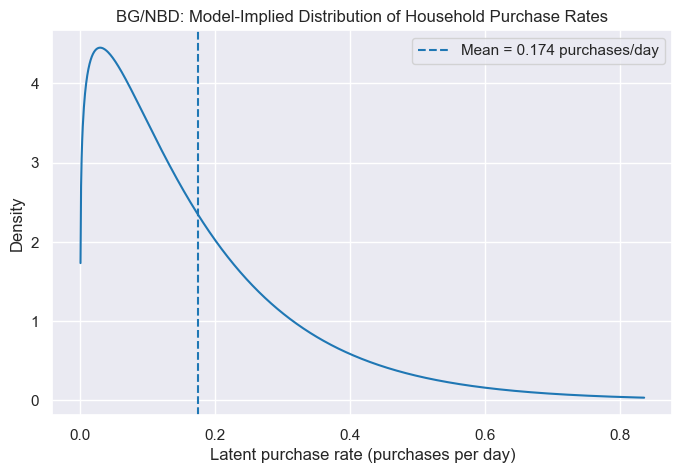

In [38]:
# ----------------------------------------------------------------
# Visualize the Gamma distribution of purchase rates
# BG/NBD assumes each household has its own latent purchase rate: λ_i ∼ Gamma(r,α)
# ----------------------------------------------------------------
r = bgf.params_["r"]
alpha = bgf.params_["alpha"]
a = bgf.params_["a"]
b = bgf.params_["b"]

print(f"r     = {r:.4f}")
print(f"alpha = {alpha:.4f}")
print(f"a     = {a:.4f}")
print(f"b     = {b:.4f}")

scale = 1 / alpha

# ----------------------------------------------------------------
# Model-implied distribution of household purchase rates
# lambda ~ Gamma(r, alpha)
#
# Important:
# BG/NBD uses alpha as a RATE parameter.
# scipy.stats.gamma uses SCALE = 1 / alpha.
# ----------------------------------------------------------------

mean_purchase_rate = r / alpha
mean_days_between_purchases = 1 / mean_purchase_rate

print(
    f"Population mean purchase rate: "
    f"{mean_purchase_rate:.3f} purchases/day"
)

print(
    f"Equivalent to about one purchase every "
    f"{mean_days_between_purchases:.1f} days"
)

# Use a high percentile so the graph covers almost all
# of the model-implied purchase-rate distribution.
lambda_max = gamma_dist.ppf(
    0.995,
    a=r,
    scale=1 / alpha
)

lambda_values = np.linspace(
    0.0001,
    lambda_max,
    1000
)

lambda_density = gamma_dist.pdf(
    lambda_values,
    a=r,
    scale=1 / alpha
)

plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    lambda_density
)

plt.axvline(
    mean_purchase_rate,
    linestyle="--",
    label=f"Mean = {mean_purchase_rate:.3f} purchases/day"
)

plt.xlabel("Latent purchase rate (purchases per day)")
plt.ylabel("Density")
plt.title("BG/NBD: Model-Implied Distribution of Household Purchase Rates")
plt.legend()

plt.show()

# NOTE: the Gamma graph does not mean that everyone shops every 5.7 days. 
# The main point of the Gamma distribution is that BG/NBD assumes households differ in their underlying purchasing rates.

Population mean dropout probability: 0.000824
As a percentage: 0.082%


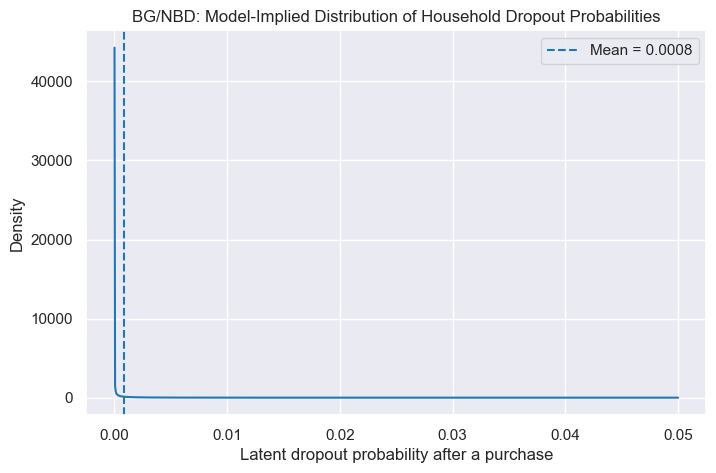

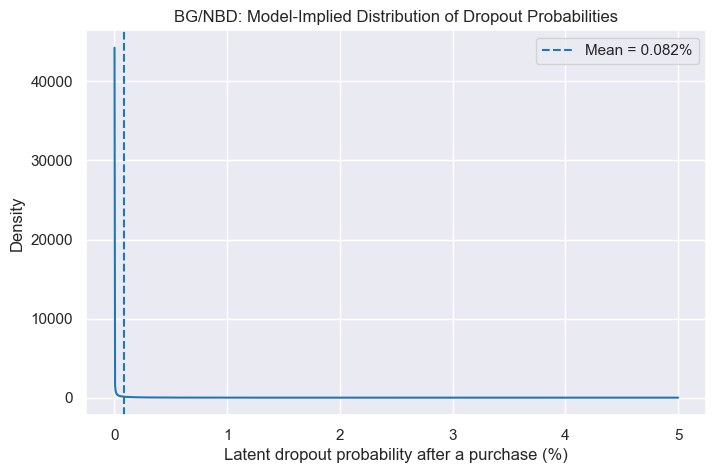

In [39]:
# ----------------------------------------------------------------
# Visualize the Beta distribution of dropout probability
# BG/NBD also assumes each household has its own latent probability of becoming inactive after a transaction: pi ∼ Beta(a,b)
# ---------------------------------------------------------
# Model-implied distribution of household dropout probabilities
# p ~ Beta(a, b)
# ---------------------------------------------------------

mean_dropout_probability = a / (a + b)
print(
    f"Population mean dropout probability: "
    f"{mean_dropout_probability:.6f}"
)

print(
    f"As a percentage: "
    f"{100 * mean_dropout_probability:.3f}%"
)

# Because a < 1, the Beta density becomes extremely large
# as p approaches zero.
# Start slightly above zero to avoid an infinite density.
p_values = np.linspace(
    0.000001,
    0.05,
    1000
)

p_density = beta_dist.pdf(
    p_values,
    a=a,
    b=b
)

plt.figure(figsize=(8, 5))

plt.plot(
    p_values,
    p_density
)

plt.axvline(
    mean_dropout_probability,
    linestyle="--",
    label=f"Mean = {mean_dropout_probability:.4f}"
)

plt.xlabel("Latent dropout probability after a purchase")
plt.ylabel("Density")
plt.title("BG/NBD: Model-Implied Distribution of Household Dropout Probabilities")
plt.legend()

plt.show()

# ----------------------------------------------------------------
# Same dropout distribution, but x-axis shown as percentage
# ----------------------------------------------------------------

p_pct = p_values * 100

plt.figure(figsize=(8, 5))

plt.plot(
    p_pct,
    p_density
)

plt.axvline(
    mean_dropout_probability * 100,
    linestyle="--",
    label=f"Mean = {mean_dropout_probability * 100:.3f}%"
)

plt.xlabel("Latent dropout probability after a purchase (%)")
plt.ylabel("Density")
plt.title("BG/NBD: Model-Implied Distribution of Dropout Probabilities")
plt.legend()

plt.show()


# At the population-average dropout probability, after a purchase there is about a 0.082% probability of becoming permanently inactive under the BG/NBD model.
# But individual households do not all have p = 0.000824.
# And it does not mean that a household has a 0.082% chance of churning each day.
# Conceptually, 
# Customer makes a purchase
#         ↓
# Remains active ─────────────→ can purchase again
#         │
#         └── becomes inactive with probability p
# So p represents the model's latent probability of becoming inactive after a transaction, not a daily churn probability.

# ----------------------------------------------------------------
# Population-level interpretation:
#
# Population mean latent purchase rate: 0.174 purchases/day.
# A customer with exactly this rate would purchase roughly once
# every 5.7 days while active.
#
# Mean latent dropout probability ≈ 0.000824 = 0.082%.
# This is the model-implied probability of becoming inactive
# after a purchase, not per day.
#
# Both are population-level quantities. Individual households
# have different latent purchase rates and dropout probabilities.

## Generate BG/NBD predictions of future baskets over the 167-day holdout period

In [40]:
# ----------------------------------------------------------------
# Predict each household's expected basket count over the exact 167-day horizon.
# ----------------------------------------------------------------
df["predicted_holdout_baskets_bgnbd"] = (
    bgf.conditional_expected_number_of_purchases_up_to_time(
        prediction_horizon_days,
        df["frequency"],
        df["recency_days"],
        df["observation_days"]
    )
)
# ----------------------------------------------------------------
# Check the distributions
# ----------------------------------------------------------------
display(df["predicted_holdout_baskets_bgnbd"].describe())

# ----------------------------------------------------------------
# Check the values
# ----------------------------------------------------------------
display(
    df[[
        "household_key",
        "frequency",
        "recency_days",
        "observation_days",
        "predicted_holdout_baskets_bgnbd",
        "actual_holdout_baskets"
    ]].head(20)
)

# ----------------------------------------------------------------
# Check if predicted_holdout_baskets_bgnbd >= 0
# ----------------------------------------------------------------
assert (
    df["predicted_holdout_baskets_bgnbd"] >= 0
).all()

count   2,498.0000
mean       27.0495
std        30.4061
min         0.0000
25%         8.6326
50%        18.7551
75%        35.3176
max       409.6458
Name: predicted_holdout_baskets_bgnbd, dtype: float64

,household_key,frequency,recency_days,observation_days,predicted_holdout_baskets_bgnbd,actual_holdout_baskets
0,1,61,489.1632,493.3778,20.6126,23
1,2,36,439.0201,441.2056,13.7870,8
2,3,41,418.8979,431.3410,15.9595,5
3,4,25,392.0188,440.3806,9.6078,4
4,5,32,457.0160,459.3472,11.8326,7
5,6,187,425.0194,426.0375,71.5661,61
6,7,33,511.0910,521.3924,10.7559,25
7,8,79,475.4472,479.0910,27.3208,33
8,9,11,405.2306,440.5083,4.5361,8
9,10,6,383.2799,430.3528,2.7421,2


## Model evaluation

In [41]:
# ----------------------------------------------------------------
# Create an evaluation function
# ----------------------------------------------------------------
# Mean Absolute Error (MAE): How many baskets am I typically wrong by?
# Root Mean Squared Error (RMSE): Does the model make some very large mistakes?
# Weighted Absolute Percentage Error (WAPE): How large are all our errors relative to actual purchase volume?
# Aggregate % error: Does the model predict the correct total amount of purchasing?
# Mean bias: Does the model systematically predict too high or too low?
# Spearman correlation: Does the model rank customers correctly?



def evaluate_predictions(
    actual,
    predicted,
    model_name
):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    error = predicted - actual

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    wape = (
        np.abs(error).sum()
        / actual.sum()
    )

    mean_bias = error.mean()

    aggregate_actual = actual.sum()
    aggregate_predicted = predicted.sum()

    aggregate_pct_error = (
        aggregate_predicted
        - aggregate_actual
    ) / aggregate_actual

    spearman_corr = spearmanr(
        actual,
        predicted
    ).statistic

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "mean_bias": mean_bias,
        "actual_baskets_total": aggregate_actual,
        "predicted_baskets_total": aggregate_predicted,
        "aggregate_pct_error": aggregate_pct_error,
        "spearman_correlation": spearman_corr
    }

In [42]:
# ----------------------------------------------------------------
# Evaluate the baseline
# ----------------------------------------------------------------
baseline_metrics = evaluate_predictions(
    actual=df["actual_holdout_baskets"],
    predicted=df["predicted_holdout_baskets_baseline"],
    model_name="Historical-rate baseline"
)

# ----------------------------------------------------------------
# Evaluate BC/NBD
# ----------------------------------------------------------------
bgnbd_metrics = evaluate_predictions(
    actual=df["actual_holdout_baskets"],
    predicted=df["predicted_holdout_baskets_bgnbd"],
    model_name="BG/NBD"
)

# ----------------------------------------------------------------
# Combine the results
# ----------------------------------------------------------------
model_comparison = pd.DataFrame([baseline_metrics, bgnbd_metrics]).set_index("model")
model_comparison[["WAPE", "aggregate_pct_error"]] *= 100
model_comparison.rename(
    columns={
        "WAPE": "WAPE (%)",
        "aggregate_pct_error": "Aggregate error (%)"
    }
)

# Overall prediction performance: BG/NBD performs better, but modestly
    # MAE: BG/NBD is wrong by about 11.36 baskets per household on average, 
    # compared with 11.89 baskets for the benchmark.
    # MAE improvement is 4.40%. 
    # In absolute terms, 11.8877−11.3641=0.5236. BG/NBD model reduces the average absolute error by about 0.52 baskets per household. 

    # RMSEs are substantially larger than MAEs. This tells that there are some households with very large prediction errors.
    # That is not very surprising because the households vary significantly in purchase activity.
    # The customer-level error distribution confirms that there are some very large over- and underpredictions.

    # Aggregate prediction (actual_baskets_total vs. predicted_baskets_total):
        # BG/NBD model: Difference = predicted - actual = 67569.7 − 69733 = -2163.3 (or -2136.3 * 100/ 69733 = -3.10%)
        # So BG/NBD underpredicts total holdout activity by about 3.1%.
        # The baseline: Difference = 71121.7 − 69733 = +1388.7 or +1.99%
# --> Baseline is closer on the overall total, while BG/NBD is better at customer-level prediction

    # Mean bias = Prediction−Actual confirms the direction of error
        # The baseline overpredicts by about 0.56 baskets per customer on average.
        # BG/NBD model underpredicts by about 0.87 baskets per customer on average.
        # This matches the aggregate errors.

    # Spearman: BG/NBD model is better by 0.7832−0.7678 = 0.0154
        # BG/NBD improves ranking only slightly. The historical-rate baseline is already strong. This aligns with our top-20% capture result below. 

,MAE,RMSE,WAPE (%),mean_bias,actual_baskets_total,predicted_baskets_total,Aggregate error (%),spearman_correlation
model,,,,,,,,
Historical-rate baseline,11.8877,21.0558,42.5844,0.5559,"69,733.0000","71,121.7047",1.9915,0.7678
BG/NBD,11.3641,20.0771,40.7087,-0.8660,"69,733.0000","67,569.6765",-3.1023,0.7832


In [43]:
# ----------------------------------------------------------------
# Calculate improvement over benchmark
# ----------------------------------------------------------------
# MAE
# ----------------------------------------------------------------
baseline_mae = model_comparison.loc[
    "Historical-rate baseline",
    "MAE"
]

bgnbd_mae = model_comparison.loc[
    "BG/NBD",
    "MAE"
]

mae_improvement_pct = (
    baseline_mae - bgnbd_mae
) / baseline_mae * 100

print(
    f"BG/NBD MAE improvement over baseline: "
    f"{mae_improvement_pct:.2f}%"
)
# ----------------------------------------------------------------
# RMSE
# ----------------------------------------------------------------
baseline_rmse = model_comparison.loc[
    "Historical-rate baseline",
    "RMSE"
]

bgnbd_rmse = model_comparison.loc[
    "BG/NBD",
    "RMSE"
]

rmse_improvement_pct = (
    baseline_rmse - bgnbd_rmse
) / baseline_rmse * 100

print(
    f"BG/NBD RMSE improvement over baseline: "
    f"{rmse_improvement_pct:.2f}%"
)


# How to decide whether BG/NBD is "better"
# Primary:
    # lower MAE
# Supporting:
    # lower WAPE
    # lower RMSE
    # reasonable aggregate bias
    # higher Spearman ranking correlation
    # better calibration across activity groups

BG/NBD MAE improvement over baseline: 4.40%
BG/NBD RMSE improvement over baseline: 4.65%


In [44]:
# ----------------------------------------------------------------
# Create customer-level prediction errors: 
# ----------------------------------------------------------------
df["baseline_error"] = (
    df["predicted_holdout_baskets_baseline"]
    - df["actual_holdout_baskets"]
)

df["bgnbd_error"] = (
    df["predicted_holdout_baskets_bgnbd"]
    - df["actual_holdout_baskets"]
)

df["baseline_absolute_error"] = (
    df["baseline_error"].abs()
)

df["bgnbd_absolute_error"] = (
    df["bgnbd_error"].abs()
)
# ----------------------------------------------------------------
# Inspect prediction errors:  
# ----------------------------------------------------------------
df[
    [
        "baseline_error",
        "bgnbd_error",
        "baseline_absolute_error",
        "bgnbd_absolute_error"
    ]
].describe()

,baseline_error,bgnbd_error,baseline_absolute_error,bgnbd_absolute_error
count,"2,498.0000","2,498.0000","2,498.0000","2,498.0000"
mean,0.5559,-0.8660,11.8877,11.3641
std,21.0526,20.0624,17.3824,16.5547
min,-138.4189,-142.7408,0.0000,0.0000
25%,-6.9930,-7.6340,2.7019,2.5705
50%,0.3935,0.0338,6.5461,6.2398
75%,6.3025,5.3935,14.7217,14.1790
max,313.9010,298.6458,313.9010,298.6458


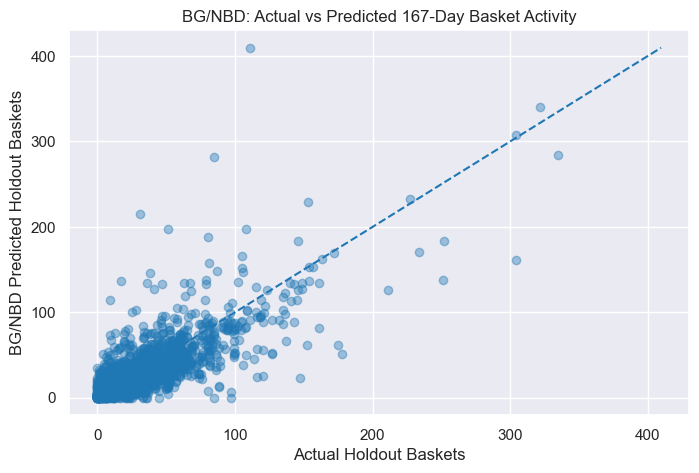

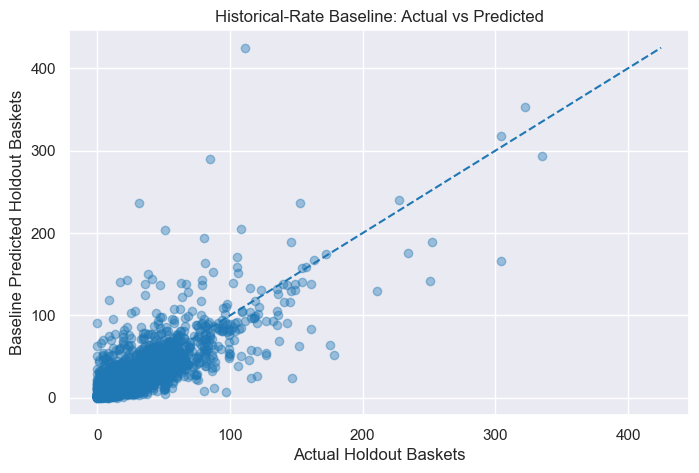

In [45]:
# ----------------------------------------------------------------
# Actual vs predicted: BG/NBD
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["actual_holdout_baskets"],
    df["predicted_holdout_baskets_bgnbd"],
    alpha=0.4
)

max_value = max(
    df["actual_holdout_baskets"].max(),
    df["predicted_holdout_baskets_bgnbd"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Holdout Baskets")
plt.ylabel("BG/NBD Predicted Holdout Baskets")
plt.title("BG/NBD: Actual vs Predicted 167-Day Basket Activity")

plt.show()

# ----------------------------------------------------------------
# Actual vs predicted: Baseline
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["actual_holdout_baskets"],
    df["predicted_holdout_baskets_baseline"],
    alpha=0.4
)

max_value = max(
    df["actual_holdout_baskets"].max(),
    df["predicted_holdout_baskets_baseline"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Holdout Baskets")
plt.ylabel("Baseline Predicted Holdout Baskets")
plt.title("Historical-Rate Baseline: Actual vs Predicted")

plt.show()

# NOTE:
# Each point represents one household. 
# x-axis = actual number of baskets during the 167-day holdout period. 
# y-axis = predicted number of baskets during the same period

# The dashed 45° line represents perfect prediction. 
# points on the line: predicted baskets = actual baskets.
# points above the line: the model overpredicts.
# points below the line: the model underpredicts.

# INTERPRETATION: 
# The two models appear visually similar. 
# Most households are concentrated in the lower-left because most have relatively low-to-moderate holdout activity. 
    # Within this dense area, many predictions seem reasonably near the diagonal, but there is also visible spread above and below it. 
# There are also some clear large errors

## Does the model separate low-activity from high-activity households sensibly?

In [46]:
# ----------------------------------------------------------------
# Evaluate BG/NBD predictions by predicted-activity decile.
# ----------------------------------------------------------------
    # Sort 2,498 households from lowest to highest predicted future activity, then divide them into 10 groups:
    # | Decile | Meaning                        | Approx. customers |
    # | ------ | ------------------------------ | ----------------: |
    # | 1      | Lowest 10% predicted activity  |              ~250 |
    # | 2      | Next 10%                       |              ~250 |
    # | 3      | Next 10%                       |              ~250 |
    # | ...    | ...                            |               ... |
    # | 9      | Second-highest 10%             |              ~250 |
    # | 10     | Highest 10% predicted activity |              ~250 |

# We compare the average predicted future baskets with the average actual
# holdout baskets for each customer group.
#
# This is important because we later want to profile customers based on
# their predicted future activity 
# (e.g. households belong to the highest predicted future-activity segment.)
#
# If the model ranks customers well, groups with higher predicted activity
# should also have higher actual activity in the holdout period.


# Rank households by predicted activity and divide that ranking into 10 groups
df["household_baskets_decile"] = pd.qcut(
    df[
        "predicted_holdout_baskets_bgnbd"
    ].rank(method="first"),                # Rank households by predicted activity
    q=10,                                  # Split households into 10 approximately equal-sized groups.
    labels=range(1, 11)
)
df.head()

,household_key,frequency,recency_days,observation_days,prediction_horizon_days,actual_holdout_baskets,actual_holdout_purchase_days,actual_holdout_active_weeks,actual_holdout_sales,was_active_in_holdout,in_sample_baskets,active_weeks,days_since_last_purchase,historical_sales,average_basket_value,historical_quantity,retail_discount_basket_rate,retail_discount_per_basket,total_retail_discount,manufacturer_coupon_basket_rate,total_manufacturer_coupon,manufacturer_coupon_amount_per_redeeming_basket,retail_coupon_match_basket_rate,retail_coupon_match_per_basket,total_retail_coupon_match,estimated_pre_retail_discount_value,historical_sales_quintile,historical_repeat_rate_per_day,predicted_holdout_baskets_baseline,probability_alive,predicted_holdout_baskets_bgnbd,baseline_error,bgnbd_error,baseline_absolute_error,bgnbd_absolute_error,household_baskets_decile
0,1,61,489.1632,493.3778,167,23,22,18,"1,187.5000",True,62,50,4.2146,"3,142.6600",50.6900,1454,0.8065,8.6276,534.9100,0.3548,65.6800,2.9855,0.3065,0.3169,19.6500,"3,697.2200",Q4,0.1236,20.6475,0.9990,20.6126,-2.3525,-2.3874,2.3525,2.3874,6
1,2,36,439.0201,441.2056,167,8,8,7,461.5800,True,37,28,2.1854,"1,492.7600",40.3400,621,0.9459,7.1757,265.5000,0.1081,7.0000,1.7500,0.0000,0.0000,0.0000,"1,758.2600",Q3,0.0816,13.6263,0.9992,13.7870,5.6263,5.7870,5.6263,5.7870,5
2,3,41,418.8979,431.3410,167,5,5,5,134.4100,True,42,32,12.4431,"2,518.8000",59.9700,8444,0.9762,15.4083,647.1500,0.1190,61.1900,12.2380,0.1190,0.4714,19.8000,"3,185.7500",Q4,0.0951,15.8738,0.9977,15.9595,10.8738,10.9595,10.8738,10.9595,5
3,4,25,392.0188,440.3806,167,4,4,4,141.9300,True,26,22,48.3618,"1,058.1800",40.7000,330,0.9231,4.0065,104.1700,0.0385,2.5000,2.5000,0.0000,0.0000,0.0000,"1,162.3500",Q2,0.0568,9.4804,0.9857,9.6078,5.4804,5.6078,5.4804,5.6078,3
4,5,32,457.0160,459.3472,167,7,6,5,108.9400,True,33,22,2.3312,670.1200,20.3100,227,0.8182,3.4045,112.3500,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,782.4700,Q2,0.0697,11.6339,0.9992,11.8326,4.6339,4.8326,4.6339,4.8326,4


In [47]:
bgnbd_decile_summary = (
    df
    .groupby(
        "household_baskets_decile",
        observed=True
    )
    .agg(
        households_count=("household_key", "size"),
        mean_predicted_baskets=("predicted_holdout_baskets_bgnbd", "mean"),
        mean_actual_baskets=("actual_holdout_baskets", "mean"),
        total_actual_baskets=("actual_holdout_baskets", "sum")
    )
    .reset_index()
)

bgnbd_decile_summary

# Actual activity: D1 < D2 < D3 <⋯ < D10
# Every increase in predicted-activity decile corresponds to an increase in actual future activity.
# This is an evidence that BG/NBD is ranking customers sensibly, 
# supporting using the BG/NBD prediction later when we profile households according to expected future activity.

# However: ranking is strong, while calibration (how close predicted to actual) is not perfect. 
# It predicts the lowest customers too low and the highest customers too high.
    # LOW predicted activity (D1, D2, D3, D4)
    # BG/NBD prediction < actual (underpredict)
    #         ↓
    #         ↓
    # Middle groups (D5, D6, D7, D8, D9)
    # predicted ≈ actual (quite close)
    #         ↓
    #         ↓
    # VERY HIGH predicted activity (D10)
    # BG/NBD prediction > actual (overpredict)

# D10: The highest predicted 10% consists of 250 customers, but they had 20778 actual baskets / 69733 total baskets (~ 29.8%)
    # So, these 10% of customers generated almost 30% of holdout basket activity.
# D9 + D10: together generate 12352 + 20778 = 33130 (~ 47.5%)

,household_baskets_decile,households_count,mean_predicted_baskets,mean_actual_baskets,total_actual_baskets
0,1,250,1.4726,6.4200,1605
1,2,250,5.2922,8.4760,2119
2,3,250,8.6601,11.4400,2860
3,4,249,12.0356,14.1727,3529
4,5,250,16.0689,17.5560,4389
5,6,250,21.4950,22.9640,5741
6,7,249,27.4876,30.2691,7537
7,8,250,35.1881,35.2920,8823
8,9,250,47.6199,49.4080,12352
9,10,250,95.1169,83.1120,20778


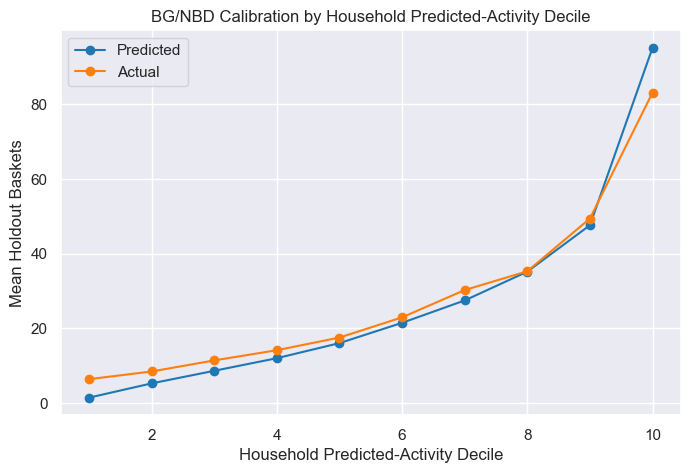

In [48]:
# ----------------------------------------------------------------
# Plot the 10 groups 
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    bgnbd_decile_summary["household_baskets_decile"],
    bgnbd_decile_summary["mean_predicted_baskets"],
    marker="o",
    label="Predicted"
)

plt.plot(
    bgnbd_decile_summary["household_baskets_decile"],
    bgnbd_decile_summary["mean_actual_baskets"],
    marker="o",
    label="Actual"
)

plt.xlabel("Household Predicted-Activity Decile")
plt.ylabel("Mean Holdout Baskets")
plt.title("BG/NBD Calibration by Household Predicted-Activity Decile")
plt.legend()

plt.show()

## Top-20% activity capture

In [49]:
# ----------------------------------------------------------------
# Check targeting/ranking usefulness
# We have 2498 households. The top 20% of households means 2498 * 0.2 = 500 households are most likely to be active
# If BG/NBD model result tells us which ~500 customers are most likely to be active, what percentage of all actual future baskets came from those ~500 customers?
# ----------------------------------------------------------------
def top_share_capture(
    data,
    score_column,     # prediction used to rank households
    actual_column,    # real outcomes
    top_share=0.20    
):
    n_top = int(np.ceil(len(data) * top_share))        # the number of selected households

    top_customers = data.nlargest(n_top, score_column) # find the highest-scoring customers, ranked by predicted future baskets

    return top_customers[actual_column].sum() / data[actual_column].sum()   # calculate how much real future activity these households account for


In [50]:
# ----------------------------------------------------------------
# BG/NBD top-20% result
# ----------------------------------------------------------------
bgnbd_top20_capture = top_share_capture(
    df,
    score_column="predicted_holdout_baskets_bgnbd",
    actual_column="actual_holdout_baskets"
)

print(f"BG/NBD top-20% activity capture: {bgnbd_top20_capture:.1%}")

# Baseline top-20% result:
baseline_top20_capture = top_share_capture(
    df,
    score_column="predicted_holdout_baskets_baseline",
    actual_column="actual_holdout_baskets"
)

print(f"Baseline top-20% activity capture: {baseline_top20_capture:.1%}")

# Ranking customers by BG/NBD predictions allowed the top 20% of customers to capture 47.5% of observed holdout baskets,
# compared with 46.9% using the historical-frequency baseline in holdout period. 
# The improvement is only 47.5% - 46.9% = 0.6 percentage points 
# So BG/NBD only marginally improves the top-20% targeting ranking over the simple historical-rate baseline.
# As seen above, our baseline is already quite strong because historically frequent customers tend to remain relatively frequent.

BG/NBD top-20% activity capture: 47.5%
Baseline top-20% activity capture: 46.9%


## Bootstrap the MAE improvement

In [51]:
# ----------------------------------------------------------------
# BG/NBD MAE improvement over baseline: 4.40% 
# Is that 4.40% improvement reasonably consistent across customers, 
# or could it easily disappear if our customer sample were slightly different?
# ----------------------------------------------------------------
# Bootstrap sampling (sampling is with replacement) to create a slightly different version of the dataset.
    # 2,498 households
    # Draw 2,498 households randomly, but after every draw, put the households back into the pool.
    # Some households would appear multiple times, and some might not appear at all. 
    # Calulate the Baseline MAE, BG/NBD MAE, and their difference
    # Repeat this n_bootstrap times. 

# Set a random-number generator
rng = np.random.default_rng(
    RANDOM_SEED
)

# Create 2,000 bootstrap samples
n_bootstrap = 2000   

# Store 2,000 estimated MAE improvements
mae_improvements = []

actual = df["actual_holdout_baskets"].to_numpy()
baseline_pred = df["predicted_holdout_baskets_baseline"].to_numpy()
bgnbd_pred = df["predicted_holdout_baskets_bgnbd"].to_numpy()
n = len(df) 

# The bootstrap loop, repeating n_bootstrap times
for _ in range(n_bootstrap):
    # Generate 2,498 random household positions
    idx = rng.integers(      
        0,
        n,
        size=n       
    )
    # Calculate 
    baseline_mae_boot = mean_absolute_error(
        actual[idx],
        baseline_pred[idx]
    )

    bgnbd_mae_boot = mean_absolute_error(
        actual[idx],
        bgnbd_pred[idx]
    )

    mae_improvements.append(
        baseline_mae_boot
        - bgnbd_mae_boot
    )

# Takes three percentiles of the 2,000 estimated MAE improvements
# 2.5th percentile, 50th percentile, and 97.5th percentile
result = np.quantile(mae_improvements, [0.025, 0.50, 0.975])
print(result)

# 2.5%  = +0.31384899
# median = +0.52225406
# 97.5% = +0.7562356 
# Every value is positive.
# So across resampled customer sets, BG/NBD almost consistently had a lower MAE.
# BG/NBD's MAE improvement over the baseline appears stable across customer resamples,
# with an approximate 95% bootstrap interval of 0.31–0.76 fewer baskets of absolute error per customer.
# --> The improvement appears very robust, but its magnitude remains modest.

[0.31384899 0.52225406 0.7562356 ]


## Diagnostics

In [52]:
# ----------------------------------------------------------------
# Inspect the customers with unusually low probability_alive
# ----------------------------------------------------------------
df[
    [
        "household_key",
        "frequency",
        "recency_days",
        "observation_days",
        "days_since_last_purchase",
        "probability_alive",
        "predicted_holdout_baskets_bgnbd",
        "actual_holdout_baskets"
    ]
].sort_values(
    "probability_alive"
).head(20)

# We're checking whether these are sensible cases such as:
# many earlier purchases
# +
# very long time since last purchase
# → low probability alive
# rather than data errors.

,household_key,frequency,recency_days,observation_days,days_since_last_purchase,probability_alive,predicted_holdout_baskets_bgnbd,actual_holdout_baskets
859,860,49,87.6604,468.2021,380.5417,0.0000,0.0000,2
1791,1792,80,210.0410,470.3833,260.3424,0.0000,0.0000,45
2037,2039,40,108.9771,533.2979,424.3208,0.0000,0.0000,33
1678,1679,35,96.2306,514.3375,418.1069,0.0000,0.0000,10
2345,2348,53,168.1500,448.2354,280.0854,0.0000,0.0000,2
2049,2051,287,446.6854,529.0243,82.3389,0.0000,0.0000,0
2008,2010,34,117.0972,439.2514,322.1542,0.0000,0.0000,23
854,855,123,309.7708,432.1431,122.3722,0.0000,0.0000,85
1643,1644,9,3.3833,431.5826,428.1993,0.0000,0.0000,16
1817,1818,36,188.0139,529.1597,341.1458,0.0000,0.0000,35


In [53]:
# Inspect the largest BG/NBD prediction errors
df[
    [
        "household_key",
        "frequency",
        "recency_days",
        "observation_days",
        "predicted_holdout_baskets_bgnbd",
        "actual_holdout_baskets",
        "bgnbd_error",
        "bgnbd_absolute_error"
    ]
].sort_values(
    "bgnbd_absolute_error",
    ascending=False
).head(20)

,household_key,frequency,recency_days,observation_days,predicted_holdout_baskets_bgnbd,actual_holdout_baskets,bgnbd_error,bgnbd_absolute_error
2334,2337,1095,430.2069,430.3708,409.6458,111,298.6458,298.6458
2456,2459,884,508.8562,509.1861,281.2603,85,196.2603,196.2603
908,909,675,472.8813,477.1236,214.9640,31,183.9640,183.9640
231,232,576,470.4792,471.0924,198.0042,51,147.0042,147.0042
1466,1467,530,534.4271,534.5417,161.2592,304,-142.7408,142.7408
2250,2252,167,532.9792,533.5014,51.4096,178,-126.5904,126.5904
441,442,66,466.7042,467.2688,23.4884,147,-123.5116,123.5116
2038,2040,404,477.9340,478.3299,137.1694,17,120.1694,120.1694
2068,2070,383,450.9361,452.0319,137.3886,251,-113.6114,113.6114
1565,1566,171,445.7937,449.0840,62.1932,175,-112.8068,112.8068


In [54]:
# Quantify decile calibration directly
bgnbd_decile_summary[
    "mean_error"
] = (
    bgnbd_decile_summary[
        "mean_predicted_baskets"
    ]
    - bgnbd_decile_summary[
        "mean_actual_baskets"
    ]
)

bgnbd_decile_summary[
    "pct_error"
] = (
    bgnbd_decile_summary["mean_error"]
    / bgnbd_decile_summary[
        "mean_actual_baskets"
    ]
    * 100
)

bgnbd_decile_summary

,household_baskets_decile,households_count,mean_predicted_baskets,mean_actual_baskets,total_actual_baskets,mean_error,pct_error
0,1,250,1.4726,6.4200,1605,-4.9474,-77.0621
1,2,250,5.2922,8.4760,2119,-3.1838,-37.5624
2,3,250,8.6601,11.4400,2860,-2.7799,-24.3001
3,4,249,12.0356,14.1727,3529,-2.1371,-15.0792
4,5,250,16.0689,17.5560,4389,-1.4871,-8.4709
5,6,250,21.4950,22.9640,5741,-1.4690,-6.3970
6,7,249,27.4876,30.2691,7537,-2.7814,-9.1891
7,8,250,35.1881,35.2920,8823,-0.1039,-0.2944
8,9,250,47.6199,49.4080,12352,-1.7881,-3.6191
9,10,250,95.1169,83.1120,20778,12.0049,14.4442


**BG/NBD evaluation and justification**

BG/NBD performs slightly better than the simple historical purchase-rate benchmark, although the improvement is modest. The benchmark calculates each household's historical repeat-purchase rate and assumes that this rate will continue over the next 167 days. BG/NBD uses more information about the household's purchase history: its repeat-purchase frequency, the timing of its most recent repeat purchase within its observed history, and the length of time it was observed. It uses these patterns to estimate expected future purchase activity. 

In the 167-day holdout period, BG/NBD had a mean absolute error (MAE) of 11.36 baskets per household, compared with 11.89 baskets for the historical purchase-rate benchmark. In practical terms, the BG/NBD prediction was, on average, about 0.52 baskets closer to each household's actual holdout basket count, corresponding to a 4.4% reduction in MAE.

BG/NBD also performed slightly better at ranking households by future activity. Here, ranking does not mean predicting the exact number of baskets correctly. It means placing households in approximately the right order from lower to higher future purchase activity. The Spearman rank correlation between predicted and actual holdout basket counts was 0.783 for BG/NBD, compared with 0.768 for the benchmark. A higher Spearman correlation means that households receiving higher predictions were somewhat more likely to also have higher actual activity in the holdout period. The difference is small, so BG/NBD should be viewed as a modest improvement rather than a major improvement over the benchmark.

This ranking performance is particularly relevant to the purpose of this project. We do not mainly need to know that a particular household will make exactly, for example, 30 future baskets. Instead, we want to distinguish households that are expected to be relatively more or less active in the future, so that expected future activity can be used as one dimension of customer profiling and prioritization.

 To examine this more directly, the 2,498 households were sorted from the lowest to the highest BG/NBD predicted basket count and divided into ten predicted-activity groups, or deciles. Because 2,498 is not exactly divisible by ten, each group contains either 249 or 250 households. The first decile contains the 250 households with the lowest BG/NBD predictions, while the tenth decile contains the 250 households with the highest BG/NBD predictions. Therefore, “lowest predicted 10%” means the households that BG/NBD expected to have the lowest future purchase activity; it does not mean that they were predicted to make 10% fewer purchases.

The holdout results support using BG/NBD as a relative ranking of future activity. The average number of baskets actually observed in the holdout period increased in every successive predicted-activity group. The 250 households in the lowest predicted group made about 6.4 baskets per household on average, while the 250 households in the highest predicted group made about 83.1 baskets on average. In other words, households that BG/NBD placed toward the top of the ranking subsequently purchased much more frequently than households placed toward the bottom.

The concentration of actual future activity provides another way to see this. The 500 households with the highest BG/NBD predictions—approximately the top 20% of households—accounted for 47.5% of all baskets actually observed during the holdout period. The historical purchase-rate benchmark captured 46.9%, so BG/NBD's advantage on this measure is only 0.6 percentage points. This again suggests that BG/NBD provides a useful ranking, but only a small improvement over an already strong benchmark.

However, a useful ranking does not mean that the exact predicted basket counts are accurate. For example, the lowest predicted group was forecast to make about 1.5 baskets per household on average, but actually made 6.4. At the other extreme, the highest predicted group was forecast to make about 95.1 baskets on average, but actually made about 83.1. BG/NBD therefore successfully separates these groups as relatively low and high activity, but the exact predicted levels are not perfectly calibrated, particularly at the extremes.

The historical purchase-rate benchmark also remains competitive in another important respect: it predicts the total number of baskets across all households slightly more accurately. The benchmark overpredicted total holdout activity by about 2.0%, whereas BG/NBD underpredicted it by about 3.1%. BG/NBD therefore does not outperform the benchmark on every evaluation measure. 

Finally, the bootstrap analysis helps assess whether the improvement in household-level MAE is reasonably consistent within this dataset. The households were resampled 2,000 times, and the difference between the benchmark MAE and BG/NBD MAE was recalculated each time. The approximate 95% bootstrap interval for the MAE improvement was 0.31 to 0.76 fewer baskets of absolute error per household. Because the entire interval is above zero, the direction of the MAE improvement appears stable across these household resamples, although the size of the improvement remains modest. This does not establish that BG/NBD would necessarily outperform the benchmark in another retailer or time period; it supports the consistency of the improvement within this dataset.    

Overall, we retain BG/NBD because it provides a modest but reasonably consistent improvement in household-level prediction and a small improvement in ranking, while its predicted-activity groups also correspond clearly to different levels of actual future purchasing. These properties are relevant to the purpose of this project, where expected future activity is used to profile and prioritize households, rather than to forecast total retailer basket volume. We therefore use BG/NBD primarily as a measure of relative expected future activity—to distinguish households expected to be more or less active—rather than as a precise forecast of exactly how many baskets each household will make.              

## Historical sales vs predicted-activity relationship

Historical sales vs BG/NBD predicted future activity: 0.816


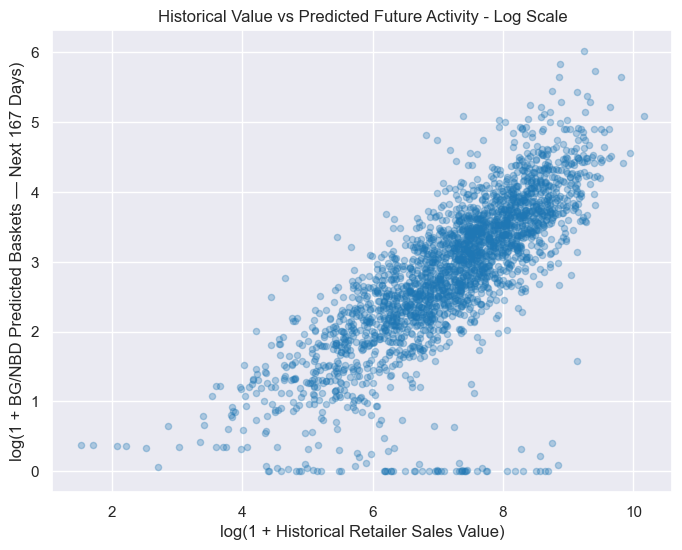

In [55]:
# Historical contribution asks How much retailer sales value has this household generated for us so far?
     # historical sales is backward-looking.
# Expected future baskets asksHow much purchasing activity do we expect from this household going forward?
    # BG/NBD considers the pattern of purchase occasions, including frequency, recency and observation time, 
    # then predict the future baskets
# ---------------------------------------------------------
# How strongly are historical retailer sales value and predicted future baskets
# associated across households?
# Do households that rank high on historical sales also tend to rank high on predicted future basket activity?
# 
# ---------------------------------------------------------

sales_vs_predicted_baskets = spearmanr(
    df["historical_sales"],
    df["predicted_holdout_baskets_bgnbd"]
)

print(
    "Historical sales vs BG/NBD predicted future activity:",
    round(sales_vs_predicted_baskets.statistic, 3)
)

# Plot 
plt.figure(figsize=(8, 6))

plt.scatter(
    np.log1p(df["historical_sales"]),
    np.log1p(df["predicted_holdout_baskets_bgnbd"]),
    alpha=0.30,
    s=20
)

plt.xlabel("log(1 + Historical Retailer Sales Value)")
plt.ylabel("log(1 + BG/NBD Predicted Baskets — Next 167 Days)")
plt.title("Historical Value vs Predicted Future Activity - Log Scale")

plt.show()


# INTERPRETATION:
# There is a strong positive rank association between historical retailer sales value 
# and BG/NBD predicted future baskets. (how similarly households are ranked by the two measures)
# Households with higher historical sales generally also receive higher BG/NBD predictions 
# for future basket activity.

# This makes sense in our data because historical sales are strongly related to how frequently 
# households have shopped, while BG/NBD also uses purchase frequency—along with recency and 
# observation time—to estimate future activity.

# However, 0.816 is not a perfect correlation. So the two measures are strongly related, but 
# they do not rank every household in exactly the same way.
# For example: 
# Household A and B
# → similar historical sales
# but
# A → higher predicted future baskets
# B → lower predicted future baskets

# Next, we check: 
# among households with similar historical sales, do those with higher BG/NBD predictions 
# actually go on to make more purchases in the holdout period?
# If they do, then BG/NBD is adding useful information beyond historical sales. That would justify keeping the two dimensions separately:

# Historical sales = how much retailer sales value the household generated in the past.
# Predicted future activity = how active the household is expected to be going forward.

In [56]:
df[["household_key", "frequency", "recency_days", "observation_days", "historical_sales", "historical_sales_quintile"]]

,household_key,frequency,recency_days,observation_days,historical_sales,historical_sales_quintile
0,1,61,489.1632,493.3778,"3,142.6600",Q4
1,2,36,439.0201,441.2056,"1,492.7600",Q3
2,3,41,418.8979,431.3410,"2,518.8000",Q4
3,4,25,392.0188,440.3806,"1,058.1800",Q2
4,5,32,457.0160,459.3472,670.1200,Q2
...,...,...,...,...,...,...
2493,2496,47,412.1812,427.4271,"3,314.2600",Q4
2494,2497,171,462.1313,466.5271,"5,363.2400",Q5 - Highest
2495,2498,116,434.9764,439.2340,"1,889.8600",Q3
2496,2499,70,474.1625,474.5444,"2,024.0400",Q4


### Does BG/NBD Add Useful Differentiation Among Customers with Similar Historical Sales?
Does BG/NBD Add Information Beyond Historical Sales?

In [61]:
# Create comparison groups 
# ---------------------------------------------------------
# Within each historical-sales quintile , calculate the
# median BG/NBD prediction of future baskets (predicted activity) 
# ---------------------------------------------------------

# Assign the same median historical sales value to every household 
# in a quintile. 
df["median_predicted_baskets_within_sales_quintile"] = (
    df
    .groupby(                                
        "historical_sales_quintile",
        observed=True
    )["predicted_holdout_baskets_bgnbd"]
    .transform("median")                    # transform() returns a value for every household, while preserving the original dataframe shape
)

# ---------------------------------------------------------
# Within each historical-value quintile, classify each
# household as having relatively higher or lower predicted future baskets
# ---------------------------------------------------------

df["relative_predicted_baskets"] = np.where(
    df["predicted_holdout_baskets_bgnbd"] >= df["median_predicted_baskets_within_sales_quintile"],
    "Higher predicted baskets",
    "Lower predicted baskets"
)


# ---------------------------------------------------------
# Check the group sizes
# ---------------------------------------------------------

within_sales_counts = pd.crosstab(
    df["historical_sales_quintile"],
    df["relative_predicted_baskets"]
)

display(within_sales_counts)


relative_predicted_baskets,Higher predicted baskets,Lower predicted baskets
historical_sales_quintile,,
Q1 - Lowest,250,250
Q2,250,249
Q3,250,250
Q4,250,249
Q5 - Highest,250,250


In [72]:
# =========================================================
# Among households with broadly similar historical sales,
# does BG/NBD distinguish households with different levels
# of subsequent holdout basket activity?
# =========================================================

within_sales_baskets_summary = (
    df
    .groupby(
        [
            "historical_sales_quintile",
            "relative_predicted_baskets"
        ],
        observed=True
    )
    .agg(
        households=(
            "household_key",
            "size"
        ),

        # Historical sales
        historical_sales_mean=(
            "historical_sales",
            "mean"
        ),

        historical_sales_median=(
            "historical_sales",
            "median"
        ),

        # BG/NBD prediction used to define the groups
        predicted_baskets_mean=(
            "predicted_holdout_baskets_bgnbd",
            "mean"
        ),

        predicted_baskets_median=(
            "predicted_holdout_baskets_bgnbd",
            "median"
        ),

        # Actual basket activity observed in the holdout period
        actual_holdout_baskets_mean=(
            "actual_holdout_baskets",
            "mean"
        ),

        actual_holdout_baskets_median=(
            "actual_holdout_baskets",
            "median"
        ),

        # Share of households making at least one
        # purchase during the holdout period
        share_active_in_holdout=(
            "was_active_in_holdout",
            "mean"
        )
    )
    .reset_index()
)

print(
    "Table 1. Historical Sales and BG/NBD Prediction Groups "
    "with Actual Holdout Baskets"
)
display(within_sales_baskets_summary)


# =========================================================
# Presentation table
#
# The BG/NBD prediction determines whether a household belongs
# to the lower- or higher-predicted group within its historical-
# sales quintile.
#
# The values shown below are the ACTUAL mean basket counts
# observed during the 167-day holdout period.
# =========================================================

within_sales_baskets_comparison = (
    within_sales_baskets_summary
    .pivot(
        index="historical_sales_quintile",
        columns="relative_predicted_baskets",
        values="actual_holdout_baskets_mean"
    )
    .rename(
        columns={
            "Lower predicted baskets":
                "Mean actual holdout baskets - lower predicted group",

            "Higher predicted baskets":
                "Mean actual holdout baskets - higher predicted group"
        }
    )
)


# ---------------------------------------------------------
# Difference in mean ACTUAL holdout baskets:
#
# Higher-predicted group
# minus
# Lower-predicted group
# ---------------------------------------------------------

within_sales_baskets_comparison[
    "Difference in actual holdout baskets"
] = (
    within_sales_baskets_comparison[
        "Mean actual holdout baskets - higher predicted group"
    ]
    -
    within_sales_baskets_comparison[
        "Mean actual holdout baskets - lower predicted group"
    ]
)


# ---------------------------------------------------------
# Put columns in a clear order
# ---------------------------------------------------------

within_sales_baskets_comparison = (
    within_sales_baskets_comparison[
        [
            "Mean actual holdout baskets - lower predicted group",
            "Mean actual holdout baskets - higher predicted group",
            "Difference in actual holdout baskets"
        ]
    ]
    .round(2)
    .reset_index()
)

print(
    "\n"
    "Table 2. Mean Actual Holdout Baskets by Historical-Sales Quintile "
    "and BG/NBD Prediction Group"
)

display(within_sales_baskets_comparison)


# =========================================================
# Reprint for Does historical sales contain any information about future basket activity at all?
# =========================================================
print(
    "Table 0. Actual Holdout Basket Activity by Historical-Sales Quintile"
)

display(historical_sales_holdout_baskets_summary)

# =========================================================
# Historical sales
#         ↓
# Place households into Q1–Q5
#         ↓
# Within each quintile:
# BG/NBD prediction
#         ↓
# Lower predicted vs Higher predicted
#         ↓
# Look at ACTUAL holdout baskets
#         ↓
# Higher-predicted group consistently made more baskets
# INTERPRETATION: 
# Among households with broadly similar historical sales, 
# does BG/NBD help distinguish which households will be more 
# versus less active in the holdout period?

# The answer is yes.

# Households were first divided into five historical-sales quintiles, 
# from Q1 (lowest historical sales) to Q5 (highest historical sales). 
# Then, within each quintile, households were split into two groups based on 
# their BG/NBD prediction: 
    # Lower predicted group = households with a BG/NBD-predicted basket count 
        # below the median for that historical-sales quintile.
    # Higher predicted group = households with a BG/NBD prediction  
        # at or above the median for that quintile.
# Importantly, these labels are relative within each historical-sales quintile. 
# A household in the “higher predicted” group in Q1 is not necessarily predicted 
# to be more active than a household in the “lower predicted” group in Q5.

# The table then compares the actual number of baskets that those households made 
# during the 167-day holdout period. Here, we the same pattern: 
# households with higher BG/NBD predictions subsequently made more actual holdout baskets 
# than households with lower BG/NBD predictions.

# For example, consider Q3. All Q3 households belong to the same broad middle historical-sales group. 
# However, the households that BG/NBD classified as relatively lower future activity made only 14.66 actual holdout baskets on average, 
# while those classified as relatively higher future activity made 34.24 baskets. That is a difference of 19.58 baskets per household.

# So historical sales alone would place all these households in Q3, but BG/NBD identifies an additional distinction within Q3 
# that corresponds to a large difference in what they subsequently did.
# The same pattern occurs across all five groups:
# Q1: +7.03 baskets
# Q2: +11.97
# Q3: +19.58
# Q4: +22.23
# Q5: +44.87

# This supports the idea that BG/NBD is not simply reproducing the historical-sales grouping. 
# It provides additional predictive differentiation among households with broadly similar historical sale. 


# Take Q3.
# From the first analysis (Table 0):
# Q3 households make 24.45 holdout baskets on average.
# That is useful, but it treats all Q3 households as one broad group.
# The BG/NBD analysis (Table 1 & 2) reveals that Q3 actually contains two very different future-activity groups:
# lower BG/NBD-predicted group → 14.66 actual baskets
# higher BG/NBD-predicted group → 34.24 actual baskets
# The overall Q3 average of 24.45 is therefore hiding substantial differences within the quintile.
# The same thing happens in every quintile.

Table 1. Historical Sales and BG/NBD Prediction Groups with Actual Holdout Baskets


,historical_sales_quintile,relative_predicted_baskets,households,historical_sales_mean,historical_sales_median,predicted_baskets_mean,predicted_baskets_median,actual_holdout_baskets_mean,actual_holdout_baskets_median,share_active_in_holdout
0,Q1 - Lowest,Higher predicted baskets,250,340.8071,350.2050,9.1432,7.9016,11.7720,9.0000,0.9680
1,Q1 - Lowest,Lower predicted baskets,250,201.9474,174.5000,2.2059,2.3267,4.7440,3.0000,0.8000
2,Q2,Higher predicted baskets,250,862.3199,878.1050,19.0299,16.3296,22.2240,17.0000,0.9760
3,Q2,Lower predicted baskets,249,770.6713,749.9500,7.0607,7.6490,10.2530,8.0000,0.9920
4,Q3,Higher predicted baskets,250,"1,626.9804","1,640.8450",32.0886,28.2504,34.2400,30.0000,1.0000
5,Q3,Lower predicted baskets,250,"1,522.6162","1,518.8050",12.5604,13.0819,14.6600,13.0000,0.9840
6,Q4,Higher predicted baskets,250,"2,876.1342","2,892.3300",45.3718,39.9525,44.4400,38.5000,0.9960
7,Q4,Lower predicted baskets,249,"2,683.1964","2,573.0600",20.1831,21.2390,22.2088,20.0000,0.9960
8,Q5 - Highest,Higher predicted baskets,250,"7,268.5030","6,125.9350",89.6512,75.2142,79.6960,67.5000,1.0000
9,Q5 - Highest,Lower predicted baskets,250,"5,468.1216","5,016.5050",33.0930,35.3460,34.8240,33.0000,0.9880



Table 2. Mean Actual Holdout Baskets by Historical-Sales Quintile and BG/NBD Prediction Group


relative_predicted_baskets,historical_sales_quintile,Mean actual holdout baskets - lower predicted group,Mean actual holdout baskets - higher predicted group,Difference in actual holdout baskets
0,Q1 - Lowest,4.7400,11.7700,7.0300
1,Q2,10.2500,22.2200,11.9700
2,Q3,14.6600,34.2400,19.5800
3,Q4,22.2100,44.4400,22.2300
4,Q5 - Highest,34.8200,79.7000,44.8700


Table 0. Actual Holdout Basket Activity by Historical-Sales Quintile


,historical_sales_quintile,customers,historical_sales_median,actual_holdout_baskets_mean,actual_holdout_baskets_median,actual_holdout_baskets_q25,actual_holdout_baskets_q75
0,Q1 - Lowest,500,263.0000,8.2580,5.0000,2.0000,11.0000
1,Q2,499,818.6800,16.2505,12.0000,6.5000,20.0000
2,Q3,500,"1,571.5000",24.4500,19.0000,11.0000,31.2500
3,Q4,499,"2,741.0100",33.3467,28.0000,17.0000,43.0000
4,Q5 - Highest,500,"5,488.0550",57.2600,47.0000,31.0000,71.5000


In [59]:
# Calculate the incremental future-activity difference
# Does BG/NBD add information beyond historical value?
actual_baskets_pivot = (
    within_value_baskets_summary
    .pivot(
        index="historical_sales_quintile",
        columns="relative_predicted_baskets",
        values="actual_holdout_baskets_mean"
    )
)

actual_baskets_pivot[
    "actual_basket_difference"
] = (
    actual_baskets_pivot[
        "Higher predicted baskets"
    ]
    - actual_baskets_pivot[
        "Lower predicted baskets"
    ]
)

actual_baskets_pivot[
    "actual_basket_uplift_pct"
] = (
    actual_baskets_pivot[
        "actual_basket_difference"
    ]
    / actual_baskets_pivot[
        "Lower predicted baskets"
    ]
    * 100
)

actual_baskets_pivot

# INTERPRETATION: 
# Both sets of households belonged to the same historical-value quintile, 
# yet those identified by BG/NBD as relatively higher future activity subsequently generated substantially more holdout baskets.

relative_predicted_baskets,Higher predicted activity,Lower predicted activity,actual_basket_difference,actual_basket_uplift_pct
historical_sales_quintile,,,,
Q1 - Lowest,11.7720,4.7440,7.0280,148.1450
Q2,22.2240,10.2530,11.9710,116.7558
Q3,34.2400,14.6600,19.5800,133.5607
Q4,44.4400,22.2088,22.2312,100.1005
Q5 - Highest,79.6960,34.8240,44.8720,128.8537


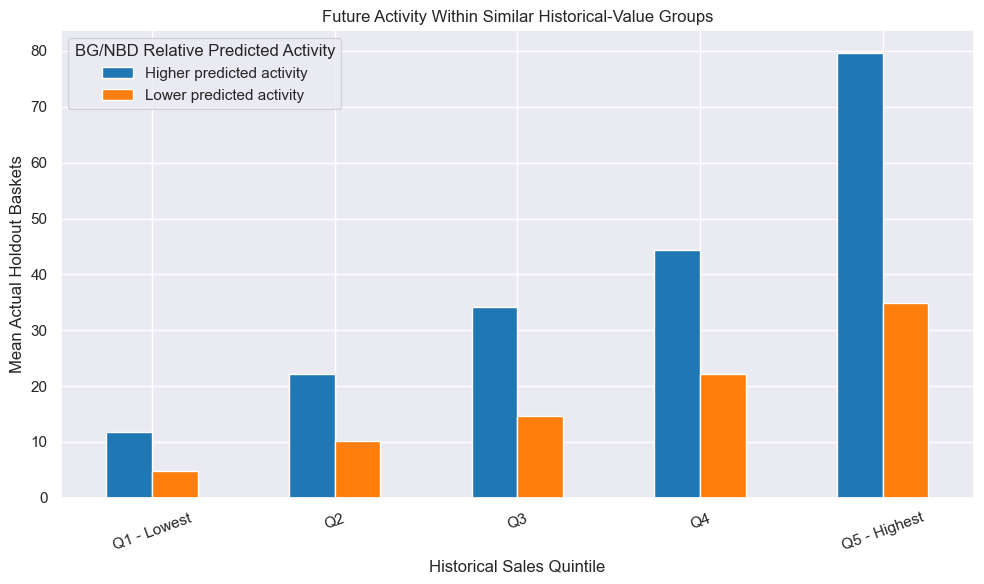

In [60]:
within_value_plot = (
    within_value_baskets_summary
    .pivot(
        index="historical_sales_quintile",
        columns="relative_predicted_baskets",
        values="actual_holdout_baskets_mean"
    )
)

within_value_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Historical Sales Quintile")
plt.ylabel("Mean Actual Holdout Baskets")

plt.title(
    "Future Activity Within Similar Historical-Value Groups"
)

plt.xticks(
    rotation=20
)

plt.legend(
    title="BG/NBD Relative predicted baskets"
)

plt.tight_layout()

plt.show()

# INTERPRETATION: 
# Within every historical-sales group, we have two bars:
    # Higher BG/NBD predicted baskets
    # Lower BG/NBD predicted baskets
# And and the height is the mean actual holdout baskets 
# (that is the real future purchase activity, not model predictions)

# Example Q3 (customers in the middle historical-sales quintile.)
    # Their historical-sales medians are reasonably similar:
        # Higher predicted activity: $1,641
        # Lower predicted activity: $1,519
    # Yet actual future basket activity is:
        # Higher predicted: 34.24 baskets
        # Lower predicted: 14.66 baskets
        # Difference:34.24−14.66=19.58 baskets
    # So the higher-predicted households subsequently made more than 
    # twice as many baskets on average.
# This shows that Two customers can have broadly similar historical retailer sales contribution, 
# yet substantially different expected and realized future purchase activity.

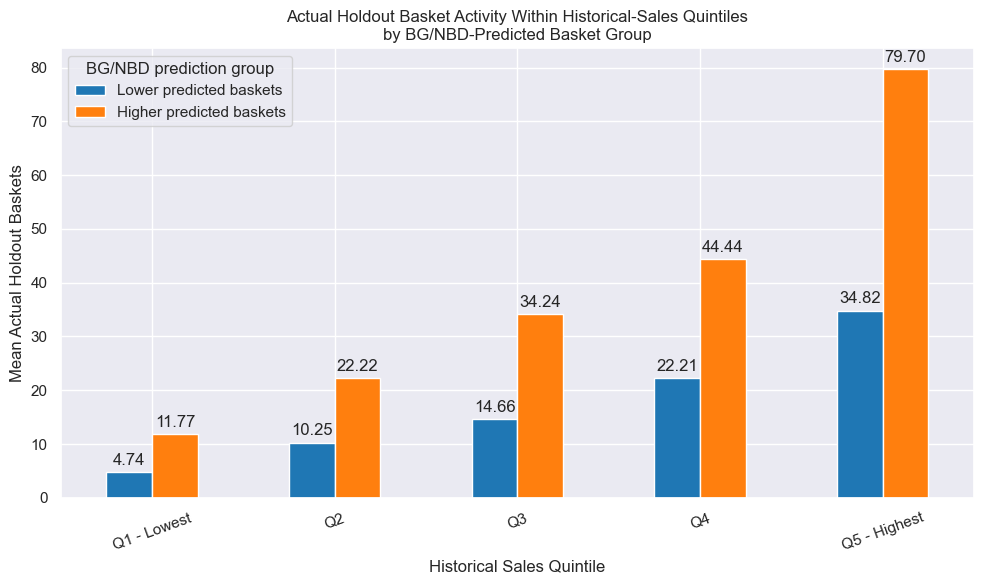

In [75]:
# =========================================================
# Plot:
# Compare ACTUAL holdout basket activity between the
# lower- and higher-BG/NBD-predicted groups within each
# historical-sales quintile.
#
# Important:
# - BG/NBD predictions DEFINE the two groups.
# - Bar heights show ACTUAL mean holdout baskets.
# =========================================================

within_sales_baskets_plot = (
    within_sales_baskets_summary
    .pivot(
        index="historical_sales_quintile",
        columns="relative_predicted_baskets",
        values="actual_holdout_baskets_mean"
    )
    .reindex(
        columns=[
            "Lower predicted baskets",
            "Higher predicted baskets"
        ]
    )
)

ax = within_sales_baskets_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Historical Sales Quintile")
ax.set_ylabel("Mean Actual Holdout Baskets")

ax.set_title(
    "Actual Holdout Basket Activity Within Historical-Sales Quintiles\n"
    "by BG/NBD-Predicted Basket Group"
)

plt.xticks(rotation=20)

ax.legend(
    title="BG/NBD prediction group",
    labels=[
        "Lower predicted baskets",
        "Higher predicted baskets"
    ]
)

# Add the ACTUAL mean holdout basket count above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [76]:
# =========================================================
# Q3 example:
# Show that households have broadly similar historical-sales
# levels, but different BG/NBD predictions and very different
# ACTUAL holdout basket activity.
# =========================================================

q3_summary = (
    within_sales_baskets_summary
    .loc[
        within_sales_baskets_summary[
            "historical_sales_quintile"
        ] == "Q3"
    ]
    .set_index("relative_predicted_baskets")
)

display(q3_summary)


## Median HISTORICAL SALES
q3_lower_sales_median = q3_summary.loc[
    "Lower predicted baskets",
    "historical_sales_median"
]

q3_higher_sales_median = q3_summary.loc[
    "Higher predicted baskets",
    "historical_sales_median"
]


# Mean ACTUAL HOLDOUT BASKETS
q3_lower_actual_baskets = q3_summary.loc[
    "Lower predicted baskets",
    "actual_holdout_baskets_mean"
]

q3_higher_actual_baskets = q3_summary.loc[
    "Higher predicted baskets",
    "actual_holdout_baskets_mean"
]


# Difference in ACTUAL holdout baskets
q3_actual_difference = (
    q3_higher_actual_baskets
    - q3_lower_actual_baskets
)

# Ratio of actual holdout activity
q3_actual_ratio = (
    q3_higher_actual_baskets
    / q3_lower_actual_baskets
)


print("Q3 — Middle Historical-Sales Quintile")
print()

print("Median HISTORICAL SALES:")
print(
    f"  Lower BG/NBD-predicted group:  "
    f"${q3_lower_sales_median:,.2f}"
)
print(
    f"  Higher BG/NBD-predicted group: "
    f"${q3_higher_sales_median:,.2f}"
)

print()

print("Mean ACTUAL HOLDOUT BASKETS:")
print(
    f"  Lower BG/NBD-predicted group:  "
    f"{q3_lower_actual_baskets:.2f}"
)
print(
    f"  Higher BG/NBD-predicted group: "
    f"{q3_higher_actual_baskets:.2f}"
)

print()

print(
    f"Difference in ACTUAL holdout baskets: "
    f"{q3_actual_difference:.2f}"
)

print(
    f"Higher-predicted group made about "
    f"{q3_actual_ratio:.2f}x as many ACTUAL holdout baskets."
)

,historical_sales_quintile,households,historical_sales_mean,historical_sales_median,predicted_baskets_mean,predicted_baskets_median,actual_holdout_baskets_mean,actual_holdout_baskets_median,share_active_in_holdout
relative_predicted_baskets,,,,,,,,,
Higher predicted baskets,Q3,250,"1,626.9804","1,640.8450",32.0886,28.2504,34.2400,30.0000,1.0000
Lower predicted baskets,Q3,250,"1,522.6162","1,518.8050",12.5604,13.0819,14.6600,13.0000,0.9840


Q3 — Middle Historical-Sales Quintile

Median HISTORICAL SALES:
  Lower BG/NBD-predicted group:  $1,518.80
  Higher BG/NBD-predicted group: $1,640.85

Mean ACTUAL HOLDOUT BASKETS:
  Lower BG/NBD-predicted group:  14.66
  Higher BG/NBD-predicted group: 34.24

Difference in ACTUAL holdout baskets: 19.58
Higher-predicted group made about 2.34x as many ACTUAL holdout baskets.


In [77]:
# INTERPRETATION:
#
# Within each historical-sales quintile, households are divided
# into two groups based on their BG/NBD-predicted future baskets:
#
#   - Lower predicted baskets
#   - Higher predicted baskets
#
# These BG/NBD predictions DEFINE the groups.
#
# The bar heights, however, show the MEAN ACTUAL number of baskets
# subsequently observed during the 167-day holdout period.
#
# Within every historical-sales quintile, the higher-predicted
# group subsequently made more actual holdout baskets than the
# lower-predicted group.
#
# Example: Q3
#
# The two groups have broadly similar historical-sales levels:
#   Lower-predicted group median historical sales:  about $1,519
#   Higher-predicted group median historical sales: about $1,641
#
# But their ACTUAL holdout basket activity differs substantially:
#   Lower-predicted group:  14.66 baskets on average
#   Higher-predicted group: 34.24 baskets on average
#   Difference:             19.58 baskets
#
# The higher-predicted group therefore made about 2.34 times
# as many actual holdout baskets as the lower-predicted group.
#
# This provides evidence that BG/NBD adds useful forward-looking
# differentiation among households with broadly similar
# historical sales.

# Create simple prioritization profiles
From the above analyses, we found that historical sales is informative, but predicted future activity provides useful additional differentiation.

So we will create a 2x2 framework, where historical_sales and predicted_holdout_baskets_bgnbd define the profiles:

<table>
  <tr>
    <th></th>
    <th colspan="2">EXPECTED FUTURE PURCHASE ACTIVITY (BASKETS)</th>
  </tr>
  <tr>
    <th></th>
    <th>Lower</th>
    <th>Higher</th>
  </tr>
  <tr>
    <th rowspan="2">HISTORICAL<br>SALES<br>VALUE</th>
    <td><strong>Higher</strong><br>Higher value /<br>Lower activity</td>
    <td><strong>Higher</strong><br>Higher value /<br>Higher activity</td>
  </tr>
  <tr>
    <td><strong>Lower</strong><br>Lower value /<br>Lower activity</td>
    <td><strong>Lower</strong><br>Lower value /<br>Higher activity</td>
  </tr>
</table>

These are relative prioritization profiles, not naturally occurring customer clusters.

In [126]:
# =========================================================
# STEP 7 — CREATE SIMPLE CUSTOMER PRIORITIZATION PROFILES
# =========================================================
#
# We use two customer-level dimensions:
#
# 1. Historical retailer sales contribution
#    = historical_sales
#
# 2. Expected future purchase activity
#    = predicted_holdout_baskets_bgnbd
#
# Median cutoffs are used because:
# - they are simple and transparent,
# - they are robust to the strongly right-skewed distributions,
# - they create relative prioritization groups without claiming
#   that there are four natural customer clusters.
# They are simply relative cutoffs for this customer population.
# =========================================================


# ---------------------------------------------------------
# 1. Calculate the global median cutoffs
# ---------------------------------------------------------

historical_value_cutoff = (
    df["historical_sales"].median()
)

future_activity_cutoff = (
    df["predicted_holdout_baskets_bgnbd"].median()
)


print(
    f"Historical sales median cutoff: "
    f"${historical_value_cutoff:,.2f}"
)

print(
    f"Predicted future activity median cutoff: "
    f"{future_activity_cutoff:.2f} baskets"
)

Historical sales median cutoff: $1,571.50
Predicted future activity median cutoff: 18.76 baskets


Households assigned to profiles: 2,498


future_activity_level,Higher predicted activity,Lower predicted activity,All
historical_value_level,,,
Higher historical value,1036,213,1249
Lower historical value,213,1036,1249
All,1249,1249,2498


,customer_profile,households,customer_share
0,Higher historical value / Higher predicted activity,"1,036",41.5%
1,Higher historical value / Lower predicted activity,213,8.5%
2,Lower historical value / Higher predicted activity,213,8.5%
3,Lower historical value / Lower predicted activity,"1,036",41.5%


Historical retailer sales median: $1,572
BG/NBD-predicted future baskets median: 18.8

Customer Profile Sizes


,Households,Share (%)
customer_profile,,
Higher sales / Higher activity,1036,41.5000
Higher sales / Lower activity,213,8.5000
Lower sales / Higher activity,213,8.5000
Lower sales / Lower activity,1036,41.5000


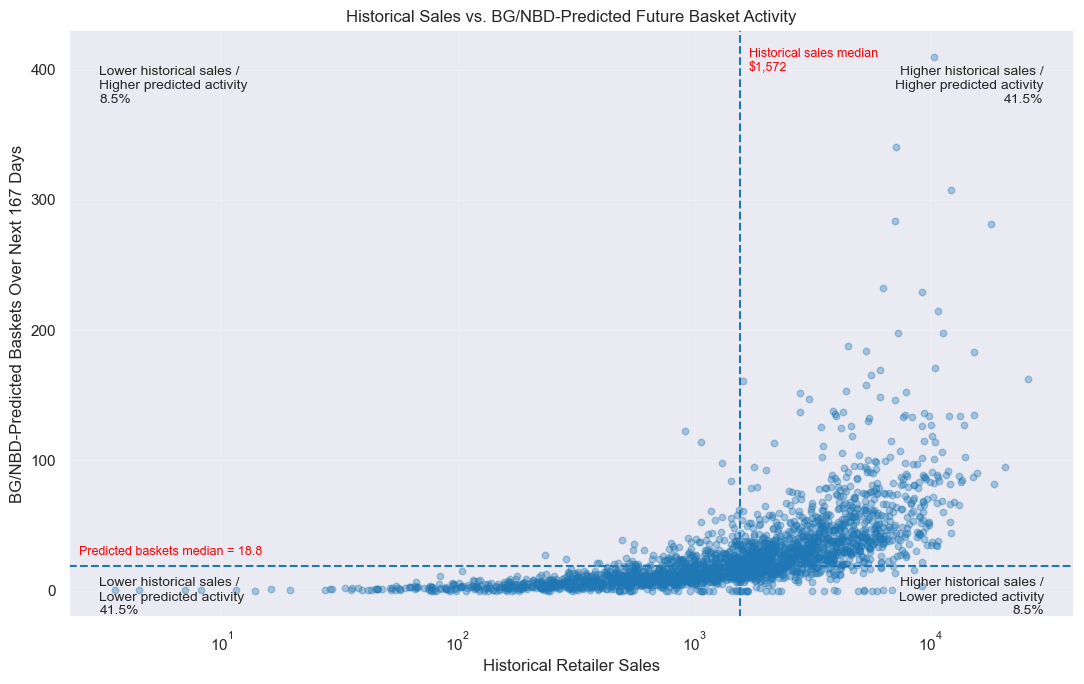

In [155]:
# ---------------------------------------------------------
# 2. Classify each household by historical contribution
# ---------------------------------------------------------

df["historical_value_level"] = np.where(
    df["historical_sales"] >= historical_value_cutoff,
    "Higher historical value",
    "Lower historical value"
)

# Higher historical value = historical sales >= customer-base median
# Lower historical value = historical sales < customer-base median
# Note that this does not mean that customers above the median are objectively 
# “high-value” in a universal sense. It means they are relatively higher-value 
# within this observed customer base.

# ---------------------------------------------------------
# 3. Classify each household by predicted future activity
# ---------------------------------------------------------

df["future_activity_level"] = np.where(
    df["predicted_holdout_baskets_bgnbd"]
    >= future_activity_cutoff,

    "Higher predicted activity",
    "Lower predicted activity"
)

# Higher predicted activity = BG/NBD expected future baskets >= median
# Lower predicted activity = BG/NBD expected future baskets < median
# Note that this is also a relative ranking

# ---------------------------------------------------------
# 4. Set logical ordering for the two dimensions
# ---------------------------------------------------------

historical_value_order = [
    "Higher historical value",
    "Lower historical value"
]

future_activity_order = [
    "Higher predicted activity",
    "Lower predicted activity"
]


df["historical_value_level"] = pd.Categorical(
    df["historical_value_level"],
    categories=historical_value_order,
    ordered=True
)

df["future_activity_level"] = pd.Categorical(
    df["future_activity_level"],
    categories=future_activity_order,
    ordered=True
)


# ---------------------------------------------------------
# 5. Combine the two dimensions into four profiles & 
# set the order
# ---------------------------------------------------------

df["customer_profile"] = (
    df["historical_value_level"].astype(str)
    + " / "
    + df["future_activity_level"].astype(str)
)

profile_order = [
    "Higher historical value / Higher predicted activity",
    "Higher historical value / Lower predicted activity",
    "Lower historical value / Higher predicted activity",
    "Lower historical value / Lower predicted activity"
]


df["customer_profile"] = pd.Categorical(
    df["customer_profile"],
    categories=profile_order,
    ordered=True
)

# ---------------------------------------------------------
# 6. Validate profile assignment
# Check that every household received exactly one profile
# ---------------------------------------------------------

assert df["customer_profile"].notna().all()

assert len(df) == 2498

print(
    f"Households assigned to profiles: "
    f"{df['customer_profile'].notna().sum():,}"
)

# ---------------------------------------------------------
# 7. Cross-tabulation of the two dimensions to 
# check the 2×2 structure
# ---------------------------------------------------------

profile_crosstab = pd.crosstab(
    df["historical_value_level"],
    df["future_activity_level"],
    margins=True
)

display(profile_crosstab)


# ---------------------------------------------------------
# 8. Profile size table
# ---------------------------------------------------------

profile_size = (
    df
    .groupby(
        "customer_profile",
        observed=True
    )
    .agg(
        households=(
            "household_key",
            "size"
        )
    )
    .reset_index()
)


profile_size["customer_share"] = (
    profile_size["households"]
    / len(df)
)


display(
    profile_size.style.format({
        "households": "{:,.0f}",
        "customer_share": "{:.1%}"
    })
)


# =========================================================
# Visualize the four customer profiles:
# Historical retailer sales × BG/NBD-predicted future activity
#
# "Higher" and "Lower" are defined relative to the
# customer-base median for each dimension.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Calculate the two median cutoffs
# ---------------------------------------------------------

historical_sales_median = (
    df["historical_sales"].median()
)

predicted_baskets_median = (
    df["predicted_holdout_baskets_bgnbd"].median()
)

print(
    f"Historical retailer sales median: "
    f"${historical_sales_median:,.0f}"
)

print(
    f"BG/NBD-predicted future baskets median: "
    f"{predicted_baskets_median:.1f}"
)


# ---------------------------------------------------------
# 2. Create the four customer profiles
#
# Historical sales:
#   Higher = at or above customer-base median
#   Lower  = below customer-base median
#
# Expected future activity:
#   Higher = at or above customer-base median
#   Lower  = below customer-base median
# ---------------------------------------------------------

df["customer_profile"] = np.select(
    [
        (
            (df["historical_sales"] >= historical_sales_median)
            &
            (
                df["predicted_holdout_baskets_bgnbd"]
                >= predicted_baskets_median
            )
        ),

        (
            (df["historical_sales"] >= historical_sales_median)
            &
            (
                df["predicted_holdout_baskets_bgnbd"]
                < predicted_baskets_median
            )
        ),

        (
            (df["historical_sales"] < historical_sales_median)
            &
            (
                df["predicted_holdout_baskets_bgnbd"]
                >= predicted_baskets_median
            )
        ),

        (
            (df["historical_sales"] < historical_sales_median)
            &
            (
                df["predicted_holdout_baskets_bgnbd"]
                < predicted_baskets_median
            )
        )
    ],

    [
        "Higher sales / Higher activity",
        "Higher sales / Lower activity",
        "Lower sales / Higher activity",
        "Lower sales / Lower activity"
    ],

    default="Unclassified"
)


# ---------------------------------------------------------
# 3. Summarize profile sizes
# ---------------------------------------------------------

profile_order = [
    "Higher sales / Higher activity",
    "Higher sales / Lower activity",
    "Lower sales / Higher activity",
    "Lower sales / Lower activity"
]

profile_summary = (
    df["customer_profile"]
    .value_counts()
    .reindex(profile_order)
    .rename("Households")
    .to_frame()
)

profile_summary["Share"] = (
    profile_summary["Households"]
    / len(df)
)

profile_summary["Share_pct"] = (
    profile_summary["Share"] * 100
)

print("\nCustomer Profile Sizes")

display(
    profile_summary[
        ["Households", "Share_pct"]
    ]
    .rename(
        columns={
            "Share_pct": "Share (%)"
        }
    )
    .round(
        {
            "Share (%)": 1
        }
    )
)


# ---------------------------------------------------------
# 4. Extract profile shares for figure annotations
# ---------------------------------------------------------

hh_share = profile_summary.loc[
    "Higher sales / Higher activity",
    "Share_pct"
]

hl_share = profile_summary.loc[
    "Higher sales / Lower activity",
    "Share_pct"
]

lh_share = profile_summary.loc[
    "Lower sales / Higher activity",
    "Share_pct"
]

ll_share = profile_summary.loc[
    "Lower sales / Lower activity",
    "Share_pct"
]


# ---------------------------------------------------------
# 5. Create scatterplot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.scatter(
    df["historical_sales"],
    df["predicted_holdout_baskets_bgnbd"],
    alpha=0.35,
    s=22
)


# ---------------------------------------------------------
# 6. Add median cutoff lines
# ---------------------------------------------------------

ax.axvline(
    historical_sales_median,
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    predicted_baskets_median,
    linestyle="--",
    linewidth=1.5
)


# ---------------------------------------------------------
# 7. Use log scale for historical sales
#
# Historical sales are strongly right-skewed, so the log scale
# makes the customer distribution easier to see.
# ---------------------------------------------------------

ax.set_xscale("log")


# ---------------------------------------------------------
# 8. Axis labels and title
# ---------------------------------------------------------

ax.set_xlabel(
    "Historical Retailer Sales"
)

ax.set_ylabel(
    "BG/NBD-Predicted Baskets Over Next 167 Days"
)

ax.set_title(
    "Historical Sales vs. BG/NBD-Predicted Future Basket Activity"
)


# ---------------------------------------------------------
# 9. Label the median cutoff lines
# ---------------------------------------------------------

ax.annotate(
    f"Historical sales median\n${historical_sales_median:,.0f}",
    xy=(
        historical_sales_median,
        0.97
    ),
    xycoords=(
        "data",
        "axes fraction"
    ),
    xytext=(6, 0),
    textcoords="offset points",
    color="red",
    ha="left",
    va="top",
    fontsize=9
)

ax.annotate(
    f"Predicted baskets median = "
    f"{predicted_baskets_median:.1f}",
    xy=(
        0.01,
        predicted_baskets_median
    ),
    xycoords=(
        "axes fraction",
        "data"
    ),
    xytext=(0, 6),
    textcoords="offset points",
    color="red",
    ha="left",
    va="bottom",
    fontsize=9
)


# ---------------------------------------------------------
# 10. Add profile labels and population shares
#
# These labels describe the four regions created by the two
# median cutoffs.
# ---------------------------------------------------------

ax.text(
    0.03,
    0.94,
    (
        "Lower historical sales /\n"
        "Higher predicted activity\n"
        f"{lh_share:.1f}%"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

ax.text(
    0.97,
    0.94,
    (
        "Higher historical sales /\n"
        "Higher predicted activity\n"
        f"{hh_share:.1f}%"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

ax.text(
    0.03,
    0.00,
    (
        "Lower historical sales /\n"
        "Lower predicted activity\n"
        f"{ll_share:.1f}%"
    ),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10
)

ax.text(
    0.97,
    0.00,
    (
        "Higher historical sales /\n"
        "Lower predicted activity\n"
        f"{hl_share:.1f}%"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10
)


# ---------------------------------------------------------
# 11. Final formatting
# ---------------------------------------------------------

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

# INTERPRETATION:
#
# The four profiles are defined using two customer-base median cutoffs:
# - Historical retailer sales median ≈ $1,572
# - BG/NBD-predicted future baskets median ≈ 18.8 baskets
#   over the next 167 days
#
# Therefore, "Higher" and "Lower" mean above or below the median
# of this customer base, not objectively high or low.
#
# Most households fall into aligned profiles:
# - 41.5% = Higher historical sales / Higher predicted activity
# - 41.5% = Lower historical sales / Lower predicted activity
#
# Together, these groups account for 83.0% of households.
# This indicates that historical sales and expected future activity
# usually point in the same direction: households with higher
# historical sales generally also have higher expected future
# basket activity, and vice versa.
#
# The remaining 17.0% are crossover households:
# - 8.5% = Higher historical sales / Lower predicted activity
# - 8.5% = Lower historical sales / Higher predicted activity
#
# These crossover households form a smaller part of the customer
# base, but they are particularly relevant because historical sales
# and the forward-looking BG/NBD prediction provide different signals.
#
# For example:
# - Higher historical sales / Lower predicted activity:
#   historically stronger retailer sales contribution, but relatively
#   weaker expected future basket activity.
#
# - Lower historical sales / Higher predicted activity:
#   historically lower retailer sales contribution, but relatively
#   stronger expected future basket activity.
#
# The exact 41.5% / 8.5% / 8.5% / 41.5% structure should not be
# interpreted as a naturally discovered segmentation. Both dimensions
# were deliberately split at their medians, so each dimension contains
# approximately 50% of households above and below its cutoff.
#
# The main takeaway is therefore:
# historical sales and expected future activity agree for most
# households, while BG/NBD provides the clearest additional
# differentiation for the 17% of crossover households.

In [151]:
print("Historical-value split:")
display(
    df["historical_value_level"]
    .value_counts()
)

print("\nFuture-activity split:")
display(
    df["future_activity_level"]
    .value_counts()
)

print("\n2x2 profile table:")
display(
    pd.crosstab(
        df["historical_value_level"],
        df["future_activity_level"],
        margins=True
    )
)

Historical-value split:


historical_value_level
Higher historical value    1249
Lower historical value     1249
Name: count, dtype: int64


Future-activity split:


future_activity_level
Higher predicted activity    1249
Lower predicted activity     1249
Name: count, dtype: int64


2x2 profile table:


future_activity_level,Higher predicted activity,Lower predicted activity,All
historical_value_level,,,
Higher historical value,1036,213,1249
Lower historical value,213,1036,1249
All,1249,1249,2498


# Quantify profile business relevance
The profile count alone doesn't tell the retailer how important a group is.
We want to know:
- What share of customers does the profile contain?
- What share of historical retailer sales did it generate?
- What share of predicted future basket activity does it represent?

## Quantify profile business relevance

In [128]:
# =========================================================
# STEP 8 — QUANTIFY PROFILE BUSINESS RELEVANCE
# =========================================================
#
# We measure profile importance using:
#
# 1. Customer share
# 2. Historical retailer-sales share
# 3. Predicted future basket-activity share
#
# Historical sales = backward-looking contribution
# Predicted baskets = forward-looking activity potential
#
# We deliberately do NOT call this profitability because
# customer-level margin / cost data is unavailable.
# =========================================================

# Build the commercial-weight table
profile_business_relevance = (
    df
    .groupby(
        "customer_profile",
        observed=True
    )
    .agg(

        # ---------------------------------------------
        # Number of households
        # ---------------------------------------------
        households=(
            "household_key",
            "size"
        ),

        # ---------------------------------------------
        # Historical retailer sales
        # ---------------------------------------------
        historical_sales_total=(
            "historical_sales",
            "sum"
        ),

        historical_sales_median=(
            "historical_sales",
            "median"
        ),

        # ---------------------------------------------
        # BG/NBD expected future activity
        # ---------------------------------------------
        predicted_future_baskets_total=(
            "predicted_holdout_baskets_bgnbd",
            "sum"
        ),

        predicted_future_baskets_median=(
            "predicted_holdout_baskets_bgnbd",
            "median"
        )
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate customer share
# ---------------------------------------------------------

profile_business_relevance[
    "customer_share"
] = (
    profile_business_relevance["households"]
    / profile_business_relevance["households"].sum()
)


# ---------------------------------------------------------
# Historical retailer-sales share
# ---------------------------------------------------------

profile_business_relevance[
    "historical_sales_share"
] = (
    profile_business_relevance["historical_sales_total"]
    / profile_business_relevance[
        "historical_sales_total"
    ].sum()
)


# ---------------------------------------------------------
# Predicted future-activity share
# ---------------------------------------------------------

profile_business_relevance[
    "predicted_future_baskets_share"
] = (
    profile_business_relevance[
        "predicted_future_baskets_total"
    ]
    / profile_business_relevance[
        "predicted_future_baskets_total"
    ].sum()
)



display(
    profile_business_relevance.style.format({

        "households": "{:,.0f}",

        "historical_sales_total":
            "${:,.0f}",

        "historical_sales_median":
            "${:,.0f}",

        "predicted_future_baskets_total":
            "{:,.1f}",

        "predicted_future_baskets_median":
            "{:,.1f}",

        "customer_share":
            "{:.1%}",

        "historical_sales_share":
            "{:.1%}",

        "predicted_future_baskets_share":
            "{:.1%}"
    })
)

,customer_profile,households,historical_sales_total,historical_sales_median,predicted_future_baskets_total,predicted_future_baskets_median,customer_share,historical_sales_share,predicted_future_baskets_share
0,Higher historical value / Higher predicted activity,"1,036","$4,469,854","$3,540","50,580.5",38.1,41.5%,75.7%,74.9%
1,Higher historical value / Lower predicted activity,213,"$547,326","$2,140","2,644.5",13.8,8.5%,9.3%,3.9%
2,Lower historical value / Higher predicted activity,213,"$240,482","$1,154","6,118.9",24.8,8.5%,4.1%,9.1%
3,Lower historical value / Lower predicted activity,"1,036","$644,210",$548,"8,225.8",7.7,41.5%,10.9%,12.2%


In [129]:
# Simplified version of profile_business_relevance
profile_commercial_weight = (
    profile_business_relevance[
        [
            "customer_profile",
            "households",
            "customer_share",
            "historical_sales_share",
            "predicted_future_baskets_share"
        ]
    ]
    .copy()
)


display(
    profile_commercial_weight.style.format({
        "households": "{:,.0f}",
        "customer_share": "{:.1%}",
        "historical_sales_share": "{:.1%}",
        "predicted_future_baskets_share": "{:.1%}"
    })
)

# INTERPRETATION: 
# we are comparing how many customers are in a group with how much historical sales and expected future activity that group represents.
# Customer share shows how large each profile is, while historical-sales
# share and predicted-basket share show how much of the retailer's
# historical sales and expected future purchase activity each profile
# represents.
#
# Higher sales / Higher activity:
# - 41.5% of households
# - 75.7% of historical sales
# - 74.9% of predicted future baskets
# This profile is disproportionately important on both dimensions:
# fewer than half of households account for roughly three quarters
# of both historical sales and expected future basket activity.
#
# Higher sales / Lower activity:
# - 8.5% of households
# - 9.3% of historical sales
# - 3.9% of predicted future baskets
# These households made a meaningful historical sales contribution,
# but their expected future purchase activity is relatively weak.
#
# Lower sales / Higher activity:
# - 8.5% of households
# - 4.1% of historical sales
# - 9.1% of predicted future baskets
# These households contributed relatively little historical sales,
# but represent a larger share of expected future basket activity.
#
# Lower sales / Lower activity:
# - 41.5% of households
# - 10.9% of historical sales
# - 12.2% of predicted future baskets
# This is a large customer group but accounts for a relatively small
# share of both historical sales and expected future activity.
#
# Overall, the table shows that combining historical sales with
# expected future activity can be useful. The two crossover profiles
# contain the same share of households, but their historical and
# forward-looking importance is quite different.



,customer_profile,households,customer_share,historical_sales_share,predicted_future_baskets_share
0,Higher historical value / Higher predicted activity,"1,036",41.5%,75.7%,74.9%
1,Higher historical value / Lower predicted activity,213,8.5%,9.3%,3.9%
2,Lower historical value / Higher predicted activity,213,8.5%,4.1%,9.1%
3,Lower historical value / Lower predicted activity,"1,036",41.5%,10.9%,12.2%


## Compare selected promotion metrics
Among households at the same historical-value level, do those with higher versus lower expected future activity show different historical promotion pattern?

Promotion measures of interest:

| Promotion mechanism          | Metric                                        | What it captures                                    | Role      |
| ---------------------------- | --------------------------------------------- | --------------------------------------------------- | --------- |
| Retail loyalty-card discount | `retail_discount_basket_rate`                 | How often discounts are received                    | Primary   |
| Retail loyalty-card discount | `retail_discount_share_of_pre_discount_value` | How large discounts are relative to purchase value  | Primary   |
| Manufacturer coupon          | `manufacturer_coupon_basket_rate`             | How often coupons are redeemed                      | Primary   |
| Manufacturer coupon          | `manufacturer_coupon_value_per_basket`        | Overall coupon value redeemed per shopping occasion | Primary   |
| Retail coupon match          | `retail_coupon_match_basket_rate`             | How often coupon matches are received               | Secondary |


In [159]:
# =========================================================
# 1. SELECT PROMOTION METRICS
# =========================================================
#
# Business question:
#
# Among households at the same broad historical-value level,
# do those with higher versus lower expected future activity
# show different historical promotion patterns?
#
# Promotion measures:
#
# Retail loyalty-card discounts:
# - How often were discounts received?
# - How large were discounts relative to estimated purchase value?
#
# Manufacturer coupons:
# - How often were coupons redeemed?
# - How much coupon value was redeemed per shopping occasion?
#
# Retail coupon matches:
# - How often were coupon matches received?
#   This is treated as a secondary measure because coupon matches
#   are relatively uncommon across the customer base.
# =========================================================


# ---------------------------------------------------------
# Primary promotion measures
# ---------------------------------------------------------

primary_promotion_metrics = [
    "retail_discount_basket_rate",
    "retail_discount_share_of_pre_discount_value",
    "manufacturer_coupon_basket_rate",
    "manufacturer_coupon_value_per_basket"
]


# ---------------------------------------------------------
# Secondary promotion measure
# ---------------------------------------------------------

secondary_promotion_metrics = [
    "retail_coupon_match_basket_rate"
]


# Combine all selected measures
selected_promotion_metrics = (
    primary_promotion_metrics
    + secondary_promotion_metrics
)


# ---------------------------------------------------------
# Readable labels for tables and charts
# ---------------------------------------------------------

promotion_metric_labels = {

    "retail_discount_basket_rate":
        "Retail discount basket rate",

    "retail_discount_share_of_pre_discount_value":
        "Retail discount share of pre-discount value",

    "manufacturer_coupon_basket_rate":
        "Manufacturer coupon basket rate",

    "manufacturer_coupon_value_per_basket":
        "Manufacturer coupon value per basket",

    "retail_coupon_match_basket_rate":
        "Retail coupon-match basket rate"
}


# ---------------------------------------------------------
# Units for the actual group-level values
# ---------------------------------------------------------

promotion_metric_value_units = {

    "retail_discount_basket_rate":
        "%",

    "retail_discount_share_of_pre_discount_value":
        "%",

    "manufacturer_coupon_basket_rate":
        "%",

    "manufacturer_coupon_value_per_basket":
        "$ per basket",

    "retail_coupon_match_basket_rate":
        "%"
}


# ---------------------------------------------------------
# Units for HIGHER minus LOWER activity differences
#
# Example:
#
# Higher activity = 8%
# Lower activity  = 5%
#
# Difference = +3 percentage points
# ---------------------------------------------------------

promotion_metric_difference_units = {

    "retail_discount_basket_rate":
        "percentage points",

    "retail_discount_share_of_pre_discount_value":
        "percentage points",

    "manufacturer_coupon_basket_rate":
        "percentage points",

    "manufacturer_coupon_value_per_basket":
        "$ per basket",

    "retail_coupon_match_basket_rate":
        "percentage points"
}

In [135]:
# =========================================================
# PROMOTION OVERVIEW ACROSS THE FOUR PROFILES
# =========================================================

profile_promotion_overview = (
    df
    .groupby(
        "customer_profile",
        observed=True
    )
    .agg(

        households=(
            "household_key",
            "size"
        ),

        retail_discount_basket_rate=(
            "retail_discount_basket_rate",
            "mean"
        ),

        retail_discount_share_of_pre_discount_value=(
            "retail_discount_share_of_pre_discount_value",
            "mean"
        ),

        manufacturer_coupon_basket_rate=(
            "manufacturer_coupon_basket_rate",
            "mean"
        ),

        manufacturer_coupon_value_per_basket=(
            "manufacturer_coupon_value_per_basket",
            "mean"
        ),

        retail_coupon_match_basket_rate=(
            "retail_coupon_match_basket_rate",
            "mean"
        )
    )
    .reset_index()
)


display(
    profile_promotion_overview.style.format({

        "households":
            "{:,.0f}",

        "retail_discount_basket_rate":
            "{:.1%}",

        "retail_discount_share_of_pre_discount_value":
            "{:.1%}",

        "manufacturer_coupon_basket_rate":
            "{:.1%}",

        "manufacturer_coupon_value_per_basket":
            "${:.3f}",

        "retail_coupon_match_basket_rate":
            "{:.1%}"
    })
)

,customer_profile,households,retail_discount_basket_rate,retail_discount_share_of_pre_discount_value,manufacturer_coupon_basket_rate,manufacturer_coupon_value_per_basket,retail_coupon_match_basket_rate
0,Higher historical value / Higher predicted activity,"1,036",85.7%,14.9%,7.0%,$0.180,3.5%
1,Higher historical value / Lower predicted activity,213,89.4%,15.4%,9.0%,$0.258,4.5%
2,Lower historical value / Higher predicted activity,213,78.4%,16.2%,3.8%,$0.068,1.6%
3,Lower historical value / Lower predicted activity,"1,036",82.9%,15.8%,4.2%,$0.089,1.7%


## Overall customer-base benchmarks

In [161]:
# =========================================================
# 3. CUSTOMER-BASE REFERENCE VALUES
# =========================================================
#
# IMPORTANT:
# These are means of CUSTOMER-LEVEL measures.
#
# Every household receives equal weight in these averages,
# regardless of how many baskets it made.
#
# Example:
#
# retail_discount_basket_rate = 0.842
#
# means:
# The average household received a retail loyalty-card discount
# on about 84.2% of its baskets.
#
# It does NOT necessarily mean that 84.2% of every basket in the
# complete transaction dataset contained a retail discount.
# =========================================================


overall_promotion_benchmark = (
    df[selected_promotion_metrics]
    .mean()
)


# ---------------------------------------------------------
# Create a readable benchmark table
# ---------------------------------------------------------

overall_promotion_benchmark_table = pd.DataFrame({

    "metric_column":
        selected_promotion_metrics,

    "metric":
        [
            promotion_metric_labels[m]
            for m in selected_promotion_metrics
        ],

    "customer_base_mean":
        [
            overall_promotion_benchmark[m]
            for m in selected_promotion_metrics
        ],

    "unit":
        [
            promotion_metric_value_units[m]
            for m in selected_promotion_metrics
        ]
})


# ---------------------------------------------------------
# Create a presentation version
# ---------------------------------------------------------

overall_promotion_benchmark_display = (
    overall_promotion_benchmark_table
    .copy()
)


for idx, row in overall_promotion_benchmark_display.iterrows():

    if row["unit"] == "%":

        overall_promotion_benchmark_display.loc[
            idx,
            "customer_base_mean"
        ] = (
            row["customer_base_mean"] * 100
        )


display(
    overall_promotion_benchmark_display[
        [
            "metric",
            "customer_base_mean",
            "unit"
        ]
    ]
    .round(3)
)


# CUSTOMER-BASE REFERENCE POINTS:
#
# These are means of customer-level promotion measures, so every
# household receives equal weight regardless of shopping frequency.
#
# - Retail discount basket rate = 84.2%
#   The average household received a retailer loyalty-card discount
#   on about 84% of its baskets.
#
# - Retail discount share of estimated pre-discount value = 15.4%
#   For the average household, retailer loyalty-card discounts were
#   equivalent to about 15% of estimated pre-retailer-discount value.
#
# - Manufacturer coupon basket rate = 5.7%
#   The average household redeemed a manufacturer coupon on about
#   6% of its baskets. The lower median (2.9%) indicates substantial
#   right-skew and heavier redemption among a smaller subset.
#
# - Manufacturer coupon value per basket = $0.14
#   The average household redeemed about $0.14 of manufacturer
#   coupon value per basket across all baskets. The median is only
#   about $0.04, again showing strong concentration among heavier
#   coupon users.
#
# - Retail coupon-match basket rate = 2.7%
#   The average household received a retailer coupon match on about
#   3% of its baskets. Since the median is zero, this mechanism is
#   concentrated among a relatively small subset of households.
#
# These values provide customer-base reference points for the later
# comparison of promotion behaviour across customer profiles.



,metric,customer_base_mean,unit
0,Retail discount basket rate,84.2220,%
1,Retail discount share of pre-discount value,15.4430,%
2,Manufacturer coupon basket rate,5.7120,%
3,Manufacturer coupon value per basket,0.1390,$ per basket
4,Retail coupon-match basket rate,2.6720,%


In [162]:
# =========================================================
# 4. PROMOTION OVERVIEW ACROSS THE FOUR PROFILES
# =========================================================
#
# This table provides the full descriptive picture before we
# make the more focused within-historical-value comparisons.
#
# Each value is the mean of the customer-level measure among
# households belonging to that profile.
# =========================================================


profile_promotion_overview = (
    df
    .groupby(
        [
            "historical_value_level",
            "future_activity_level"
        ],
        observed=True
    )
    .agg(

        households=(
            "household_key",
            "size"
        ),

        retail_discount_basket_rate=(
            "retail_discount_basket_rate",
            "mean"
        ),

        retail_discount_share_of_pre_discount_value=(
            "retail_discount_share_of_pre_discount_value",
            "mean"
        ),

        manufacturer_coupon_basket_rate=(
            "manufacturer_coupon_basket_rate",
            "mean"
        ),

        manufacturer_coupon_value_per_basket=(
            "manufacturer_coupon_value_per_basket",
            "mean"
        ),

        retail_coupon_match_basket_rate=(
            "retail_coupon_match_basket_rate",
            "mean"
        )
    )
    .reset_index()
)


# ---------------------------------------------------------
# Set meaningful display order
# ---------------------------------------------------------

profile_promotion_overview[
    "historical_value_level"
] = pd.Categorical(
    profile_promotion_overview[
        "historical_value_level"
    ],
    categories=historical_value_order,
    ordered=True
)


profile_promotion_overview[
    "future_activity_level"
] = pd.Categorical(
    profile_promotion_overview[
        "future_activity_level"
    ],
    categories=future_activity_order,
    ordered=True
)


profile_promotion_overview = (
    profile_promotion_overview
    .sort_values(
        [
            "historical_value_level",
            "future_activity_level"
        ]
    )
)


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

display(
    profile_promotion_overview.style.format({

        "households":
            "{:,.0f}",

        "retail_discount_basket_rate":
            "{:.1%}",

        "retail_discount_share_of_pre_discount_value":
            "{:.1%}",

        "manufacturer_coupon_basket_rate":
            "{:.1%}",

        "manufacturer_coupon_value_per_basket":
            "${:.3f}",

        "retail_coupon_match_basket_rate":
            "{:.1%}"
    })
)

,historical_value_level,future_activity_level,households,retail_discount_basket_rate,retail_discount_share_of_pre_discount_value,manufacturer_coupon_basket_rate,manufacturer_coupon_value_per_basket,retail_coupon_match_basket_rate
0,Higher historical value,Higher predicted activity,"1,036",85.7%,14.9%,7.0%,$0.180,3.5%
1,Higher historical value,Lower predicted activity,213,89.4%,15.4%,9.0%,$0.258,4.5%
2,Lower historical value,Higher predicted activity,213,78.4%,16.2%,3.8%,$0.068,1.6%
3,Lower historical value,Lower predicted activity,"1,036",82.9%,15.8%,4.2%,$0.089,1.7%


## The main analysis: compare higher vs lower future activity within historical-value level

In [163]:

# =========================================================
# WITHIN-HISTORICAL-VALUE PROMOTION COMPARISON
# =========================================================
# Question:
# Among households in the same broad historical-sales level,
# how does promotion pattern differ between those with
# higher versus lower predicted future activity?
#
# For each historical-sales level, compare:
#   Higher predicted activity
#   versus
#   Lower predicted activity
#
# For each promotion measure:
# Difference =
# Mean for higher predicted activity -  Mean for lower predicted activity
#
# Positive difference:
# Higher-predicted-activity households show more of the
# promotion measure.
#
# Negative difference:
# Higher-predicted-activity households show less of the
# promotion measure.
#
# Difference near zero:
# Promotion behaviour is similar between the two activity
# groups within that historical-sales level.
#
# IMPORTANT:
# This is a descriptive comparison within broad historical-sales
# groups. It does not establish that promotion behaviour causes
# higher or lower future activity.
# =========================================================


comparison_rows = []


for historical_level in historical_value_order:

    # -----------------------------------------------------
    # Keep households from one historical-value level
    # -----------------------------------------------------

    subset = df.loc[
        df["historical_value_level"]
        == historical_level
    ]


    # -----------------------------------------------------
    # Actual number of households in each activity group
    # -----------------------------------------------------

    higher_activity_households = (
        subset[
            "future_activity_level"
        ]
        .eq("Higher predicted activity")
        .sum()
    )

    lower_activity_households = (
        subset[
            "future_activity_level"
        ]
        .eq("Lower predicted activity")
        .sum()
    )


    # -----------------------------------------------------
    # Compare each selected promotion measure
    # -----------------------------------------------------

    for metric in selected_promotion_metrics:

        higher_future = (
            subset.loc[
                subset["future_activity_level"]
                == "Higher predicted activity",
                metric
            ]
            .dropna()
        )


        lower_future = (
            subset.loc[
                subset["future_activity_level"]
                == "Lower predicted activity",
                metric
            ]
            .dropna()
        )


        # -------------------------------------------------
        # Scale rate/share variables from proportions
        # into percentage values.
        #
        # Example:
        # 0.057 -> 5.7
        #
        # Dollar-per-basket measure stays in dollars.
        # -------------------------------------------------

        if promotion_metric_value_units[metric] == "%":
            scale = 100
        else:
            scale = 1


        higher_mean = (
            higher_future.mean()
            * scale
        )

        lower_mean = (
            lower_future.mean()
            * scale
        )

        higher_median = (
            higher_future.median()
            * scale
        )

        lower_median = (
            lower_future.median()
            * scale
        )


        # -------------------------------------------------
        # Higher predicted activity
        # minus
        # Lower predicted activity
        # -------------------------------------------------

        difference = (
            higher_mean
            - lower_mean
        )


        comparison_rows.append({

            "historical_value_level":
                historical_level,

            "metric_column":
                metric,

            "metric":
                promotion_metric_labels[metric],

            "priority":
                (
                    "Primary"
                    if metric in primary_promotion_metrics
                    else "Secondary"
                ),

            # Actual profile sizes
            "higher_activity_households":
                higher_activity_households,

            "lower_activity_households":
                lower_activity_households,

            # Number of non-missing observations used
            # for this particular metric
            "higher_activity_metric_n":
                len(higher_future),

            "lower_activity_metric_n":
                len(lower_future),

            # Customer-level mean
            "higher_activity_mean":
                higher_mean,

            "lower_activity_mean":
                lower_mean,

            # Main comparison
            "difference_high_minus_low":
                difference,

            # Supporting distribution information
            "higher_activity_median":
                higher_median,

            "lower_activity_median":
                lower_median,

            # Units
            "value_unit":
                promotion_metric_value_units[metric],

            "difference_unit":
                promotion_metric_difference_units[metric]
        })


# ---------------------------------------------------------
# Final comparison dataframe
# ---------------------------------------------------------

within_value_promotion_comparison = pd.DataFrame(
    comparison_rows
)


display(
    within_value_promotion_comparison
)


,historical_value_level,metric_column,metric,priority,higher_activity_households,lower_activity_households,higher_activity_metric_n,lower_activity_metric_n,higher_activity_mean,lower_activity_mean,difference_high_minus_low,higher_activity_median,lower_activity_median,value_unit,difference_unit
0,Higher historical value,retail_discount_basket_rate,Retail discount basket rate,Primary,1036,213,1036,213,85.6612,89.3701,-3.7090,87.0707,90.6977,%,percentage points
1,Higher historical value,retail_discount_share_of_pre_discount_value,Retail discount share of pre-discount value,Primary,1036,213,1036,213,14.9403,15.4326,-0.4923,14.3629,15.1664,%,percentage points
2,Higher historical value,manufacturer_coupon_basket_rate,Manufacturer coupon basket rate,Primary,1036,213,1036,213,6.9929,8.9527,-1.9598,4.0514,5.7692,%,percentage points
3,Higher historical value,manufacturer_coupon_value_per_basket,Manufacturer coupon value per basket,Primary,1036,213,1036,213,0.1804,0.2584,-0.0779,0.0662,0.0919,$ per basket,$ per basket
4,Higher historical value,retail_coupon_match_basket_rate,Retail coupon-match basket rate,Secondary,1036,213,1036,213,3.5094,4.5274,-1.0180,1.2423,2.0408,%,percentage points
5,Lower historical value,retail_discount_basket_rate,Retail discount basket rate,Primary,213,1036,213,1036,78.3862,82.9238,-4.5376,80.0000,85.7143,%,percentage points
6,Lower historical value,retail_discount_share_of_pre_discount_value,Retail discount share of pre-discount value,Primary,213,1036,213,1036,16.1870,15.7940,0.3930,15.9479,15.2307,%,percentage points
7,Lower historical value,manufacturer_coupon_basket_rate,Manufacturer coupon basket rate,Primary,213,1036,213,1036,3.8074,4.1563,-0.3489,1.6949,0.0000,%,percentage points
8,Lower historical value,manufacturer_coupon_value_per_basket,Manufacturer coupon value per basket,Primary,213,1036,213,1036,0.0681,0.0888,-0.0207,0.0225,0.0000,$ per basket,$ per basket
9,Lower historical value,retail_coupon_match_basket_rate,Retail coupon-match basket rate,Secondary,213,1036,213,1036,1.6154,1.6706,-0.0552,0.0000,0.0000,%,percentage points


### Create clean primary and secondary comparison tables

In [165]:
# =========================================================
# PRIMARY PROMOTION COMPARISONS
# =========================================================


primary_within_value_comparison = (
    within_value_promotion_comparison
    .loc[
        within_value_promotion_comparison[
            "priority"
        ] == "Primary"
    ]
    .copy()
)


display(
    primary_within_value_comparison[
        [
            "historical_value_level",
            "metric",
            "higher_activity_households",
            "lower_activity_households",
            "higher_activity_mean",
            "lower_activity_mean",
            "difference_high_minus_low",
            "value_unit",
            "difference_unit"
        ]
    ]
    .round(3)
)


# For each promotion measure:
# Difference =
# Mean for higher predicted activity -  Mean for lower predicted activity
#
# Positive difference:
# Higher-predicted-activity households show more of the
# promotion measure.
#
# Negative difference:
# Higher-predicted-activity households show less of the
# promotion measure.
#
# Difference near zero:
# Promotion behaviour is similar between the two activity
# groups within that historical-sales level.
#
# IMPORTANT:
# This is a descriptive comparison within broad historical-sales
# groups. It does not establish that promotion behaviour causes
# higher or lower future activity.

,historical_value_level,metric,higher_activity_households,lower_activity_households,higher_activity_mean,lower_activity_mean,difference_high_minus_low,value_unit,difference_unit
0,Higher historical value,Retail discount basket rate,1036,213,85.6610,89.3700,-3.7090,%,percentage points
1,Higher historical value,Retail discount share of pre-discount value,1036,213,14.9400,15.4330,-0.4920,%,percentage points
2,Higher historical value,Manufacturer coupon basket rate,1036,213,6.9930,8.9530,-1.9600,%,percentage points
3,Higher historical value,Manufacturer coupon value per basket,1036,213,0.1800,0.2580,-0.0780,$ per basket,$ per basket
5,Lower historical value,Retail discount basket rate,213,1036,78.3860,82.9240,-4.5380,%,percentage points
6,Lower historical value,Retail discount share of pre-discount value,213,1036,16.1870,15.7940,0.3930,%,percentage points
7,Lower historical value,Manufacturer coupon basket rate,213,1036,3.8070,4.1560,-0.3490,%,percentage points
8,Lower historical value,Manufacturer coupon value per basket,213,1036,0.0680,0.0890,-0.0210,$ per basket,$ per basket


In [166]:
# =========================================================
# SECONDARY COUPON-MATCH COMPARISON
# =========================================================


secondary_within_value_comparison = (
    within_value_promotion_comparison
    .loc[
        within_value_promotion_comparison[
            "priority"
        ] == "Secondary"
    ]
    .copy()
)


display(
    secondary_within_value_comparison[
        [
            "historical_value_level",
            "metric",
            "higher_activity_households",
            "lower_activity_households",
            "higher_activity_mean",
            "lower_activity_mean",
            "difference_high_minus_low",
            "value_unit",
            "difference_unit"
        ]
    ]
    .round(3)
)

,historical_value_level,metric,higher_activity_households,lower_activity_households,higher_activity_mean,lower_activity_mean,difference_high_minus_low,value_unit,difference_unit
4,Higher historical value,Retail coupon-match basket rate,1036,213,3.5090,4.5270,-1.0180,%,percentage points
9,Lower historical value,Retail coupon-match basket rate,213,1036,1.6150,1.6710,-0.0550,%,percentage points


### Pattern among higher-historical-value customers and lower-historical-value customers

In [175]:
# =========================================================
# HIGHER HISTORICAL VALUE:
# HIGHER VS LOWER EXPECTED FUTURE ACTIVITY
# =========================================================


higher_value_promotion_comparison = (
    within_value_promotion_comparison
    .loc[
        within_value_promotion_comparison[
            "historical_value_level"
        ] == "Higher historical value"
    ]
    [
        [
            "metric",
            "priority",
            "higher_activity_mean",
            "lower_activity_mean",
            "difference_high_minus_low",
            "value_unit",
            "difference_unit"
        ]
    ]
    .copy()
)

print("Pattern among higher-historical-value customers: ")
display(
    higher_value_promotion_comparison
    .round(3)
)


# =========================================================
# 8. LOWER HISTORICAL VALUE:
# HIGHER VS LOWER EXPECTED FUTURE ACTIVITY
# =========================================================


lower_value_promotion_comparison = (
    within_value_promotion_comparison
    .loc[
        within_value_promotion_comparison[
            "historical_value_level"
        ] == "Lower historical value"
    ]
    [
        [
            "metric",
            "priority",
            "higher_activity_mean",
            "lower_activity_mean",
            "difference_high_minus_low",
            "value_unit",
            "difference_unit"
        ]
    ]
    .copy()
)

print("Pattern among lower-historical-value customers: ")
display(
    lower_value_promotion_comparison
    .round(3)
)


# OVERALL INTERPRETATION:
# The clearest promotion pattern appears among higher-historical-sales
# households. Across all selected measures, households with lower
# predicted future activity showed somewhat greater historical promotion
# receipt/redemption than households with higher predicted activity.
#
# Among lower-historical-sales households, the pattern is a bit mixed.
# Higher-predicted-activity households received retailer loyalty-card
# discounts on a smaller share of baskets, but their discount value
# relative to estimated purchase value was slightly higher.
# Manufacturer-coupon and coupon-match differences were comparatively small.
#
# Overall, historical promotion behaviour differs more clearly by expected
# future activity among higher-historical-sales households than among
# lower-historical-sales households.
#
# These are descriptive associations only. They do not show that greater
# promotion usage causes lower future activity.


# LIMITATION:
#
# The within-historical-sales comparisons use broad median-based
# Higher/Lower historical-sales groups.
#
# Households within the same group can still differ substantially
# in their actual historical sales. For example, among households
# classified as Higher historical sales, the Higher-predicted-activity
# profile has a higher median historical sales level than the
# Lower-predicted-activity profile.
#
# Therefore, these comparisons do not hold historical sales constant.
# Some observed promotion differences may partly reflect remaining
# differences in historical sales within each broad group.
#
# The results should therefore be interpreted descriptively:
# within the same broad historical-sales level, future-activity
# profiles show different observed historical promotion patterns.
#
# A tighter within-historical-sales-quintile comparison or regression
# controlling for historical sales could be considered as future work.

Pattern among higher-historical-value customers: 


,metric,priority,higher_activity_mean,lower_activity_mean,difference_high_minus_low,value_unit,difference_unit
0,Retail discount basket rate,Primary,85.6610,89.3700,-3.7090,%,percentage points
1,Retail discount share of pre-discount value,Primary,14.9400,15.4330,-0.4920,%,percentage points
2,Manufacturer coupon basket rate,Primary,6.9930,8.9530,-1.9600,%,percentage points
3,Manufacturer coupon value per basket,Primary,0.1800,0.2580,-0.0780,$ per basket,$ per basket
4,Retail coupon-match basket rate,Secondary,3.5090,4.5270,-1.0180,%,percentage points


Pattern among lower-historical-value customers: 


,metric,priority,higher_activity_mean,lower_activity_mean,difference_high_minus_low,value_unit,difference_unit
5,Retail discount basket rate,Primary,78.3860,82.9240,-4.5380,%,percentage points
6,Retail discount share of pre-discount value,Primary,16.1870,15.7940,0.3930,%,percentage points
7,Manufacturer coupon basket rate,Primary,3.8070,4.1560,-0.3490,%,percentage points
8,Manufacturer coupon value per basket,Primary,0.0680,0.0890,-0.0210,$ per basket,$ per basket
9,Retail coupon-match basket rate,Secondary,1.6150,1.6710,-0.0550,%,percentage points


### Pattern among lower-historical-value customers

,metric,priority,higher_activity_mean,lower_activity_mean,difference_high_minus_low,value_unit,difference_unit
5,Retail discount basket rate,Primary,78.3860,82.9240,-4.5380,%,percentage points
6,Retail discount share of pre-discount value,Primary,16.1870,15.7940,0.3930,%,percentage points
7,Manufacturer coupon basket rate,Primary,3.8070,4.1560,-0.3490,%,percentage points
8,Manufacturer coupon value per basket,Primary,0.0680,0.0890,-0.0210,$ per basket,$ per basket
9,Retail coupon-match basket rate,Secondary,1.6150,1.6710,-0.0550,%,percentage points


In [173]:
# =========================================================
# SUPPORTING CHECK:
# MEAN VS MEDIAN FOR MANUFACTURER-COUPON MEASURES
# =========================================================


manufacturer_coupon_distribution_check = (
    within_value_promotion_comparison
    .loc[
        within_value_promotion_comparison[
            "metric_column"
        ].isin([
            "manufacturer_coupon_basket_rate",
            "manufacturer_coupon_value_per_basket"
        ])
    ]
    [
        [
            "historical_value_level",
            "metric",
            "higher_activity_mean",
            "higher_activity_median",
            "lower_activity_mean",
            "lower_activity_median",
            "difference_high_minus_low",
            "value_unit"
        ]
    ]
    .copy()
)


display(
    manufacturer_coupon_distribution_check
    .round(3)
)

,historical_value_level,metric,higher_activity_mean,higher_activity_median,lower_activity_mean,lower_activity_median,difference_high_minus_low,value_unit
2,Higher historical value,Manufacturer coupon basket rate,6.9930,4.0510,8.9530,5.7690,-1.9600,%
3,Higher historical value,Manufacturer coupon value per basket,0.1800,0.0660,0.2580,0.0920,-0.0780,$ per basket
7,Lower historical value,Manufacturer coupon basket rate,3.8070,1.6950,4.1560,0.0000,-0.3490,%
8,Lower historical value,Manufacturer coupon value per basket,0.0680,0.0220,0.0890,0.0000,-0.0210,$ per basket


In [172]:
# =========================================================
# CHECK HISTORICAL SALES WITHIN EACH COMPARISON
# =========================================================
#
# Households are grouped into broad Higher/Lower historical-value
# categories. They are NOT exactly matched on historical sales.
#
# This table helps us see how historical sales still differ between
# Higher- and Lower-predicted-activity households within each broad
# historical-value level.
# =========================================================


historical_sales_within_group_check = (
    df
    .groupby(
        [
            "historical_value_level",
            "future_activity_level"
        ],
        observed=True
    )
    .agg(

        households=(
            "household_key",
            "size"
        ),

        historical_sales_mean=(
            "historical_sales",
            "mean"
        ),

        historical_sales_median=(
            "historical_sales",
            "median"
        )
    )
    .reset_index()
)


display(
    historical_sales_within_group_check.style.format({

        "households":
            "{:,.0f}",

        "historical_sales_mean":
            "${:,.0f}",

        "historical_sales_median":
            "${:,.0f}"
    })
)

,historical_value_level,future_activity_level,households,historical_sales_mean,historical_sales_median
0,Higher historical value,Higher predicted activity,"1,036","$4,315","$3,540"
1,Higher historical value,Lower predicted activity,213,"$2,570","$2,140"
2,Lower historical value,Higher predicted activity,213,"$1,129","$1,154"
3,Lower historical value,Lower predicted activity,"1,036",$622,$548


# Figures & Charts

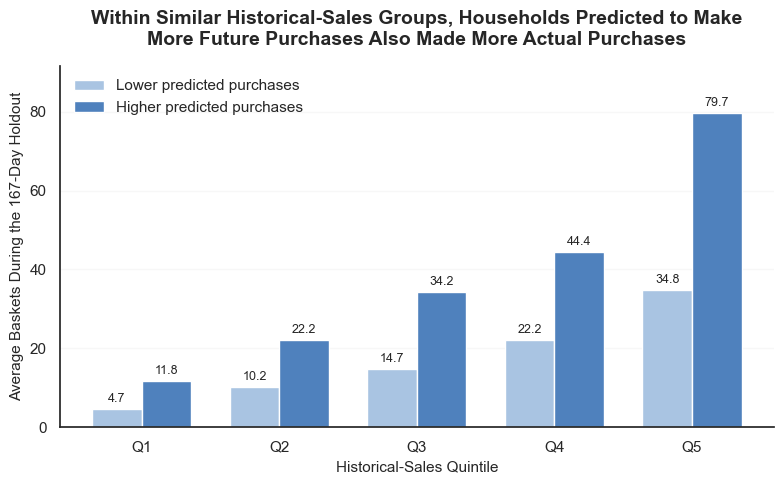

In [196]:

# =========================================================
# Actual future baskets by historical-sales quintile
# and BG/NBD-predicted activity group
# =========================================================


chart_data = pd.DataFrame({
    "Historical-sales quintile": ["Q1", "Q2", "Q3", "Q4", "Q5"],
    "Lower predicted purchases": [4.74, 10.25, 14.66, 22.21, 34.82],
    "Higher predicted purchases": [11.77, 22.22, 34.24, 44.44, 79.70]
})


# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------

higher_color = "#4F81BD"
lower_color = "#A9C4E2"


# ---------------------------------------------------------
# Set up positions
# ---------------------------------------------------------

x = np.arange(len(chart_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))


# ---------------------------------------------------------
# Plot grouped bars
# ---------------------------------------------------------

bars_lower = ax.bar(
    x - bar_width / 2,
    chart_data["Lower predicted purchases"],
    width=bar_width,
    label="Lower predicted purchases",
    color=lower_color
)

bars_higher = ax.bar(
    x + bar_width / 2,
    chart_data["Higher predicted purchases"],
    width=bar_width,
    label="Higher predicted purchases",
    color=higher_color
)


# ---------------------------------------------------------
# Add value labels
# ---------------------------------------------------------

for bars in [bars_lower, bars_higher]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


# ---------------------------------------------------------
# Title and axis labels
# ---------------------------------------------------------

ax.set_title(
    "Within Similar Historical-Sales Groups, Households Predicted to Make\n"
    "More Future Purchases Also Made More Actual Purchases",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Historical-Sales Quintile",
    fontsize=11
)

ax.set_ylabel(
    "Average Baskets During the 167-Day Holdout",
    fontsize=11
)

ax.set_xticks(x)
ax.set_xticklabels(
    chart_data["Historical-sales quintile"]
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

ax.legend(
    frameon=False,
    loc="upper left"
)


# ---------------------------------------------------------
# Clean formatting
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.15
)

ax.set_axisbelow(True)

ax.set_ylim(
    0,
    chart_data["Higher predicted purchases"].max() * 1.15
)


plt.tight_layout()
plt.show()

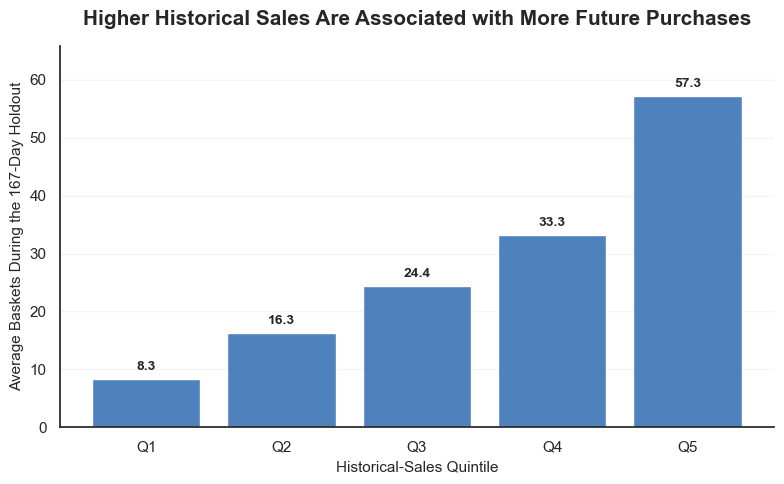

In [197]:

# =========================================================
# ACTUAL FUTURE BASKETS BY HISTORICAL-SALES QUINTILE
# =========================================================

historical_sales_quintile_data = pd.DataFrame({
    "historical_sales_quintile": ["Q1", "Q2", "Q3", "Q4", "Q5"],
    "mean_actual_holdout_baskets": [8.3, 16.3, 24.4, 33.3, 57.3]
})


fig, ax = plt.subplots(figsize=(8, 5))


# ---------------------------------------------------------
# Plot bars
# ---------------------------------------------------------

bars = ax.bar(
    historical_sales_quintile_data["historical_sales_quintile"],
    historical_sales_quintile_data["mean_actual_holdout_baskets"],
    color="#4F81BD"
)


# ---------------------------------------------------------
# Add values above each bar
# ---------------------------------------------------------

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# ---------------------------------------------------------
# Titles and labels
# ---------------------------------------------------------

ax.set_title(
    "Higher Historical Sales Are Associated with More Future Purchases",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Historical-Sales Quintile",
    fontsize=11
)

ax.set_ylabel(
    "Average Baskets During the 167-Day Holdout",
    fontsize=11
)


# ---------------------------------------------------------
# Clean formatting
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.set_axisbelow(True)

ax.set_ylim(
    0,
    historical_sales_quintile_data[
        "mean_actual_holdout_baskets"
    ].max() * 1.15
)


plt.tight_layout()
plt.show()

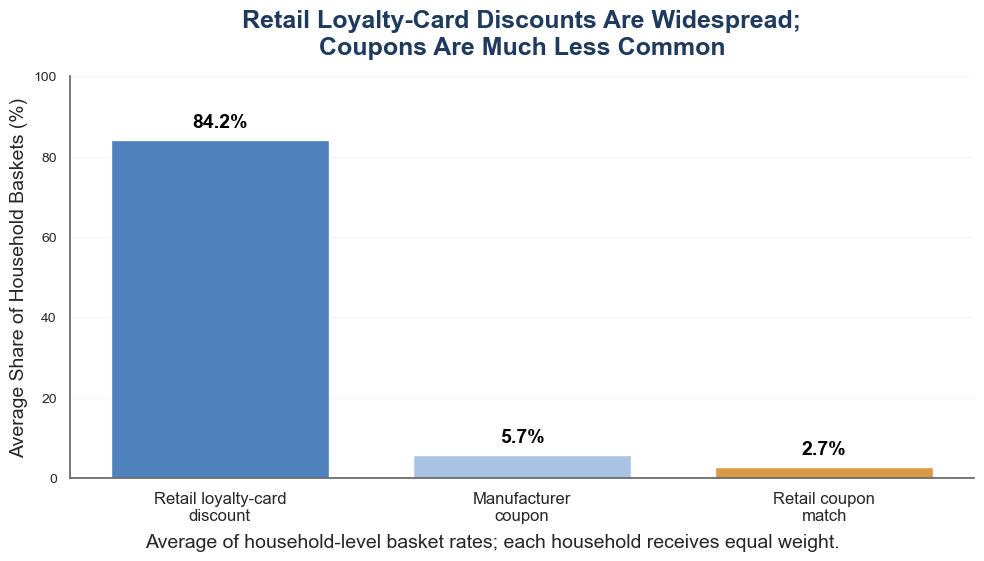

In [206]:
# =========================================================
# Customer-base promotion frequency
#
# Values are MEANS OF CUSTOMER-LEVEL basket rates:
# each household receives equal weight.
# =========================================================

promotion_labels = [
    "Retail loyalty-card\ndiscount",
    "Manufacturer\ncoupon",
    "Retail coupon\nmatch"
]

promotion_rates = [
    84.2,
    5.7,
    2.7
]


# ---------------------------------------------------------
# Colors consistent with previous slides
# ---------------------------------------------------------

navy = "#1F3A5F"
main_blue = "#4F81BD"
light_blue = "#A9C4E2"
warm_orange = "#D99A44"

bar_colors = [
    main_blue,
    light_blue,
    warm_orange
]


# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.5))


# ---------------------------------------------------------
# Plot bars
# ---------------------------------------------------------

bars = ax.bar(
    promotion_labels,
    promotion_rates,
    color=bar_colors,
    width=0.72
)


# ---------------------------------------------------------
# Add value labels
# ---------------------------------------------------------

for bar, value in zip(bars, promotion_rates):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="black"
    )


# ---------------------------------------------------------
# Title and axis labels
# ---------------------------------------------------------

ax.set_title(
    "Retail Loyalty-Card Discounts Are Widespread;\n"
    "Coupons Are Much Less Common",
    fontsize=18,
    fontweight="bold",
    color=navy,
    pad=16
)

ax.set_ylabel(
    "Average Share of Household Baskets (%)",
    fontsize=14
)


# ---------------------------------------------------------
# Y-axis
# ---------------------------------------------------------

ax.set_ylim(0, 100)

ax.set_yticks(
    range(0, 101, 20)
)


# ---------------------------------------------------------
# Clean formatting
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

ax.grid(
    axis="y",
    alpha=0.15
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="x",
    labelsize=12
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# ---------------------------------------------------------
# Optional explanatory note
# ---------------------------------------------------------

fig.text(
    0.5,
    -0.01,
    "Average of household-level basket rates; each household receives equal weight.",
    ha="center",
    fontsize=14,
    # color="#666666"
)


plt.tight_layout()
plt.show()

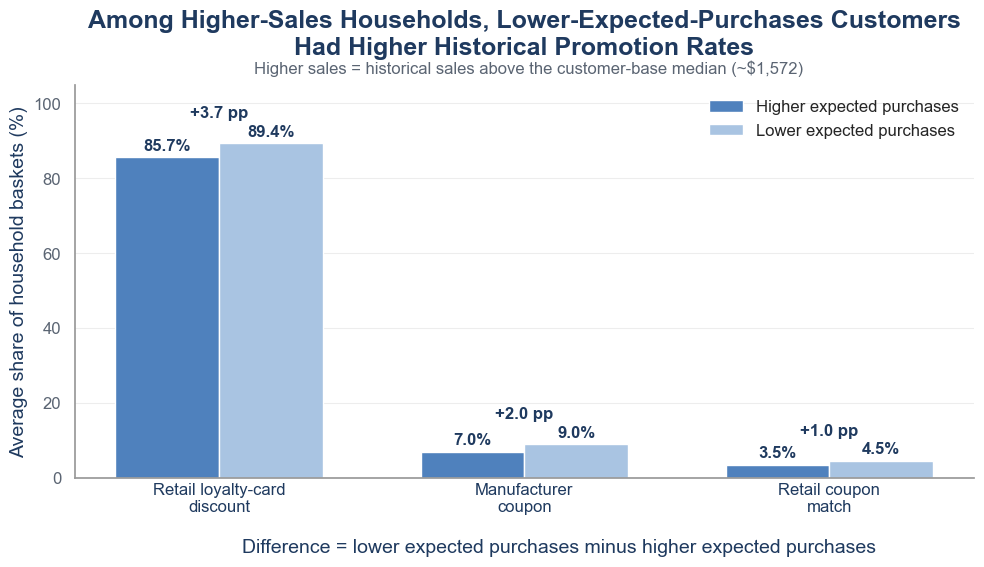

In [230]:
# =========================================================
# Promotion rates among HIGHER-HISTORICAL-SALES households
#
# Higher-sales households =
# households with historical sales above the
# customer-base median (~$1,572).
#
# Values = average household-level basket rates.
# =========================================================

# =========================================================
# Promotion rates among HIGHER-HISTORICAL-SALES households
#
# Higher-sales households =
# households with historical sales above the
# customer-base median (~$1,572).
#
# Values are average household-level basket rates.
# =========================================================

categories = [
    "Retail loyalty-card\ndiscount",
    "Manufacturer\ncoupon",
    "Retail coupon\nmatch"
]

# Higher-historical-sales households only
higher_activity = np.array([
    85.661,   # Retail discount basket rate
    6.993,    # Manufacturer coupon basket rate
    3.509     # Retail coupon match basket rate
])

lower_activity = np.array([
    89.370,
    8.953,
    4.527
])

# Difference:
# lower expected activity - higher expected activity
differences = lower_activity - higher_activity


# =========================================================
# Colors — consistent with previous slides
# =========================================================

navy = "#1F3A5F"

higher_color = "#4F81BD"   # Higher expected activity
lower_color = "#A9C4E2"    # Lower expected activity

grid_color = "#D9D9D9"
text_grey = "#5B6573"


# =========================================================
# Chart setup
# =========================================================

x = np.arange(len(categories))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.7))


# =========================================================
# Plot grouped bars
# =========================================================

bars_high = ax.bar(
    x - width / 2,
    higher_activity,
    width,
    label="Higher expected purchases",
    color=higher_color
)

bars_low = ax.bar(
    x + width / 2,
    lower_activity,
    width,
    label="Lower expected purchases",
    color=lower_color
)


# =========================================================
# Add value labels above bars
# =========================================================

for bars in [bars_high, bars_low]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1.0,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=navy
        )


# =========================================================
# Add percentage-point differences
#
# Example:
# 89.4% - 85.7% = +3.7 percentage points
# =========================================================

for i, diff in enumerate(differences):

    y_position = max(
        higher_activity[i],
        lower_activity[i]
    ) + 6

    ax.text(
        x[i],
        y_position,
        f"+{diff:.1f} pp",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=navy
    )


# =========================================================
# Chart title
# =========================================================

ax.set_title(
    "Among Higher-Sales Households, Lower-Expected-Purchases Customers\n"
    "Had Higher Historical Promotion Rates",
    fontsize=18,
    fontweight="bold",
    color=navy,
    loc="center",
    pad=22
)


# =========================================================
# Definition under title
# =========================================================

ax.text(
    0.2,
    1.02,
    "Higher sales = historical sales above the customer-base median (~$1,572)",
    transform=ax.transAxes,
    fontsize=12,
    color=text_grey,
    va="bottom"
)


# =========================================================
# Axis formatting
# =========================================================

ax.set_ylabel(
    "Average share of household baskets (%)",
    fontsize=14,
    color=navy
)

ax.set_xticks(x)

ax.set_xticklabels(
    categories,
    fontsize=12,
    color=navy
)

ax.set_ylim(0, 105)

ax.set_yticks(
    np.arange(0, 101, 20)
)

ax.tick_params(
    axis="y",
    labelsize=12,
    colors=text_grey
)

ax.tick_params(
    axis="x",
    length=0
)


# =========================================================
# Legend
# =========================================================

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right"
)


# =========================================================
# Grid and chart borders
# =========================================================

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.8,
    color=grid_color,
    alpha=0.45
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#999999")
ax.spines["bottom"].set_color("#999999")


# =========================================================
# Footnote
# =========================================================

fig.text(
    0.25,
    0.015,
    "Difference = lower expected purchases minus higher expected purchases",
    fontsize=14,
    color=navy
)


# =========================================================
# Final layout
# =========================================================

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()